This is Roi's modified inference code to include our half step. It runs on our more stable simulated data. You have to simulate data within every call. Roi's is currently set up to run the strict pd controller ie no sigmoid/beta. I got better results using the strict pd.

 Later on I attempt a mixture model. It runs however has lots of divergences so in its current shape is not much of a contender which is unfortunate.

# All of the warm up functionality: constants, reference orbit, simulator, etc

## Constants

In [ ]:
# constants.py

import numpy as np

BLUE = "#1f77b4"   # tab:blue
RED  = "#d62728"   # tab:red

# --- Earth Parameters ---
MU_EARTH = 3.986004418e14  # Earth's gravitational parameter (m^3/s^2)
R_EARTH = 6378.137e3       # Earth's equatorial radius (m)
J2 = 1.08263e-3           # J2 perturbation constant

# --- Third-Body Parameters ---
MU_SUN = 1.32712440018e20  # Sun's gravitational parameter (m^3/s^2)
MU_MOON = 4.9048695e12     # Moon's gravitational parameter (m^3/s^2)

# --- Solar Radiation Pressure ---
P_R = 4.56e-6             # Solar radiation pressure at 1 AU (N/m^2)
AU = 149597870.7e3
# --- Default Scenario: Geostationary Orbit ---
GEO_ALTITUDE = 35786e3    # Geostationary altitude (m)
GEO_RADIUS = R_EARTH + GEO_ALTITUDE
GEO_SPEED = np.sqrt(MU_EARTH / GEO_RADIUS)
S0 = np.array([GEO_RADIUS, 0, 0, 0, GEO_SPEED, 0])

# --- Earth Parameters in Kilometers ---
# Original MU_EARTH: 3.986004418e14 m^3/s^2
# Conversion factor: (1 km / 1000 m)^3 = 1e-9
MU_EARTH_KM = 3.986004418e5  # Earth's gravitational parameter (km^3/s^2)
R_EARTH_KM = 6378.137       # Earth's equatorial radius (km)
J2 = 1.08263e-3             # J2 perturbation constant (unitless)

# --- Third-Body Parameters in Kilometers ---
# Original MU_SUN: 1.32712440018e20 m^3/s^2
# Conversion factor: 1e-9
MU_SUN_KM = 1.32712440018e11 # Sun's gravitational parameter (km^3/s^2)
# Original MU_MOON: 4.9048695e12 m^3/s^2
# Conversion factor: 1e-9
MU_MOON_KM = 4.9048695e3     # Moon's gravitational parameter (km^3/s^2)

# --- Solar Radiation Pressure Constant ---
# P_R has units of N/m^2. Acceleration (a) from SRP is F/m = (P_R * A) / m.
# The units of 'a' are m/s^2. To get 'a' in km/s^2, we must divide by 1000.
# So, the constant P_R must also be adjusted.
# P_R_KM = (4.56e-6) / 1000 = 4.56e-9
P_R_KM_COEFF = 4.56e-9 # A constant that gives acceleration in km/s^2
AU_KM = 149597870.7


# --- Default Scenario: Geostationary Orbit in Kilometers ---
GEO_ALTITUDE_KM = 35786.0
GEO_RADIUS_KM = R_EARTH_KM + GEO_ALTITUDE_KM
GEO_SPEED_KM = np.sqrt(MU_EARTH_KM / GEO_RADIUS_KM)
S0_KM = np.array([GEO_RADIUS_KM, 0, 0, 0, GEO_SPEED_KM, 0])

## Plots for the simulator

In [ ]:
# plotting.py
# ====================
# This file provides plotting functions to visualize the orbits of a satellite using the
# pandas DataFrame log generated by the OrbitSimulator.

# ---- Imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union
from mpl_toolkits.mplot3d import Axes3D

# ---- Constants ----
# Use constants from your constants.py file for consistency
EARTH_RADIUS_M = R_EARTH
GEO_RADIUS_M = GEO_RADIUS

# ---------- Helper Functions ----------
def _as_df(df_or_path: Union[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Ensures we always work with a pandas DataFrame.
    """
    if isinstance(df_or_path, pd.DataFrame):
        return df_or_path
    return pd.read_csv(df_or_path)

def _set_equal_3d(ax, xs, ys, zs, pad_frac=0.08):
    """
    Ensures 3D plot has equal scaling for X, Y, Z axes so spheres look spherical.
    pad_frac: fraction of the max range to pad on each axis for spacing.
    """
    x_min, x_max = np.nanmin(xs), np.nanmax(xs)
    y_min, y_max = np.nanmin(ys), np.nanmax(ys)
    z_min, z_max = np.nanmin(zs), np.nanmax(zs)
    cx = 0.5*(x_min + x_max)
    cy = 0.5*(y_min + y_max)
    cz = 0.5*(z_min + z_max)
    r = max(x_max - x_min, y_max - y_min, z_max - z_min)
    r = max(r, 1.0) * (1 + pad_frac) * 0.5
    ax.set_xlim(cx - r, cx + r)
    ax.set_ylim(cy - r, cy + r)
    ax.set_zlim(cz - r, cz + r)

# ---------- Satellite-only plots ----------
def plot3d(log_df: pd.DataFrame, title='Satellite Orbit with Earth Centered', ax = None, show = True):
    """
    Plots only the satellite's trajectory in 3D, color-coded by stationkeeping status.
    """
    x = log_df["X (m)"].values
    y = log_df["Y (m)"].values
    z = log_df["Z (m)"].values
    status = log_df["Status"].values

    created_new_fig = False
    if ax is None:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        created_new_fig = True

    # Scatter plot: stationkeeping vs non-stationkeeping
    ax.scatter(x[status == "stationkeeping"], y[status == "stationkeeping"], z[status == "stationkeeping"],
               label="Stationkeeping", s=3)
    ax.scatter(x[status == "non-stationkeeping"], y[status == "non-stationkeeping"], z[status == "non-stationkeeping"],
               label="Free-Drift", s=3, marker='x')

    # Plot Earth as a sphere
    u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
    ex = EARTH_RADIUS_M * np.cos(u) * np.sin(v)
    ey = EARTH_RADIUS_M * np.sin(u) * np.sin(v)
    ez = EARTH_RADIUS_M * np.cos(v)
    ax.plot_surface(ex, ey, ez, color='blue', alpha=0.3, linewidth=0)

    # Axis labels and title
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title(title)
    ax.legend()

    # Ensure equal aspect ratio for 3D plot
    _set_equal_3d(ax, x, y, z)

    if created_new_fig and show:
        plt.tight_layout()
        plt.show()



def plot2d(log_df: pd.DataFrame, title='2D XY View of Satellite Orbit', ax = None, show = True):
    """
    Plots only the satellite's XY projection, with Earth shown as a blue circle.
    """
    x = log_df["X (m)"].values
    y = log_df["Y (m)"].values
    status = log_df["Status"].values

    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
        created_new_fig = True

    # Scatter plot for each status
    ax.scatter(x[status == "stationkeeping"], y[status == "stationkeeping"], label="Stationkeeping", s=3, marker='^')
    ax.scatter(x[status == "non-stationkeeping"], y[status == "non-stationkeeping"], label="Free-Drift", s=3, marker='x')

    # Draw Earth as a circle (top-down view)
    earth = plt.Circle((0, 0), EARTH_RADIUS_M, color=BLUE, alpha=0.2, label="Earth (not to scale)")
    ax.add_artist(earth)

    # Formatting
    ax.set_xlabel("X Position (m)")
    ax.set_ylabel("Y Position (m)")
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    if created_new_fig and show:
        plt.tight_layout()
        plt.show()


def plot_controller_performance(
    log_df: Union[str, pd.DataFrame],
    policy_params: dict,
    ax=None,
    show=True,
    title="Controller Performance"
):
    """
    Plots the satellite's distance from the reference trajectory and
    the magnitude of control acceleration over time.

    Works standalone or as part of a subplot grid.

    Args:
        log_df (Union[str, pd.DataFrame]): DataFrame or CSV path of simulation log.
        policy_params (dict): Contains controller parameters, including 'gamma'.
        ax (matplotlib.axes._axes.Axes or tuple): If provided, draws into given axis (or pair of axes).
        show (bool): Whether to show figure if created internally.
        title (str): Title for the figure (used only if created internally).
    """
    # --- Load data if needed ---
    if isinstance(log_df, str):
        log_df = pd.read_csv(log_df)
    if not isinstance(log_df, pd.DataFrame):
        raise TypeError("log_df must be a pandas DataFrame or path to CSV")

    # --- Compute metrics ---
    position_error = np.sqrt(
        (log_df['X (m)'] - log_df['ideal X (m)'])**2 +
        (log_df['Y (m)'] - log_df['ideal Y (m)'])**2 +
        (log_df['Z (m)'] - log_df['ideal Z (m)'])**2
    ).values

    control_accel_mag = np.sqrt(
        log_df['Control Accel (X)']**2 +
        log_df['Control Accel (Y)']**2 +
        log_df['Control Accel (Z)']**2
    ).values

    gamma = policy_params.get('gamma', 0.0)

    # --- Handle axes setup ---
    created_new_fig = False
    if ax is None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        created_new_fig = True
    else:
        # Allow ax to be a single subplot (draw only top plot)
        if isinstance(ax, (list, tuple, np.ndarray)):
            if len(ax) != 2:
                raise ValueError("If passing axes, must provide a tuple/list of two axes (ax1, ax2)")
            ax1, ax2 = ax
        else:
            raise ValueError("plot_controller_performance expects two axes or None")

    # --- Plot 1: Position Error ---
    ax1.plot(log_df['Time (s)'], position_error, color=BLUE, label="Position Error")
    ax1.axhline(y=gamma, color='tab:red', linestyle='--', label=r'Deadband Radius ($\gamma$)')
    ax1.set_ylabel("Distance from Ideal Position (m)")
    ax1.set_title("Position Error (m) from Deadband")
    ax1.grid(True, linestyle=':')
    ax1.legend()

    # --- Plot 2: Control Acceleration Magnitude ---
    ax2.plot(log_df['Time (s)'], control_accel_mag, color=RED, label="Control Acceleration Magnitude")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel(r"Control Acceleration ($m/s^2$)")
    ax2.set_title("Control and Total Acceleration Magnitude Applied")
    ax2.grid(True, linestyle=':')
    ax2.legend()

    # --- Handle titles smartly ---
    """
    if created_new_fig:
        hello = 1
        #fig.suptitle(title, fontsize=16)
    else:
        # Add the title above both subplots when used in a grid
        # Use figure coordinates relative to ax1
        ax1.text(0.5, 1.15, title,
                 fontsize=12,
                 ha='center', va='bottom',
                 transform=ax1.transAxes)
                 """

    # --- Display if standalone ---
    if created_new_fig and show:
        plt.tight_layout()
        plt.show()

    return (ax1, ax2)


def plot_position_error(log_df: Union[str, pd.DataFrame], policy_params: dict, ax = None, show = True, title = True, deadband = True):
    """
    Plots the satellite's distance from the reference trajectory in a dedicated figure.

    Args:
        log_df (Union[str, pd.DataFrame]): A DataFrame containing the simulation log
                                            or a path to a CSV file.
        policy_params (dict): A dictionary containing controller parameters,
                              specifically the deadband radius 'gamma'.
    """
    if isinstance(log_df, str):
        log_df = pd.read_csv(log_df)

    # Calculate distance from ideal position using DataFrame columns
    position_error = np.sqrt(
        (log_df['X (m)'] - log_df['ideal X (m)'])**2 +
        (log_df['Y (m)'] - log_df['ideal Y (m)'])**2 +
        (log_df['Z (m)'] - log_df['ideal Z (m)'])**2
    ).values

    # Create the figure and plot
    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_new_fig = True

    ax.plot(log_df['Time (s)'], position_error, label="Position Error")
    if deadband:
        ax.axhline(y=policy_params.get('gamma', 0), color='r', linestyle='--', label='Deadband Radius ($\gamma$)')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Distance from Ideal Position (m)")
    if title:
        ax.set_title("Satellite Position Error Over Time")
    ax.grid(True)
    ax.legend()

    if created_new_fig and show:
        plt.tight_layout()
        plt.show()


def plot_control_acceleration(log_df: Union[str, pd.DataFrame], ax = None, show = True, title = True):
    """
    Plots the magnitude of the control acceleration over time in a dedicated figure.

    Args:
        log_df (Union[str, pd.DataFrame]): A DataFrame containing the simulation log
                                            or a path to a CSV file.
    """
    if isinstance(log_df, str):
        log_df = pd.read_csv(log_df)

    # Magnitude of control acceleration using DataFrame columns
    control_accel_mag = np.sqrt(
        log_df['Control Accel (X)']**2 +
        log_df['Control Accel (Y)']**2 +
        log_df['Control Accel (Z)']**2
    ).values

    # Create the figure and plot
    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_new_fig = True

    ax.plot(log_df['Time (s)'], control_accel_mag, color = 'Red', label="Control Acceleration Magnitude")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Control Acceleration ($m/s^2$)")
    if title:
        ax.set_title("Control Acceleration Magnitude")
    ax.grid(True)
    ax.legend()

    if created_new_fig and show:
        plt.tight_layout()
        plt.show()




# ... (plot_conservation_laws and plot_controller_performance remain unchanged) ...
def plot_conservation_laws(times: np.ndarray, states: np.ndarray, title: str = 'Verification: Conservation Laws', ax = None, show = True):
    # This function is unchanged
    r_mag = np.linalg.norm(states[:, :3], axis=1); v_mag = np.linalg.norm(states[:, 3:], axis=1)
    energy = v_mag**2 / 2 - const.MU_EARTH / r_mag
    r_vecs = states[:, :3]; v_vecs = states[:, 3:]
    h_mag = np.linalg.norm(np.cross(r_vecs, v_vecs), axis=1)
    created_new_fig = False
    if ax is None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        created_new_fig = True
    ax1.plot(times / 3600, (energy - energy[0]) / energy[0]); ax1.set_ylabel('Relative Change in Energy\n($\Delta\epsilon / \epsilon_0$)'); ax1.set_title(title); ax1.grid(True)
    ax2.plot(times / 3600, (h_mag - h_mag[0]) / h_mag[0]); ax2.set_ylabel('Relative Change in Ang. Momentum\n($\Delta h / h_0$)'); ax2.set_xlabel('Time (hours)'); ax2.grid(True)
    if created_new_fig and show:
        plt.tight_layout()
        plt.show()



<>:243: SyntaxWarning: invalid escape sequence '\g'
<>:306: SyntaxWarning: invalid escape sequence '\D'
<>:307: SyntaxWarning: invalid escape sequence '\D'
<>:243: SyntaxWarning: invalid escape sequence '\g'
<>:306: SyntaxWarning: invalid escape sequence '\D'
<>:307: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_20035/1064573754.py:243: SyntaxWarning: invalid escape sequence '\g'
  ax.axhline(y=policy_params.get('gamma', 0), color='r', linestyle='--', label='Deadband Radius ($\gamma$)')
/tmp/ipykernel_20035/1064573754.py:306: SyntaxWarning: invalid escape sequence '\D'
  ax1.plot(times / 3600, (energy - energy[0]) / energy[0]); ax1.set_ylabel('Relative Change in Energy\n($\Delta\epsilon / \epsilon_0$)'); ax1.set_title(title); ax1.grid(True)
/tmp/ipykernel_20035/1064573754.py:307: SyntaxWarning: invalid escape sequence '\D'
  ax2.plot(times / 3600, (h_mag - h_mag[0]) / h_mag[0]); ax2.set_ylabel('Relative Change in Ang. Momentum\n($\Delta h / h_0$)'); ax2.set_xlabel('Time (h

In [ ]:
def plot_velocity_error(log_df: Union[str, pd.DataFrame], policy_params: dict, ax = None, show = True, title = True, deadband = True):
    """
    Plots the satellite's distance from the reference trajectory in a dedicated figure.

    Args:
        log_df (Union[str, pd.DataFrame]): A DataFrame containing the simulation log
                                            or a path to a CSV file.
        policy_params (dict): A dictionary containing controller parameters,
                              specifically the deadband radius 'gamma'.
    """
    if isinstance(log_df, str):
        log_df = pd.read_csv(log_df)

    # Calculate distance from ideal position using DataFrame columns
    position_error = np.sqrt(
        (log_df["VX (m/s)"] - log_df["ideal VX (m/s)"])**2 +
        (log_df["VY (m/s)"] - log_df["ideal VY (m/s)"])**2 +
        (log_df["VZ (m/s)"] - log_df["ideal VZ (m/s)"])**2
    ).values

    # Create the figure and plot
    created_new_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_new_fig = True

    ax.plot(log_df['Time (s)'], position_error, label="Velocity Error", color = 'Red')
    if deadband:
        ax.axhline(y=policy_params.get('gamma', 0), color='r', linestyle='--', label='Deadband Radius ($\gamma$)')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Velocity (m/s)")
    if title:
        ax.set_title("Satellite Velocity Error Over Time")
    ax.grid(True)
    ax.legend()

    if created_new_fig and show:
        plt.tight_layout()
        plt.show()


<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_20035/3313779280.py:29: SyntaxWarning: invalid escape sequence '\g'
  ax.axhline(y=policy_params.get('gamma', 0), color='r', linestyle='--', label='Deadband Radius ($\gamma$)')


In [ ]:
# From Cell In[2]
def plot_acceleration_components(log_df: pd.DataFrame, title='Acceleration Components Over Time', ax = None, show = True):
    """
    Plots the components of the total and control accelerations.
    """
    created_new_fig = False
    if ax is None:
        fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
        created_new_fig = True
    else:
        # --- START OF FIX ---
        axes = ax  # Assign the passed 'ax' array to 'axes'
        # Get the figure object from the first axis
        fig = axes[0].get_figure()
        # --- END OF FIX ---

    times = log_df['Time (s)'].values

    # Plot X components
    axes[0].plot(times, log_df['Control Accel (X)'], label='Control Accel (X)', linestyle='--')
    axes[0].plot(times, log_df['Total Accel (X)'], label='Total Accel (X)')
    axes[0].set_ylabel('Accel (m/s²)')
    axes[0].set_title('X-Component')
    axes[0].grid(True)
    axes[0].legend()

    # Plot Y components
    axes[1].plot(times, log_df['Control Accel (Y)'], label='Control Accel (Y)', linestyle='--')
    axes[1].plot(times, log_df['Total Accel (Y)'], label='Total Accel (Y)')
    axes[1].set_ylabel('Accel (m/s²)')
    axes[1].set_title('Y-Component')
    axes[1].grid(True)
    axes[1].legend()

    # Plot Z components
    axes[2].plot(times, log_df['Control Accel (Z)'], label='Control Accel (Z)', linestyle='--')
    axes[2].plot(times, log_df['Total Accel (Z)'], label='Total Accel (Z)')
    axes[2].set_ylabel('Accel (m/s²)')
    axes[2].set_title('Z-Component')
    axes[2].grid(True)
    axes[2].legend()

    axes[-1].set_xlabel('Time (s)')

    # This will now work because 'fig' is defined in both cases
    #fig.suptitle(title, fontsize=16)

    if created_new_fig and show:
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [ ]:
# Based on Cell In[73] and Cell In[2]

def fiveControllerPlots(df, true_policy_params):
    """
    Combines controller performance and acceleration component plots
    into a single 3x2 grid figure.
    """
    # Create a 3x2 grid of subplots
    fig, axes = plt.subplots(3, 2, figsize=(12, 16))
    ax_flat = axes.flatten()

    # --- Top row: Controller performance (2 stacked subplots) ---
    # Pass the first two axes as a list
    plot_controller_performance(
        log_df=df,
        policy_params=true_policy_params,
        ax=ax_flat[0:2],  # expects [ax1, ax2]
        show=False
    )

    # --- Middle + bottom rows: Acceleration components (3 stacked subplots) ---
    plot_acceleration_components(
        log_df=df,
        ax=ax_flat[2:5],  # expects [axX, axY, axZ]
        show=False
    )

    # --- Turn off last unused subplot ---
    ax_flat[5].axis('off')

 # --- Add overall title ---
    fig.suptitle(
        "Satellite Simulated Data Performance",
        fontsize=20,
        y=0.995,           # 🔥 shift the title higher above the plots
        fontweight="bold"
    )

    # --- Adjust layout ---
    # Increase top margin to make space for the suptitle
    plt.subplots_adjust(top=0.93)   # 🔥 ensures suptitle doesn’t overlap
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
# Based on Cell In[73] and Cell In[2]

def fiveControllerPlots(df, true_policy_params):
    """
    Combines controller performance and acceleration component plots
    into a single 3x2 grid figure.
    """
    # Create a 3x2 grid of subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 16))
    ax_flat = axes.flatten()

    # --- Top row: Controller performance (2 stacked subplots) ---
    # Pass the first two axes as a list
    plot_controller_performance(
        log_df=df,
        policy_params=true_policy_params,
        ax=ax_flat[0:2],  # expects [ax1, ax2]
        show=False
    )

    # --- Middle + bottom rows: Acceleration components (3 stacked subplots) ---
    plot_acceleration_components(
        log_df=df,
        ax=ax_flat[2:5],  # expects [axX, axY, axZ]
        show=False
    )

    # --- Turn off last unused subplot ---
    ax_flat[5].axis('off')

 # --- Add overall title ---
    fig.suptitle(
        "Satellite Simulated Data Performance",
        fontsize=20,
        y=0.995,           # 🔥 shift the title higher above the plots
        fontweight="bold"
    )

    # --- Adjust layout ---
    # Increase top margin to make space for the suptitle
    plt.subplots_adjust(top=0.93)   # 🔥 ensures suptitle doesn’t overlap
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Reference Orbit: the perfect trajectory

In [ ]:
!pip install skyfield

In [ ]:
import skyfield, sys

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp


#this generat
def generate_reference_trajectory_numerical(s0: np.ndarray, t_span: tuple, dt: float) -> tuple:
    def keplerian_rhs(t, s):
        r, v = s[:3], s[3:]
        a = -MU_EARTH / np.linalg.norm(r)**3 * r
        return np.hstack([v, a])
    times = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(fun=keplerian_rhs, t_span=t_span, y0=s0, t_eval=times, rtol=1e-9, atol=1e-12)
    return sol.t, sol.y.T

#given the starting degrees converted to radians already, what is the starting position
def rot_z(vec, th):
    #th = np.radians(deg)
    Rz = np.array([[np.cos(th), -np.sin(th), 0],
                [np.sin(th),  np.cos(th), 0],
                [0,           0,          1]])
    return Rz @ vec

#this is the function we use to calculate the reference trajectory
def generate_reference_trajectory(s0, t_span, dt, longitude=0.0):
    #the dt is cut in half so you also get the position for the half steps
    dt = dt/2
    # Ensure longitude is in radians
    #longitude = np.deg2rad(longitude)

    r = np.linalg.norm(s0[:3])                 # <-- fix
    w = np.sqrt(MU_EARTH / r**3)
    t = np.arange(t_span[0], t_span[1], dt)
    ang = w*t + longitude
    x  = r*np.cos(ang);  y  = r*np.sin(ang)
    vx = -r*w*np.sin(ang); vy = r*w*np.cos(ang)
    t, states = t, np.column_stack([x, y, np.zeros_like(x), vx, vy, np.zeros_like(x)])
    df = pd.DataFrame(
    states,
    columns=["x", "y", "z", "vx", "vy", "vz"]
    )
    df.insert(0, "t", t)  # add time as the first column

    # Save the referecne trajectory as a csv
    #df.to_csv("SimLogs/reference_trajectory.csv", index=False)
    #this returns a list of all of the times, and it returns a list of all of the desired
    #positions and velocities at those times
    return t, np.column_stack([x, y, np.zeros_like(x), vx, vy, np.zeros_like(x)])



## The simulator

In [ ]:
# simulator.py
from scipy.linalg import solve_continuous_are
import numpy as np
import pandas as pd
from skyfield.api import load
from pathlib import Path

# this is the class for the satellite orbit
class OrbitSimulator:
    """
    SDE-based orbit simulator incorporating major orbital perturbations
    and a control policy.
    """
    #when you initialize an orbit these are the things that are getting set.
    def __init__(self, satellite_params: dict, policy_params: dict, sigma: float = 0.0, policy = 'pd', noExternalForces = False):
        self.satellite_params = satellite_params
        self.policy_params = policy_params
        self.policy = policy
        self.sigma = sigma
        self.noExtForce = noExternalForces
        self.eph = load('de421.bsp')
        self.ts = load.timescale()
        self.earth = self.eph['earth']
        self.extAcc = [0,0,0]
        self.sun = self.eph['sun']
        self.moon = self.eph['moon']
        self.G = np.zeros((6, 3))
        self.G[3:, :] = np.identity(3)
        self.log = [] # Initialize the log list
        # --- LQR Setup ---
        self.A_old = policy_params.get('A', np.block([[np.zeros((3, 3)), np.eye(3)],[ -MU_EARTH / GEO_ALTITUDE**3 * np.array([
                                                                                                                [-2, 0, 0],
                                                                                                                [ 0, 1, 0],
                                                                                                                [ 0, 0, 1]
                                                                                                                ]), np.zeros((3, 3))]]))

        self.A = policy_params.get('A', np.block([[np.zeros((3, 3)), np.eye(3)],[ MU_EARTH / GEO_ALTITUDE**3 * np.array([
                                                                                                                [3, 0, 0],
                                                                                                                [ 0, 0, 0],
                                                                                                                [ 0, 0, -1]
                                                                                                                ]), ((MU_EARTH / GEO_ALTITUDE**3)**0.5) * np.array([
                                                                                                                [0, 2, 0],
                                                                                                                [ -2, 0, 0],
                                                                                                                [ 0, 0, 0]
                                                                                                                ])]]))


        self.B = policy_params.get('B', np.block([ [np.zeros((3, 3))], [np.eye(3)]]))
        self.Q = policy_params.get('Q', np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]))
        self.R = policy_params.get('R',  np.eye(3) * 1000000)
        self.prevStatus = "ns"

        # Solve the continuous-time Riccati equation
        P = solve_continuous_are(self.A, self.B, self.Q, self.R)

        # Compute the optimal gain matrix K
        self.K_lqr = np.linalg.inv(self.R) @ self.B.T @ P
        self.thirdBodiesLog = []
        self.j2 = [0,0,0]
        self.centralGrav = [0,0,0]
        self.thirdBod = [0,0,0]
        self.solarRad = [0,0,0]


    #this calculates the sun and moon positions for the given orbit
    def precompute_ephemeris(self, times: np.ndarray):
        """Pre-computes Sun and Moon positions for the simulation duration."""
        sky_times = self.ts.utc(2025, 1, 1, 0, 0, times)

        self.sun_pos_m = self.sun.at(sky_times).position.m - self.earth.at(sky_times).position.m
        self.moon_pos_m = self.moon.at(sky_times).position.m - self.earth.at(sky_times).position.m

        # Transpose from shape (3, N) to (N, 3)
        sun_pos = self.sun_pos_m
        moon_pos = self.moon_pos_m

        # Build a DataFrame with time + XYZ for each body
        df = pd.DataFrame({
            "Time (s)": times,
            "Sun X (m)": sun_pos[0],
            "Sun Y (m)": sun_pos[1],
            "Sun Z (m)": sun_pos[2],
            "Moon X (m)": moon_pos[0],
            "Moon Y (m)": moon_pos[1],
            "Moon Z (m)": moon_pos[2],
        })

        # Save to an attribute for later use
        self.sun_pos_m = sun_pos
        self.moon_pos_m = moon_pos
        self.thirdBodiesLog = df


    #this retrieves the moon and sun log information so you can save it as a
    #csv later
    def get_Moon_and_Sun_log(self):

        return self.thirdBodiesLog


    # --- Core Force Models ---

    #this calculates the central gravity
    def _central_gravity(self, r: np.ndarray) -> np.ndarray:
        return -MU_EARTH / np.linalg.norm(r)**3 * r

    #this calculates the j2_perturbations
    def _j2_perturbation(self, r: np.ndarray) -> np.ndarray:
        x, y, z = r
        r_norm = np.linalg.norm(r)
        pre_factor = -1.5 * J2 * MU_EARTH * R_EARTH**2 / r_norm**5
        z_factor = 5 * z**2 / r_norm**2
        ax = pre_factor * x * (1 - z_factor)
        ay = pre_factor * y * (1 - z_factor)
        az = pre_factor * z * (3 - z_factor)
        return np.array([ax, ay, az])

    #this is the third body perturbation forces
    def _third_body_perturbation(self, r: np.ndarray, k: int) -> np.ndarray:
        r_sun = self.sun_pos_m[:, k]
        r_moon = self.moon_pos_m[:, k]
        #print(f"The r_moon is: {r_sun} at step {k}")
        r_sat_sun = r_sun - r
        a_sun = MU_SUN * (r_sat_sun / np.linalg.norm(r_sat_sun)**3 - r_sun / np.linalg.norm(r_sun)**3)
        r_sat_moon = r_moon - r
        # a = moonMass *((dx/ d^3) - moonX / rb^3)
        a_moon = MU_MOON * (r_sat_moon / np.linalg.norm(r_sat_moon)**3 - r_moon / np.linalg.norm(r_moon)**3)

        a_total =  a_sun + a_moon
        return a_total

    #this gets the solar radiation perturbation effects
    def _srp_perturbation(self, r: np.ndarray, k: int) -> np.ndarray:
        C_R, A, m = self.satellite_params['C_R'], self.satellite_params['A'], self.satellite_params['m']
        r_sun = self.sun_pos_m[:, k]
        r_sat_sun = r_sun - r            # sat -> Sun
        d = np.linalg.norm(r_sat_sun)
        if d == 0:
            return np.zeros(3)
        a_mag = P_R * (AU**2 / d**2) * (C_R * A / m)
        return a_mag * (-(r_sat_sun / d))  # minus gives away-from-Sun

    # PD Control Policy
    def _PD_control_policy(self, s: np.ndarray, s_ref: np.ndarray) -> np.ndarray:
        """
        Calculates the control acceleration based on a PD controller with a deadband.
        The controller is only active when the position error exceeds a radius gamma.
        """
        #these variables are defined in the dictionary in the test_simV2
        gamma = self.policy_params.get('gamma', 0)
        Kp = self.policy_params.get('Kp', 0)
        Kd = self.policy_params.get('Kd', 0)

        #this gets the difference between actual position/velocity and perfect position/velocity
        delta_r = s[:3] - s_ref[:3]
        delta_v = s[3:] - s_ref[3:]
        #print("The differen")

        # Check if the satellite is outside the deadband radius
        try:
            #this extracts the euclidian distance eq
            position_error_norm = np.linalg.norm(delta_r)
        except Exception as e:
            #if an error occurs, this is all of the info you get told
            newA = (-Kp * delta_r - Kd * delta_v)
            print("Error occurred:", e)
            print("The difference in position:", delta_r)
            print("The difference in velocity:", delta_v)
            print("The applied acceleration:", newA)

        #only if you are outside of that dead band, do you enter station keeping
        if position_error_norm > gamma:
            # Controller is active: apply correction
            #return the new acceleration
            return (-Kp * delta_r - Kd * delta_v)
        else:
            # Controller is inactive: no thrust
            return np.zeros(3)

        #beta = 0.5
        #soft_weight = 1.0 / (1.0 + np.exp(-beta * (position_error_norm - gamma)))

        # Apply the soft weight to the PD control term
        #thrust = soft_weight * (-Kp * delta_r - Kd * delta_v)
        return thrust


        # bb Control Policy with Deadband
    def _bb_control_policy(self, s: np.ndarray, s_ref: np.ndarray) -> np.ndarray:
        """
        Calculates the control acceleration based on a Bang Bang controller with a deadband.
        The controller is only active when the position error exceeds a radius gamma.
        """
        #again these forces are listed in the true policy params in test_simV2
        gamma = self.policy_params.get('gamma', 0)
        maxA = self.policy_params.get('maxA', 0)

        #this gets the difference between actual position/velocity and perfect position/velocity
        delta_r = s[:3] - s_ref[:3]

        #exxtracts the euclidian distance
        position_error_norm = np.linalg.norm(delta_r)

        #if you are outside of gamma that max distance you enter station keeping
        if position_error_norm > gamma:
            #apply bang bang to get force
            acc_direction = -delta_r/ position_error_norm
            ax, ay, az = maxA * acc_direction  # fixed magnitude, opposite the error
            #print("Exceeded gamma. Applied acceleration: ", [ax, ay, az] )
            return [ax, ay, az]
        else:
            #otherwise return zeroes
            return np.zeros(3)

    # this is the current lqr controller
    def _lqr_control_policy(self, s, s_ref, t):
        """
        Compute LQR control in Hill frame, then rotate to ECI.
        """
        gamma = self.policy_params.get('gamma', 0)

        # State vectors
        r = s[:3]
        v = s[3:]
        r_ref = s_ref[:3]
        v_ref = s_ref[3:]

        delta_r = r - r_ref
        position_error_norm = np.linalg.norm(delta_r)

        if position_error_norm > gamma:
            # Orbital angular rate (use correct GEO radius!)
            a_geo = 42164e3   # [m] GEO radius
            omega = np.sqrt(MU_EARTH / a_geo**3)

            # Rotation matrix from ECI → Hill
            c = np.cos(omega * t)
            s_ = np.sin(omega * t)
            R_I2H = np.array([
                [ c,  s_,  0.0],
                [-s_,  c,  0.0],
                [0.0, 0.0, 1.0]
            ])
            dotR_I2H = np.array([
                [ -omega*s_,  omega*c,  0.0],
                [-omega*c,  -omega*s_,  0.0],
                [0.0, 0.0, 0.0]
            ])

            # Full 6x6 rotation (for position and velocity parts)
            T_old = np.block([
                [R_I2H, np.zeros((3,3))],
                [np.zeros((3,3)), R_I2H]
            ])
            T = np.block([
                [R_I2H, np.zeros((3,3))],
                [dotR_I2H, R_I2H]
            ])

            # Transform state errors to Hill frame
            error_state_H = T @ (s - s_ref)

            # Apply LQR in Hill frame
            u_H = -self.K_lqr @ error_state_H

            # Transform control back to ECI
            R_H2I = R_I2H.T
            u_ECI = R_H2I @ u_H

            return u_ECI

        else:
            return np.zeros(3)

    #this is the old lqr policy
    def _lqr_control_policy1(self, s, s_ref):
     #again these forces are listed in the true policy params in test_simV2
        gamma = self.policy_params.get('gamma', 0)
        delta_r = s[:3] - s_ref[:3]

        position_error_norm = np.linalg.norm(delta_r)
        #if you are outside of the dead band
        if position_error_norm > gamma:
            #apply the lqr controler
            error_state = s - s_ref
            control = -self.K_lqr @ error_state
            #print("The control output is: ", control)
            return control  # [ax, ay, az]
        else:
            #otherwise apply no acceleration
            return [0,0,0]

    #this function correctly calls the control policy based on designated input
    def getControlPolicy(self, s, s_ref, t):
        if self.policy == 'pd':
            return self._PD_control_policy(s, s_ref)
        if self.policy == 'bb':
            return self._bb_control_policy(s, s_ref)
        if self.policy == 'lqr':
            return self._lqr_control_policy(s, s_ref, t)
        else:
            print("Did not correctly call a policy: 'bb", 'pd', 'lqr')
            exit()


    #gets the total acceleration of both external forces and the control policies
    def _get_total_acceleration(self, s: np.ndarray, t: float, s_ref: np.ndarray, k: int) -> np.ndarray:
        #gets total forces
        r = s[:3]

        #if you did want external forces to be included in your simulation
        if self.noExtForce == False:
            #calls the control forces
            a_gravity = self._central_gravity(r)
            self.centralGrav = a_gravity
            a_j2 = self._j2_perturbation(r)
            self.j2 = a_j2
            a_3b = self._third_body_perturbation(r, k)
            self.thirdBod = a_3b
            a_srp = self._srp_perturbation(r, k)
            self.solarRad = a_srp
            self.extAcc = a_gravity + a_j2 + a_3b + a_srp
            #also gets your control policy you wanted: pd, bb, lqr. Will return that policy's
            #control output
            a_policy = self.getControlPolicy( s, s_ref, t)
            #a_policy = np.clip(a_policy, -self.policy_params.get('maxA'), self.policy_params.get('maxA') )
            #combines all of them together
            return a_gravity + a_j2 + a_3b + a_srp + a_policy

        else:
            #if you only wanted your control policy output here it is.
            a_policy = self.getControlPolicy( s, s_ref)
            return a_policy


    #this is the simulation that is actually used
    #the input parameters are s0 is your starting state correctly rotated depending on longitude
    #t_span is how long you want the simulation to run for
    #dt is the amount of time between every time step
    #ref_trajectory is the ideal position and velocity of the satellite at every full and half step
    def simulate_SLV(self, s0: np.ndarray, t_span: tuple, dt: float, ref_trajectory: np.ndarray) -> tuple:
        """
        Runs the full simulation using the Leapfrog Verlet stochastic algorithm.
        """
        #this gets a list from 0 to total amount of time, with everything inbetween with the dt
        #ex: if dt = 10: 0, 10, 20, 30, 40, 50, 60 .... to the total time
        times = np.arange(t_span[0], t_span[1], dt)
        #halfTimes = np.arange(t_span[0], t_span[1], dt/2.0)
        #this initializes the staes adn control actions to be zeros. Just gets dimensions down
        states = np.zeros((len(times), 6))
        control_actions = np.zeros((len(times), 3))
        #sets the starting state to that initial state
        states[0] = s0

        # Precompute ephemeris data
        #print("Precomputing ephemeris data...")
        #this is when you actually get the sun and moon position
        self.precompute_ephemeris(times)

        # Log the initial state assuming starting in ideal position
        self._log_state(0, times[0], states[0], ref_trajectory[0], np.zeros(3))


        sqrt_dt = np.sqrt(dt)

        for k in range(len(times) - 1):
            s_k = states[k]
            t_k = times[k]
            s_ref_k = ref_trajectory[k*2]

            # Extract position and velocity at step k
            r_k = s_k[:3]
            v_k = s_k[3:]

            # Get the control action for the log
            a_policy = self.getControlPolicy(s_k, s_ref_k, t_k)
            #a_policy = np.clip(a_policy, -self.policy_params.get('maxA'), self.policy_params.get('maxA') )
            control_actions[k] = a_policy

            # --- Leapfrog Verlet Algorithm ---

            # Step 1: Draw Wiener process increment
            dW_k = np.random.normal(0.0, 1.0, 3) * sqrt_dt
            noise_term = self.sigma * self.G @ dW_k

            # Step 2: Compute half-step supporting value
            r_half_step = r_k + 0.5 * v_k * dt
            s_ref_k_half = ref_trajectory[k*2 +1]

            # Step 3: Compute the total acceleration at the half-step position
            s_half_step = np.hstack([r_half_step, v_k])
            a_half_step = self._get_total_acceleration(s_half_step, t_k, s_ref_k_half, k)

            # Step 4: Update velocity and position
            v_k_plus_1 = v_k + a_half_step * dt + noise_term[3:]
            r_k_plus_1 = r_half_step + 0.5 * v_k_plus_1 * dt

            states[k+1] = np.hstack([r_k_plus_1, v_k_plus_1])

            # Log the state after the step
            self._log_state(k+1, times[k+1], states[k+1], ref_trajectory[k*2 + 2], a_policy)


    #this is just the log helper function.
    def _log_state(self, k: int, t: float, sim_state: np.ndarray, ref_state: np.ndarray, control_accel: np.ndarray):
        """Helper function to log the state at each time step."""
        r_sim, v_sim = sim_state[:3], sim_state[3:]
        r_ref, v_ref = ref_state[:3], ref_state[3:]

        # Determine control status
        status = "non-stationkeeping"
        if np.linalg.norm(control_accel) > 1e-15:
            status = "stationkeeping"

        # Calculate longitude in degrees from the simulated position
        longitude_deg = np.degrees(np.arctan2(r_sim[1], r_sim[0]))

        # Get the full acceleration including all perturbations
        a_total = self._get_total_acceleration(sim_state, t, ref_state, k)

        log_entry = {
            "Time (s)": t,
            "Satellite ID": "Geosat-1",  # Placeholder, could be a class attribute
            "Longitude (deg)": longitude_deg,
            "X (m)": r_sim[0],
            "Y (m)": r_sim[1],
            "Z (m)": r_sim[2],
            "VX (m/s)": v_sim[0],
            "VY (m/s)": v_sim[1],
            "VZ (m/s)": v_sim[2],
            "ideal X (m)": r_ref[0],
            "ideal Y (m)": r_ref[1],
            "ideal Z (m)": r_ref[2],
            "ideal VX (m/s)": v_ref[0],
            "ideal VY (m/s)": v_ref[1],
            "ideal VZ (m/s)": v_ref[2],
            "Status": status,
            "Control Accel (X)": control_accel[0],
            "Control Accel (Y)": control_accel[1],
            "Control Accel (Z)": control_accel[2],
            "Total Accel (X)": a_total[0],
            "Total Accel (Y)": a_total[1],
            "Total Accel (Z)": a_total[2],
            "Ext Accel X": self.extAcc[0],
            "Ext Accel Y": self.extAcc[1],
            "Ext Accel Z": self.extAcc[2],
            "solar rad x": self.solarRad[0],
            "solar rad y": self.solarRad[1],
            "solar rad z": self.solarRad[2],
            "j2 x": self.j2[0],
            "j2 y": self.j2[1],
            "j2 z": self.j2[2],
            "thirdBody x": self.thirdBod[0],
            "thirdBody y": self.thirdBod[1],
            "thirdBody z": self.thirdBod[2],
            "central gravity x": self.centralGrav[0],
            "central gravity y": self.centralGrav[1],
            "central gravity z": self.centralGrav[2]

        }
        self.log.append(log_entry)

    def get_log(self) -> pd.DataFrame:
        """Returns the simulation log as a Pandas DataFrame."""
        return pd.DataFrame(self.log)


#this runs a single simulation of the slv
def run_full_simulation(satPolicy, daysToProp, time_Step, longitudeDeg, noise_std, controlVariables, satId =1, noExtForces = False, verbose = False):
        if verbose:
            runString = "--- Running Final Simulation with " + satPolicy + " Controller (with Deadband) ---"
            print(runString)

        # 1. Define Simulation Parameters
        duration_days = daysToProp  # Changed from 2 to 3 days
        #print("Inside of the run full sim, the sumber of days is: ", duration_days)
        t_span = (0, duration_days * 24 * 3600)
        dt = time_Step

        # 2. Define the "True" Model Parameters with the new gamma
        # Updated values from your last message
        true_satellite_params = {'C_R': 1.5, 'A': 20.0, 'm': 1000.0}

        # New policy parameters from the notebook
        true_policy_params = controlVariables

        true_sigma = noise_std

        # 3. Generate Reference Trajectory
        # Option 1 (explicit slices)
        #S0 = np.asarray(const.S0, dtype=float)
        #r0, v0 = S0[:3], S0[3:]

        # desired initial longitude in degrees
        #S0_rot = np.hstack([rot_z(r0, longitudeDeg), rot_z(v0, longitudeDeg)])
        if verbose:
            print("Generating ideal Keplerian reference trajectory...")
        #ref_times, ref_states = generate_reference_trajectory(S0_rot, t_span, dt, longitudeDeg)

        #this calculates your initial starting position given longitude
        theta = np.deg2rad(longitudeDeg)  # your input is degrees
        s0 = np.asarray(S0, dtype=float)
        r0, v0 = s0[:3], s0[3:]              # 3-vectors
        s0_rot= np.hstack([rot_z(r0, theta), rot_z(v0, theta)])

        #gets your reference trajectory
        ref_times, ref_states = generate_reference_trajectory(s0_rot, t_span, dt, longitude=theta)


        # 4. Initialize and Run Simulator
        if verbose:
            print("Initializing full simulator with 'true' parameters...")
        #this instantiates your orbitSimulator object aka creates a satellite
        full_simulator = OrbitSimulator(
            satellite_params=true_satellite_params,
            policy_params=true_policy_params,
            sigma=true_sigma,
            policy = satPolicy,
            noExternalForces = noExtForces
        )
        if verbose:
            print("Running simulation... (this may take a moment)")
        # UNPACK THE NEW RETURN VALUE: control_actions
        # full_simulator.simulate(const.S0, t_span, dt, ref_states)
        #print("Inside of v2 sim: The t_span for v2 is:", t_span)
        #this is where you actually run and call the satellite
        full_simulator.simulate_SLV(s0_rot, t_span, dt, ref_states)

        #extract the satellite log and moon and sun log
        df = full_simulator.get_log()
        moonAndSunLog = full_simulator.get_Moon_and_Sun_log()

        #save those logs in the simLogs
        if verbose:
            print("Simulation complete.")
        dfTitle = f'SimLogs/{satPolicy}Sim.csv'
        sunTitle = f'SimLogs/moonAndSunSim.csv'
        #df.to_csv(dfTitle, index=False)
        #moonAndSunLog.to_csv(sunTitle)

        #return their dfs
        return df, moonAndSunLog


#get the multiple simulations from the three sims
def multipleSimsAll(numReps, daysToProp, time_Step, longitudeDeg, noise_std, controlVariables, satId =1, noExtForces = False):
    """
    Run numReps simulations for PD, LQR, and Bang-Bang controllers.
    Returns three lists; each element is a 1D array [x1,y1,z1, x2,y2,z2, ..., xN,yN,zN]
    for a single run.
    """
    #initialize what you are saving will hold all the replications
    allPd, allBb, allLqr = [], [], []
    pd_frames, lqr_frames, bb_frames = [], [], []
    cols = ['X (m)', 'Y (m)', 'Z (m)']

    # Ensure numReps is an int and iterate that many times
    for rep in range(int(numReps)):
        # Optional: give each run a unique satellite ID
        # run_sat_id = f"{satId}-{rep+1}"
        run_sat_id = satId

        # Run sims (each should return a DataFrame)
        # df = run_full_simulation('bb', daysToProp= 60, time_Step = dt, longitudeDeg=0.0, noise_std=0, controlVariables = true_policy_params, satId=1, noExtForces= False
        newPd, moonLog  = run_full_simulation('pd', daysToProp, time_Step, longitudeDeg, noise_std, controlVariables, satId =1, noExtForces = False)
        newLqr, moonLog = run_full_simulation('lqr', daysToProp, time_Step, longitudeDeg, noise_std, controlVariables, satId =1, noExtForces = False)
        newBb, moonLog  = run_full_simulation('bb', daysToProp, time_Step, longitudeDeg, noise_std, controlVariables, satId =1, noExtForces = False)


        # Select only the XYZ columns and flatten to a 1D vector
        try:
            pd_vec  = newPd[cols].to_numpy().ravel(order='C')
            lqr_vec = newLqr[cols].to_numpy().ravel(order='C')
            bb_vec  = newBb[cols].to_numpy().ravel(order='C')
        except KeyError as e:
            # Helpful error if any expected column is missing
            missing = [c for c in cols if c not in newPd.columns or c not in newLqr.columns or c not in newBb.columns]
            raise KeyError(f"Missing expected columns {missing}. Got:\n"
                        f"PD:   {list(newPd.columns)}\n"
                        f"LQR:  {list(newLqr.columns)}\n"
                        f"BB:   {list(newBb.columns)}") from e

        #add the new iterations to the master complie
        pd_frames.append(newPd)
        lqr_frames.append(newLqr)
        bb_frames.append(newBb)

        # Accumulate
        allPd.append(pd_vec)
        allBb.append(bb_vec)
        allLqr.append(lqr_vec)

    # --- combine after the loop (note: concat expects a list) ---
    pd_df  = pd.concat(pd_frames,  ignore_index=True)
    lqr_df = pd.concat(lqr_frames, ignore_index=True)
    bb_df  = pd.concat(bb_frames,  ignore_index=True)

    #save all of the sims, this includes all of the data
    #saveAllSims(pd_df, lqr_df, bb_df, moonLog, numReps)

    #return only the x, y, z positions of the satellites to use as for the MMD calculations
    #each replication is only one row in the lists.
    return allPd, allBb, allLqr



## Test Simulations if you want to see their effects

In [ ]:
#define the true parameters:
dt = 60#this is the difference in time you want
C = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
trueSatParamsTestSim = {
    'gamma': 000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    #'A': np.block([[np.zeros((3, 3)), np.eye(3)],[np.zeros((3, 3)), np.zeros((3, 3))]]), # the remaineder are lqr constants
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[C, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }

#this is how you actually generate a single simulation. The function inputs should be clear
#the first input is the policy so put 'pd', 'bb' or 'lqr'. It returns both the satellite's
#log and the moon/sun orbit df. you only need the sat df (the first df) for the plots
#noise_std= (1e-5*dt**.5)


df, moonLog = run_full_simulation('lqr', daysToProp=3, time_Step = dt, longitudeDeg=0.0, noise_std= 1e-3*dt**.5, controlVariables = trueSatParamsTestSim, satId=1, noExtForces= False, verbose = True )


--- Running Final Simulation with lqr Controller (with Deadband) ---
Generating ideal Keplerian reference trajectory...
Initializing full simulator with 'true' parameters...
Running simulation... (this may take a moment)
Simulation complete.


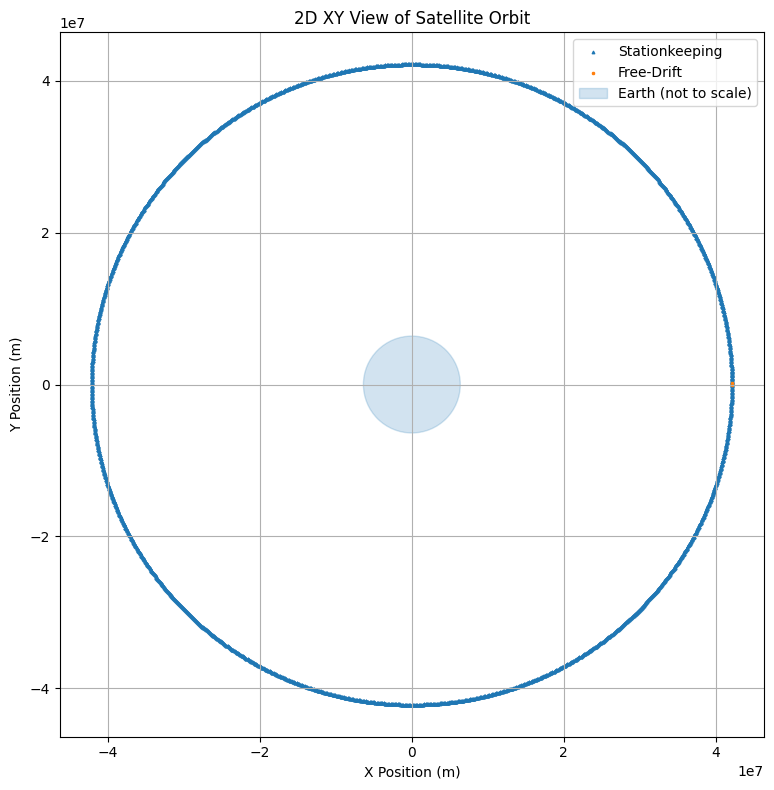

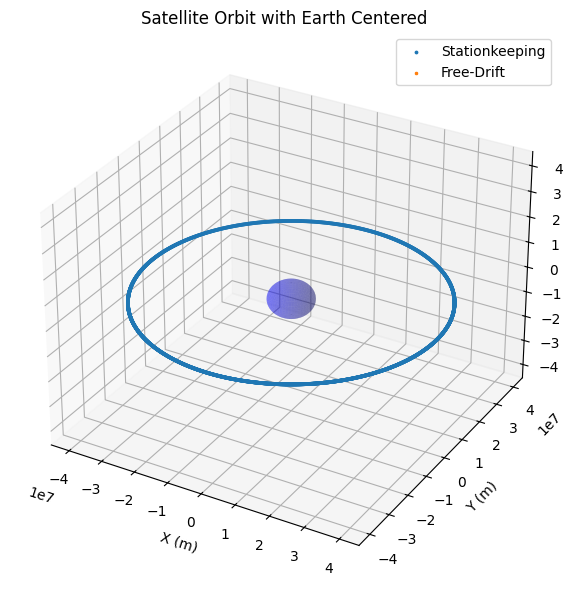

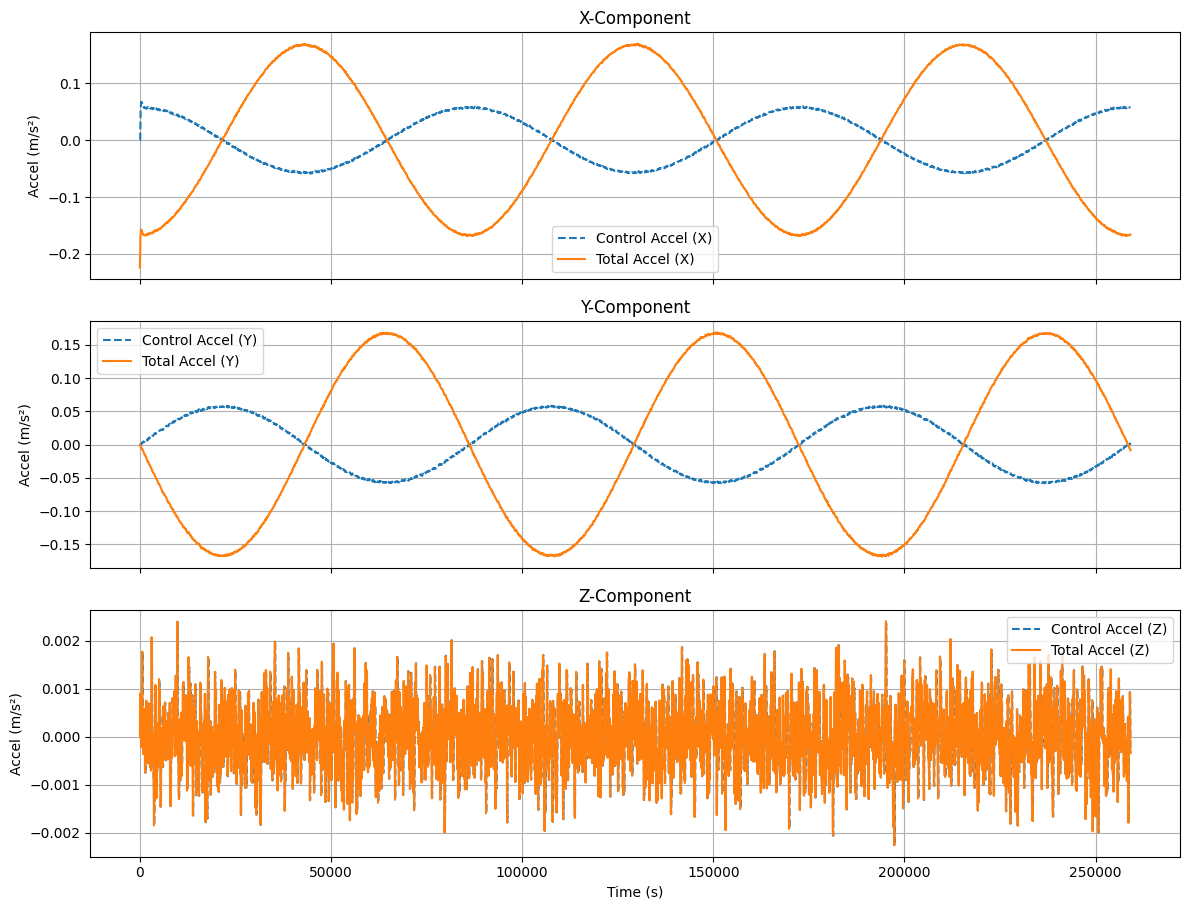

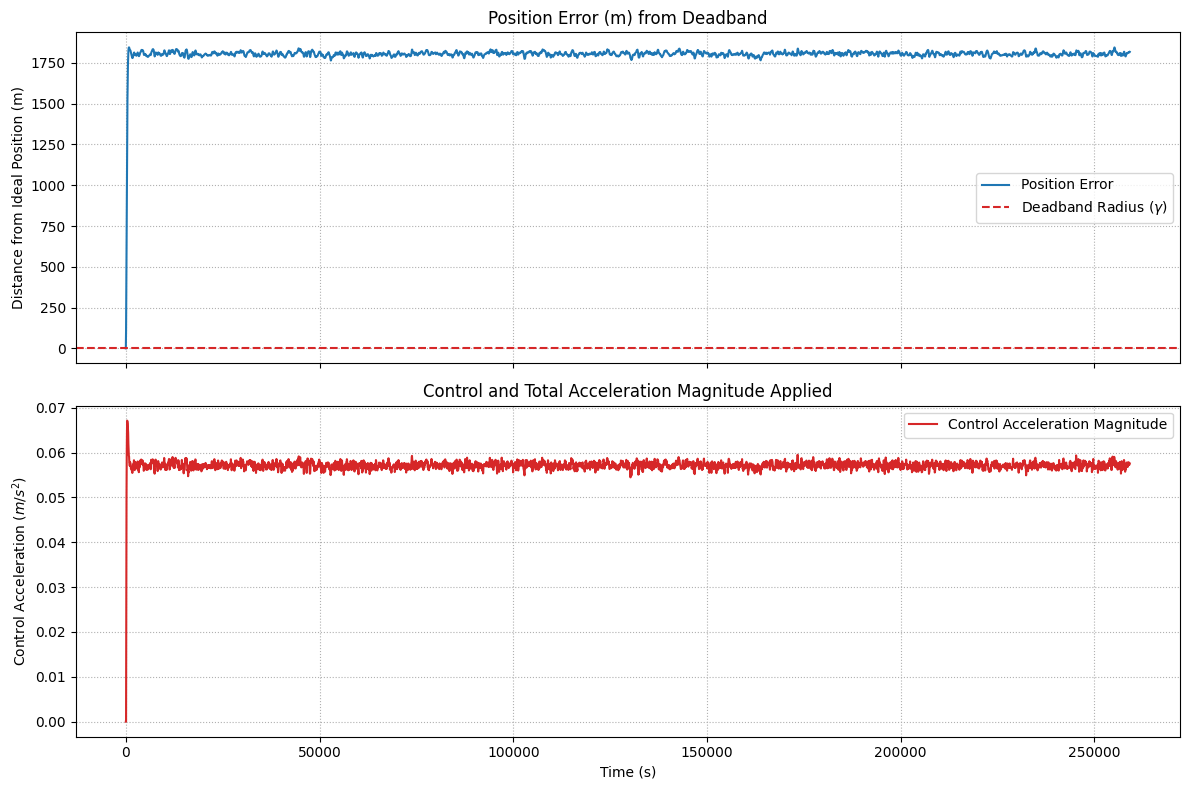

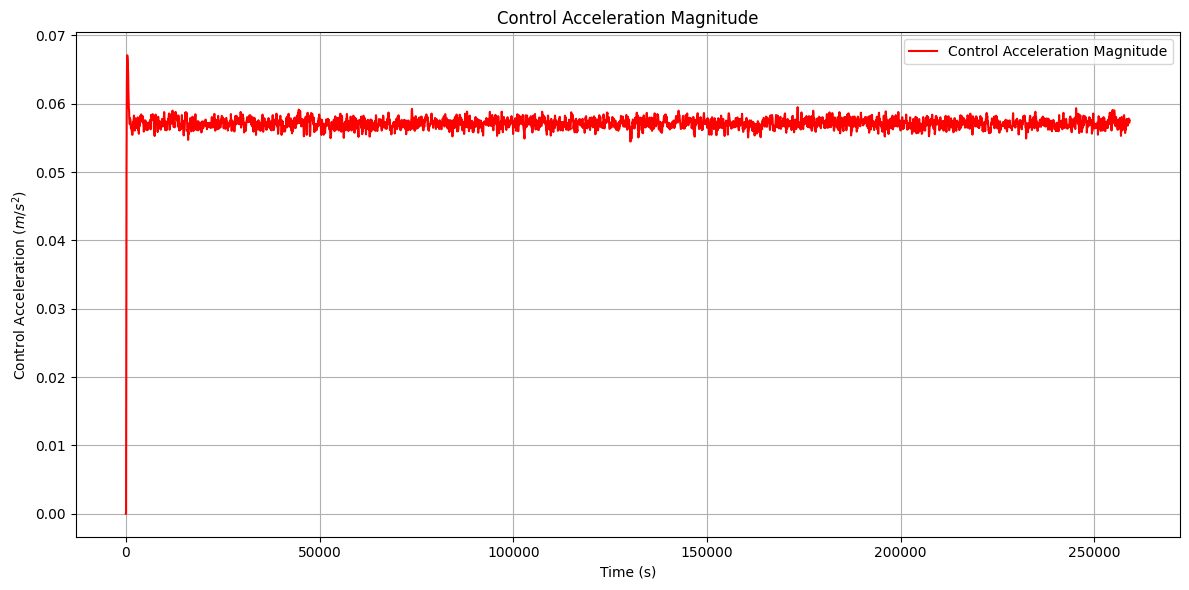

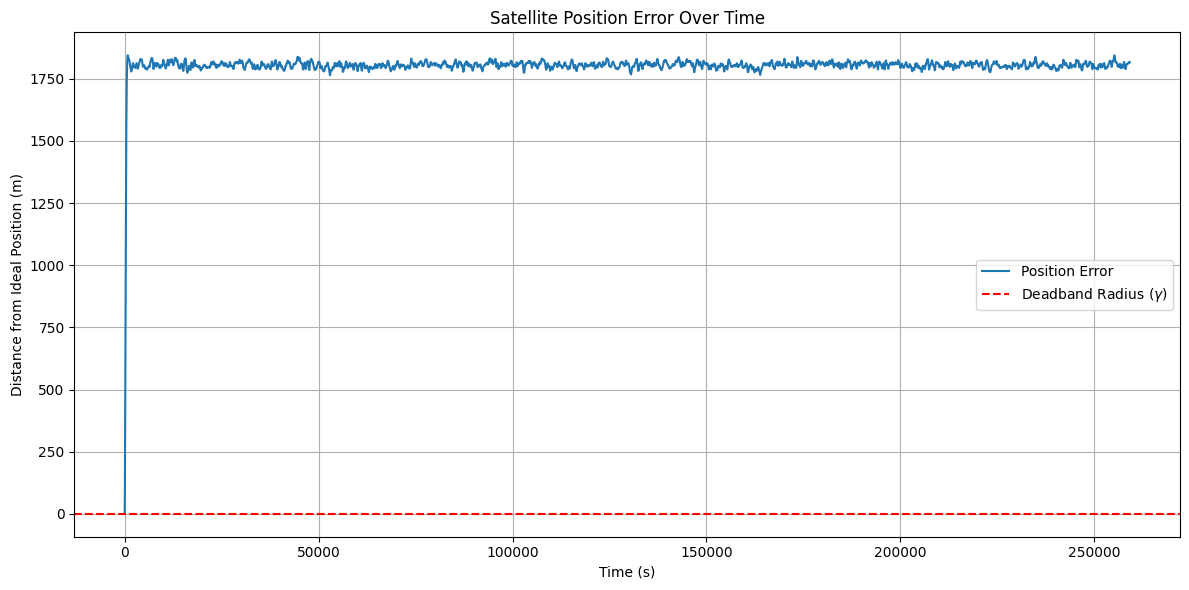

In [ ]:
# these are different plots you can use
plot2d(df)
plot3d(df)
plot_acceleration_components(log_df=df)
plot_controller_performance(log_df=df, policy_params=trueSatParamsTestSim)
plot_control_acceleration(log_df=df)
plot_position_error(log_df=df, policy_params=trueSatParamsTestSim)


In [ ]:
# Now you can call this function
#fiveControllerPlots(df, true_policy_params)

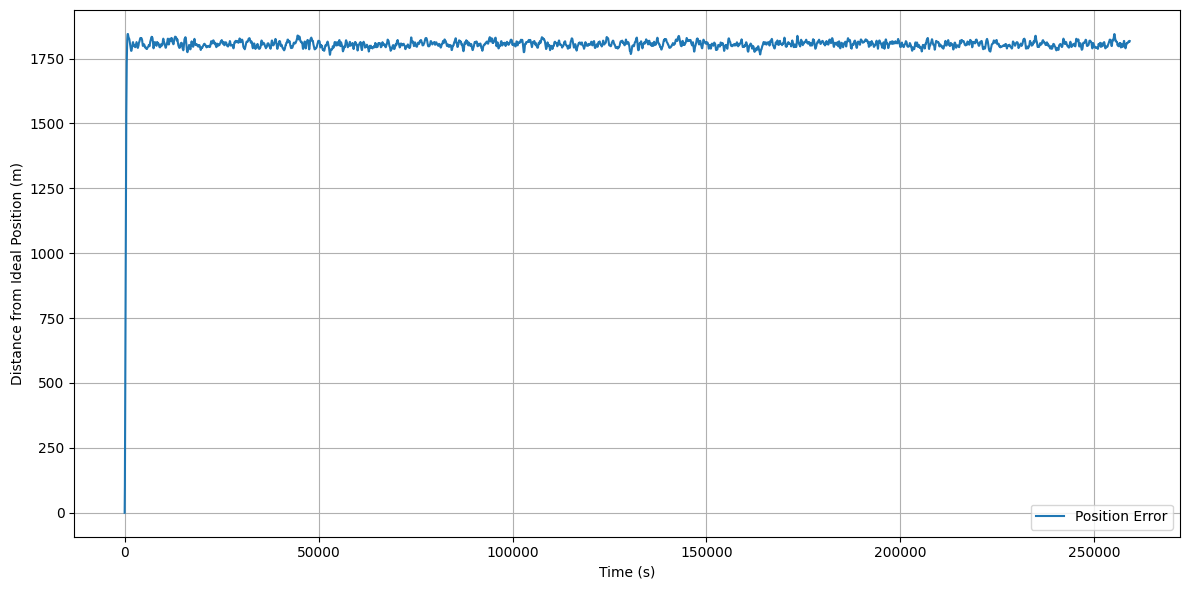

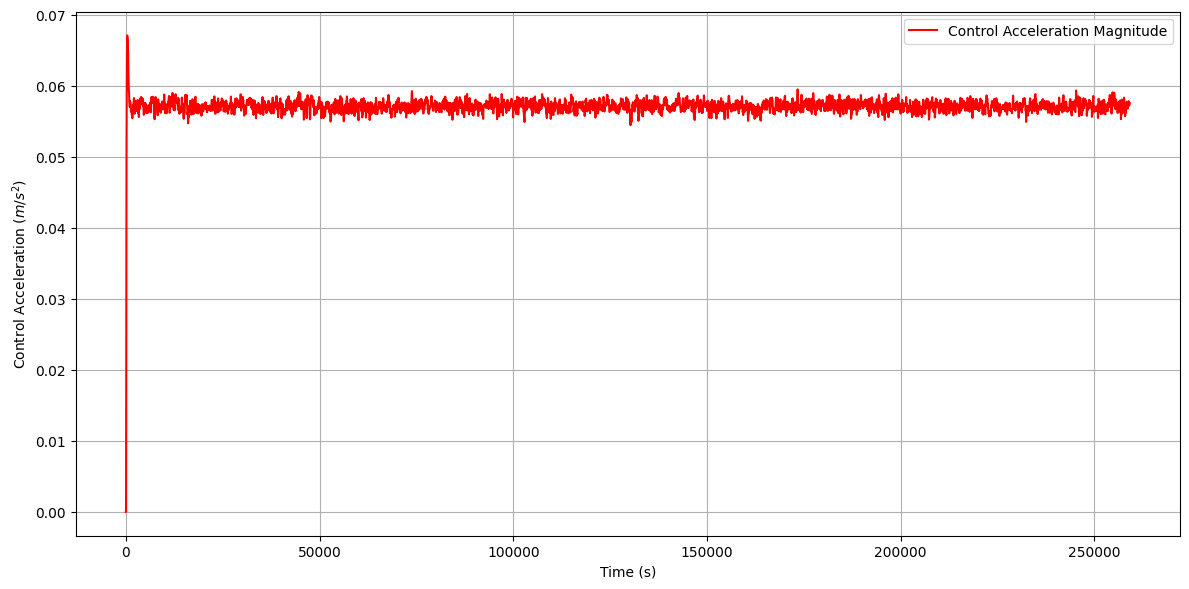

In [ ]:
plot_position_error(log_df=df, policy_params=trueSatParamsTestSim, title = False, deadband = False)
plot_control_acceleration(log_df=df, title = False)

# The Inference Functions

## The bayesian inference code

In [ ]:
!pip install numpyro

In [ ]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from scipy.integrate import solve_ivp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from jax import vmap



def jax_diff_control_policy(s, s_ref, Kp, Kd, gamma, beta): # NOTE: Added beta parameter
    delta_r = s[:3] - s_ref[:3]
    delta_v = s[3:] - s_ref[3:]

    position_error_norm = jnp.linalg.norm(delta_r)

    # Sigmoid function for soft-switching
    soft_weight = 1.0 / (1.0 + jnp.exp(-beta * (position_error_norm - gamma)))

    # Apply the soft weight to the PD control term
    thrust = soft_weight * (-Kp * delta_r - Kd * delta_v)

    return thrust


# --- 1. JAX-COMPATIBLE ACCELERATION FUNCTIONS ---
def jax_control_policy(s, s_ref, Kp, Kd, gamma):
    delta_r = s[:3] - s_ref[:3]
    delta_v = s[3:] - s_ref[3:]

    position_error_norm = jnp.linalg.norm(delta_r)

    # Use jnp.where for vectorized and JIT-compatible logic
    thrust = jnp.where(
        position_error_norm > gamma,
        -Kp * delta_r - Kd * delta_v,
        jnp.zeros(3)
    )
    return thrust

def jax_central_gravity(r):
    return -MU_EARTH / jnp.linalg.norm(r)**3 * r

def jax_j2_perturbation(r):
    x, y, z = r
    r_norm = jnp.linalg.norm(r)
    pre_factor = -1.5 * J2 * MU_EARTH * R_EARTH**2 / r_norm**5
    z_factor = 5 * z**2 / r_norm**2
    ax = pre_factor * x * (1 - z_factor)
    ay = pre_factor * y * (1 - z_factor)
    az = pre_factor * z * (3 - z_factor)
    return jnp.array([ax, ay, az])

def jax_third_body_perturbation(r, k, sun_pos, moon_pos):
    r_sun = sun_pos[k]
    r_moon = moon_pos[k]

    r_sat_sun = r_sun - r
    a_sun = MU_SUN * (r_sat_sun / jnp.linalg.norm(r_sat_sun)**3 - r_sun / jnp.linalg.norm(r_sun)**3)
    r_sat_moon = r_moon - r
    a_moon = MU_MOON * (r_sat_moon / jnp.linalg.norm(r_sat_moon)**3 - r_moon / jnp.linalg.norm(r_moon)**3)
    return a_sun + a_moon

def jax_srp_perturbation(r, k, sat_params, sun_pos):
    C_R, A, m = sat_params['C_R'], sat_params['A'], sat_params['m']
    r_sun = sun_pos[k]
    r_sat_sun = r_sun - r
    return -P_R * C_R * A / m * (r_sat_sun / jnp.linalg.norm(r_sat_sun))

def jax_get_total_acceleration(s, s_ref, k, sun_pos, moon_pos, sat_params, policy_params):
    r = s[:3]

    a_gravity = jax_central_gravity(r)
    a_j2 = jax_j2_perturbation(r)
    a_3b = jax_third_body_perturbation(r, k, sun_pos, moon_pos)
    a_srp = jax_srp_perturbation(r, k, sat_params, sun_pos)


    #a_policy = jax_diff_control_policy(s, s_ref, **policy_params)
    a_policy = jax_control_policy(s, s_ref, **policy_params)

    return a_gravity + a_j2 + a_3b + a_srp + a_policy


# --- 2. DATA GENERATION ---
#given the starting degrees converted to radians already, what is the starting position
def rot_z(vec, th):
    #th = np.radians(deg)
    Rz = np.array([[np.cos(th), -np.sin(th), 0],
                [np.sin(th),  np.cos(th), 0],
                [0,           0,          1]])
    return Rz @ vec

#this is the function we use to calculate the reference trajectory
def generate_reference_trajectory(s0, t_span, dt, longitude=0.0):
    #the dt is cut in half so you also get the position for the half steps
    dt = dt/2
    # Ensure longitude is in radians
    #longitude = np.deg2rad(longitude)

    r = np.linalg.norm(s0[:3])                 # <-- fix
    w = np.sqrt(MU_EARTH / r**3)
    t = np.arange(t_span[0], t_span[1], dt)
    ang = w*t + longitude
    x  = r*np.cos(ang);  y  = r*np.sin(ang)
    vx = -r*w*np.sin(ang); vy = r*w*np.cos(ang)
    t, states = t, np.column_stack([x, y, np.zeros_like(x), vx, vy, np.zeros_like(x)])
    df = pd.DataFrame(
    states,
    columns=["x", "y", "z", "vx", "vy", "vz"]
    )
    df.insert(0, "t", t)  # add time as the first column

    # Save the referecne trajectory as a csv
    #df.to_csv("SimLogs/reference_trajectory.csv", index=False)
    #this returns a list of all of the times, and it returns a list of all of the desired
    #positions and velocities at those times
    return t, np.column_stack([x, y, np.zeros_like(x), vx, vy, np.zeros_like(x)])

# --- 3. NUMPYRO BAYESIAN INFERENCE MODEL ---
def newSdeModel(times, observed_states, ref_states, sun_pos, moon_pos, sat_params, prior_params):
    gamma_prior = prior_params.get('gammaMean', 1)
    kp_prior = prior_params.get('KpMean', 1)
    kd_prior = prior_params.get('KdMean', 1)
    gamma_std = prior_params.get('gammaSTD', 1)
    kp_std = prior_params.get('KpSTD', 1)
    kd_std = prior_params.get('KdSTD', 1)

    logKp  = numpyro.sample("logKp",  dist.Normal(jnp.log(kp_prior), kp_std))
    logKd  = numpyro.sample("logKd",  dist.Normal(jnp.log(kd_prior), kd_std))
    #logGam = numpyro.sample("logGam", dist.Normal(jnp.log(gamma_prior), gamma_std))
    logSigma = numpyro.sample("logSigma", dist.Normal(jnp.log(1e-7), 1))
    Kp     = numpyro.deterministic("Kp", jnp.exp(logKp))
    Kd     = numpyro.deterministic("Kd", jnp.exp(logKd))
    #gamma  = numpyro.deterministic("gamma", jnp.exp(logGam))
    sigma  = numpyro.deterministic("sigma", jnp.exp(logSigma))
    #logBeta = numpyro.sample("logBeta", dist.Normal(jnp.log(1), 1)) # Example prior
    #beta = numpyro.deterministic("beta", jnp.exp(logBeta))
    #sigma = 1e-6
    gamma = 0

    # sigma = 1e-5
    # Kp = 5e-4
    # Kd = 5e-3
    # gamma = 10
    # beta = 0.5

    #policy_params = {"Kp": Kp, "Kd": Kd, "gamma": gamma, "beta": 0.5}
    policy_params = {"Kp": Kp, "Kd": Kd, "gamma": 0}

    vmap_accel = vmap(jax_get_total_acceleration, in_axes=(0, 0, 0, None, None, None, None))
    N = times.shape[0] - 1 #this gets the amount of times

    #get all of the observed data
    v_k_plus_1 = observed_states[1:, 3:]
    v_k = observed_states[:-1, 3:]
    r_k = observed_states[:-1, :3]
    dt = times[1:] - times[:-1]
    #need to extract reference track different since we actually use the reference track in the half step calculations
    ref_half_step = ref_states[1::2][:N]
    ref_at_k_full_step = ref_states[::2][:N]



    #Need to model and update our r_half, and v_half according to the slv sim

    r_half = r_k + 0.5 * v_k * dt[:, None] #this is done correctly
    s_half = jnp.concatenate([r_half, v_k], axis=1)


    t_idx = jnp.arange(times.shape[0] - 1, dtype=jnp.int32)
    # to get a_half step need to use the reference half step acceleration
    a_half = vmap_accel(s_half, ref_half_step, t_idx, sun_pos, moon_pos, sat_params, policy_params)

    predicted_v = v_k + a_half * dt[:, None]
    velocity_innovations = v_k_plus_1 - predicted_v

    numpyro.deterministic("predicted_v", predicted_v)
    numpyro.deterministic("a_half_step", a_half)
    #sigma = 1e-7
    N = times.shape[0] - 1
    dt = times[1:] - times[:-1]               # (N,)
    innov = velocity_innovations              # (N, 3)
    scale_t = sigma * jnp.sqrt(dt)      # (N,)

    with numpyro.plate("time", N, dim=-2):    # aligns with axis -2 of (N,3)
        with numpyro.plate("coord", 3, dim=-1):
            numpyro.sample(
                "obs",
                dist.Normal(0.0, scale_t[:, None]),   # (N,1) broadcasts to (N,3)
                obs=innov,
            )


# --- 4. EXECUTION ---
def run_bayesian_inference(days, policy, dt, noise, trueSatParams, priorNums, adapt_delta, warmupNum, iterNum, adapt, num_chains, verbose = False):
    if verbose:
        print("--- 1. Generating Ground Truth Data ---")
    duration_days = days
    dt = dt

    # These are our "true" parameters that we'll try to recover
    true_satellite_params = {'C_R': 1.5, 'A': 20.0, 'm': 1000.0}
    true_sigma = noise

   #define the true parameters:
    dt = dt#this is the difference in time you want
    true_policy_params = trueSatParams

    df, moonLog = run_full_simulation(policy, daysToProp= duration_days, time_Step = dt, longitudeDeg=0.0, noise_std= true_sigma, controlVariables = true_policy_params, satId=1, noExtForces= False )
    t_span = (0, duration_days * 24 * 3600)
    ref_times, ref_states = generate_reference_trajectory(S0, t_span, dt)

    #sim_times, sim_states, _ = simulator.simulate_SLV(const.S0, t_span, dt, ref_states)
    if verbose:
        print("Data generation complete.")

    # Prepare data for NumPyro (convert to JAX arrays)
    sim_states = df[['X (m)', 'Y (m)', 'Z (m)', 'VX (m/s)', 'VY (m/s)', 'VZ (m/s)']].to_numpy()
    observed_states = jnp.array(sim_states)
    sim_times= df['Time (s)'].to_numpy()
    times = jnp.array(sim_times)
    #refDf = pd.read_csv('SimLogs/reference_trajectory.csv')
    #print(refDf.head())
    ref_states = jnp.array(ref_states)
    sunPositions_array = moonLog[['Sun X (m)', 'Sun Y (m)', 'Sun Z (m)']].to_numpy()
    sun_pos = jnp.array(sunPositions_array)
    moonPositions_array = moonLog[['Moon X (m)', 'Moon Y (m)', 'Moon Z (m)']].to_numpy()
    moon_pos = jnp.array(moonPositions_array)
    if verbose:
        print("\n--- 2. Running Bayesian Inference with NumPyro ---")
    rng_key = jax.random.PRNGKey(0)
    rng_key, rng_key_ = jax.random.split(rng_key)

    # Set up the MCMC sampler
    kernel = NUTS(newSdeModel, adapt_step_size= adapt, target_accept_prob= adapt_delta)
    mcmc = MCMC(kernel, num_warmup=warmupNum, num_samples= iterNum, num_chains=num_chains, chain_method="vectorized")

    # Run the MCMC sampler
    mcmc.run(
        rng_key_,
        times=times,
        observed_states=observed_states,
        ref_states=ref_states,
        sun_pos=sun_pos,
        moon_pos=moon_pos,
        sat_params=true_satellite_params,
        prior_params=priorNums
        )
    if verbose:
        print("\n--- 3. Inference Results ---")

    return mcmc, df


## Graphs for inference

In [ ]:
!pip install seaborn
!pip install arviz

In [ ]:
"""
File: plot_comparison.py
Description: Contains a function to plot prior, posterior, and true values
for the satellite inference model.
"""

import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

def plot_prior_posterior_truthif(mcmc_obj, true_params, prior_params, true_sigma):
    """
    Plots the prior, posterior, and true value for log(Kp), log(Kd), and log(sigma)
    in the log-space they were sampled in.

    Args:
        mcmc_obj (numpyro.MCMC): The fitted MCMC object.
        true_params (dict): Dictionary with true values for 'Kp', 'Kd'.
        prior_params (dict): Dictionary with prior means/stds
                             ('KpMean', 'KpSTD', 'KdMean', 'KdSTD').
        true_sigma (float): The true sigma (noise) value used in data generation.
    """

    print("Generating Prior vs. Posterior vs. Truth plot (in Log-Space)...")

    latex_labels = {
        'Kp': r'$K_p$',
        'Kd': r'$K_d$',
        'gamma': r'$\gamma$',
        'beta': r'$\beta$',
        'sigma': r'$\sigma$',
        'logKp': r'$log(K_p)$',
        'logKd': r'$log(K_d)$',
        'logSigma': r'$log(\sigma)$'
        }

    try:
        # --- 1. Extract Posterior Samples (in log-space) ---
        inf_data = az.from_numpyro(mcmc_obj)
        post_kp_log = inf_data.posterior["logKp"].values.flatten()
        post_kd_log = inf_data.posterior["logKd"].values.flatten()
        post_sigma_log = inf_data.posterior["logSigma"].values.flatten()

        # --- 2. Define Prior Distributions (in log-space) ---
        # If Kp ~ LogNormal(log(Mean), STD), then log(Kp) ~ Normal(log(Mean), STD)

        # logKp Prior: Normal(log(KpMean), KpSTD)
        kp_prior_mean_log = np.log(prior_params['KpMean'])
        kp_prior_std_log = prior_params['KpSTD']
        kp_prior_dist = stats.norm(loc=kp_prior_mean_log, scale=kp_prior_std_log)

        # logKd Prior: Normal(log(KdMean), KdSTD)
        kd_prior_mean_log = np.log(prior_params['KdMean'])
        kd_prior_std_log = prior_params['KdSTD']
        kd_prior_dist = stats.norm(loc=kd_prior_mean_log, scale=kd_prior_std_log)

        # logSigma Prior: Normal(log(1e-7), 1) (hard-coded in newSdeModel)
        sigma_prior_mean_log = np.log(1e-7)
        sigma_prior_std_log = 1.0
        sigma_prior_dist = stats.norm(loc=sigma_prior_mean_log, scale=sigma_prior_std_log)

        # --- 3. Get Truth Values (in log-space) ---
        true_kp_log = np.log(true_params['Kp'])
        true_kd_log = np.log(true_params['Kd'])
        true_sigma_log = np.log(true_sigma)

        # --- 4. Create Plots ---
        fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)
        plot_vars = [
            ('logKp', post_kp_log, kp_prior_dist, true_kp_log),
            ('logKd', post_kd_log, kd_prior_dist, true_kd_log),
            ('logSigma', post_sigma_log, sigma_prior_dist, true_sigma_log)
        ]

        for i, (name, post_samples, prior_dist, true_val) in enumerate(plot_vars):
            ax = axes[i]

            # Plot Posterior
            sns.kdeplot(post_samples, ax=ax, fill=True, label="Posterior", color="C0", cut=0)

            # Determine plot range
            post_min, post_max = np.percentile(post_samples, [0.01, 99.99])
            prior_min, prior_max = prior_dist.ppf([0.01, 0.99])

            # Handle potentially huge prior ranges
            range_post = post_max - post_min + 1e-30
            range_prior = prior_max - prior_min + 1e-30
            if range_prior / range_post > 100:
                prior_min = max(prior_min, post_min - range_post * 5)
                prior_max = min(prior_max, post_max + range_post * 5)

            x_min = min(post_min, prior_min, true_val)
            x_max = max(post_max, prior_max, true_val)

            padding = (x_max - x_min) * 0.1
            x_min -= padding # Remove max(0, ...) since logs can be negative
            x_max += padding

            x = np.linspace(x_min, x_max, 400)

            # Plot Prior (which is a Normal distribution)
            try:
                prior_pdf = prior_dist.pdf(x)
                ax.plot(x, prior_pdf, label="Prior", color="gray", linestyle="--", linewidth=2)
            except Exception as e:
                print(f"Could not plot prior for {name}: {e}")

            # Plot Truth
            ax.axvline(true_val, label=f"Truth = {true_val:.2f}", color="red", linestyle=":", linewidth=2.5)

            #ax.set_title(f"Prior vs. Posterior vs. Truth for {name}", fontsize=14)
            ax.set_xlabel(latex_labels.get(name), fontsize=12)
            ax.set_ylabel("Density", fontsize=12)
            ax.legend()
            ax.set_xlim(x_min, x_max)

        #fig.suptitle("Parameter Recovery Analysis (Log-Space)", fontsize=18, y=1.03)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error creating comparison plot: {e}")
        import traceback
        traceback.print_exc()



In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpyro
from arviz.labels import MapLabeller  # <-- 1. Import the labeller



# --- NEW: Create the labeller object ---
# This tells arviz how to map the string names to the LaTeX labels
 # <-- 2. Create the labeller

def trace_posterior_plotsif(mcmc):
  pdinf_data = az.from_numpyro(mcmc)
  latex_labels = {
    'Kp': r'$K_p$',
    'Kd': r'$K_d$',
    'gamma': r'$\gamma$',
    'beta': r'$\beta$',
    'sigma': r'$\sigma$'
    }
  #snazzy_labeller = MapLabeller(var_map=latex_labels)
  snazzy_labeller = MapLabeller(var_name_map=latex_labels)

  # Define which variables to plot (using your uncommented line)
  vars_to_plot = ["Kp", "Kd", "sigma"]
  # If you want to plot others, just change this list, e.g.:
  # vars_to_plot = ["Kp", "Kd", "gamma", "beta", "sigma"]

  # --- UPDATED: Trace Plots ---
  print("Displaying Trace Plots...")
  az.plot_trace(
      pdinf_data,
      var_names=vars_to_plot,
      figsize=(12, 8),
      labeller=snazzy_labeller  # <-- 3. Apply the labeller here
  )
  #plt.suptitle("Trace Plots", fontsize=16)
  plt.tight_layout()
  plt.show()

  # --- UPDATED: Posterior Plots ---
  print("Displaying Posterior Plots...")
  az.plot_posterior(
      pdinf_data,
      var_names=vars_to_plot,
      hdi_prob=0.95,
      labeller=snazzy_labeller  # <-- 4. Apply the labeller here
  )
  #plt.suptitle("Posterior Distributions", fontsize=16)
  plt.tight_layout()
  plt.show()



# Posterior Functions

## Simulating from Posterior

In [ ]:
# --- NEW FUNCTIONS FOR POSTERIOR PREDICTIVE CHECKS ---

def simulate_from_posterior(mcmc_obj, base_params_template, daysToProp, dt, longitudeDeg, num_sims=50):
    """
    Runs the full simulator using parameters drawn from the posterior distribution.

    Args:
        mcmc_obj (numpyro.MCMC): The fitted MCMC object.
        base_params_template (dict): A template of the 'trueSatParams' dict.
                                     (Used for non-inferred params like LQR).
        daysToProp (int): Number of days to simulate.
        dt (int): Time step in seconds.
        longitudeDeg (float): Starting longitude.
        num_sims (int): Number of posterior simulations to run.

    Returns:
        list_of_dfs (list): A list where each element is a simulation DataFrame.
    """
    print(f"\n--- Running {num_sims} Posterior Predictive Simulations ---")
    samples = mcmc_obj.get_samples()

    # Get total number of samples and pick random indices
    total_samples = len(samples['Kp'])
    if total_samples < num_sims:
        print(f"Warning: Requested {num_sims} sims, but only {total_samples} samples exist. Using all samples.")
        indices = np.arange(total_samples)
        num_sims = total_samples
    else:
        indices = np.random.choice(total_samples, num_sims, replace=False)

    simulation_logs = []

    for i, sample_idx in enumerate(indices):
        if (i+1) % 10 == 0:
            print(f"Running simulation {i+1} of {num_sims}...")

        # Get parameters from this specific posterior sample
        kp_sample = samples['Kp'][sample_idx]
        kd_sample = samples['Kd'][sample_idx]
        sigma_sample = samples['sigma'][sample_idx]

        # Create the control parameter dict for this simulation
        sim_params = base_params_template.copy()
        sim_params['Kp'] = kp_sample
        sim_params['Kd'] = kd_sample
        # IMPORTANT: Use gamma=0, just like in the inference model
        sim_params['gamma'] = 0

        # Run the simulator with these parameters
        # Note: We use policy='pd' because that's what the inference model assumes
        df_sim, _ = run_full_simulation(
            satPolicy='pd',
            daysToProp=daysToProp,
            time_Step=dt,
            longitudeDeg=longitudeDeg,
            noise_std=sigma_sample,
            controlVariables=sim_params,
            satId=f"posterior_sim_{i}",
            noExtForces=False,
            #verbose=False  # Suppress print statements
        )

        simulation_logs.append(df_sim)

    print("Posterior simulations complete.")
    return simulation_logs



## Plots for the Posterior

In [ ]:
def plot_posterior_simulationsif(original_log_df, posterior_logs, title="Posterior Predictive Check"):
    """
    Plots the 'Position Error' from the original data on top of all the
    simulations from the posterior.

    Args:
        original_log_df (pd.DataFrame): The single, original "ground truth" dataframe.
        posterior_logs (list): The list of DataFrames from simulate_from_posterior.
        title (str): The title for the plot.
    """
    print("Plotting posterior predictive check...")
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot all the posterior simulations with low opacity
    for i, log_df in enumerate(posterior_logs):
        position_error = np.sqrt(
            (log_df['X (m)'] - log_df['ideal X (m)'])**2 +
            (log_df['Y (m)'] - log_df['ideal Y (m)'])**2 +
            (log_df['Z (m)'] - log_df['ideal Z (m)'])**2
        ).values

        label = "Posterior Simulations" if i == 0 else None
        ax.plot(log_df['Time (s)'], position_error, color= BLUE, alpha=0.1, label=label)

    # Plot the original data on top, nice and bold
    original_error = np.sqrt(
        (original_log_df['X (m)'] - original_log_df['ideal X (m)'])**2 +
        (original_log_df['Y (m)'] - original_log_df['ideal Y (m)'])**2 +
        (original_log_df['Z (m)'] - original_log_df['ideal Z (m)'])**2
    ).values

    ax.plot(original_log_df['Time (s)'], original_error, color= RED, linewidth=2, label="Original Data")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Position Error (m)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def _calculate_position_error(log_df):
    """Helper to calculate position error time-series from a log DataFrame."""
    return np.sqrt(
        (log_df['X (m)'] - log_df['ideal X (m)'])**2 +
        (log_df['Y (m)'] - log_df['ideal Y (m)'])**2 +
        (log_df['Z (m)'] - log_df['ideal Z (m)'])**2
    ).values

def plot_posterior_mean_timeseriesif(original_log_df, posterior_logs, title="Posterior Predictive Check (Mean Time-Series)", ax = None, show = True):
    """
    Plots the mean position error time-series from all posterior simulations
    against the original data's time-series.
    """
    print("Plotting posterior predictive check (mean time-series)...")

    # 1. Calculate all posterior error time-series
    all_errors = []
    for log_df in posterior_logs:
        all_errors.append(_calculate_position_error(log_df))

    # Stack into a 2D array (num_sims, num_timesteps)
    # Use try-except for safety if a simulation failed and produced a different length
    try:
        error_array = np.stack(all_errors)
    except ValueError as e:
        print(f"Error: Could not stack posterior errors. Sims may have different lengths. {e}")
        # Fallback: Find the most common length and use only those sims
        lengths = [len(err) for err in all_errors]
        common_length = max(set(lengths), key=lengths.count)
        valid_errors = [err for err in all_errors if len(err) == common_length]
        if not valid_errors:
            print("Error: No valid posterior simulations to plot.")
            return
        print(f"Warning: Using {len(valid_errors)}/{len(all_errors)} sims with common length {common_length}.")
        error_array = np.stack(valid_errors)

    # 2. Calculate the mean error at each time step (axis=0)
    mean_posterior_error = np.mean(error_array, axis=0)

    # 3. Get the original data's error time-series
    original_error = _calculate_position_error(original_log_df)

    # 4. Get the time array (must match the length of the errors)
    # Ensure we use a time array that matches the common length
    time_array = original_log_df['Time (s)'].values
    if len(time_array) != len(mean_posterior_error):
         # This can happen if the original_log_df and posterior_logs have different lengths
         # We'll use the time from the first posterior log that matched the common length
         for log_df in posterior_logs:
             if len(log_df['Time (s)']) == len(mean_posterior_error):
                 time_array = log_df['Time (s)'].values
                 break

    # Final check
    if len(time_array) != len(mean_posterior_error) or len(time_array) != len(original_error):
        print("Error: Time array and error array dimension mismatch. Aborting plot.")
        print(f"Time: {len(time_array)}, Mean Posterior: {len(mean_posterior_error)}, Original: {len(original_error)}")
        return

    # 5. Plot
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_fig = True

    ax.plot(time_array, mean_posterior_error, color= BLUE, linewidth=2, label="Mean Posterior Simulation")
    ax.plot(time_array, original_error, color=RED, linewidth=2, linestyle='--', label="Original Data")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Position Error (m)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    if created_fig and show:
        plt.tight_layout()
        plt.show()

In [ ]:
def plot_posterior_max_timeseriesif(original_log_df, posterior_logs, title="Posterior Predictive Check (Mean Time-Series)", ax = None, show = True):
    """
    Plots the mean position error time-series from all posterior simulations
    against the original data's time-series.
    """
    print("Plotting posterior predictive check (mean time-series)...")

    # 1. Calculate all posterior error time-series
    all_errors = []
    for log_df in posterior_logs:
        all_errors.append(_calculate_position_error(log_df))

    # Stack into a 2D array (num_sims, num_timesteps)
    # Use try-except for safety if a simulation failed and produced a different length
    try:
        error_array = np.stack(all_errors)
    except ValueError as e:
        print(f"Error: Could not stack posterior errors. Sims may have different lengths. {e}")
        # Fallback: Find the most common length and use only those sims
        lengths = [len(err) for err in all_errors]
        common_length = max(set(lengths), key=lengths.count)
        valid_errors = [err for err in all_errors if len(err) == common_length]
        if not valid_errors:
            print("Error: No valid posterior simulations to plot.")
            return
        print(f"Warning: Using {len(valid_errors)}/{len(all_errors)} sims with common length {common_length}.")
        error_array = np.stack(valid_errors)

    # 2. Calculate the mean error at each time step (axis=0)
    mean_posterior_error = np.max(error_array, axis=0)

    # 3. Get the original data's error time-series
    original_error = _calculate_position_error(original_log_df)

    # 4. Get the time array (must match the length of the errors)
    # Ensure we use a time array that matches the common length
    time_array = original_log_df['Time (s)'].values
    if len(time_array) != len(mean_posterior_error):
         # This can happen if the original_log_df and posterior_logs have different lengths
         # We'll use the time from the first posterior log that matched the common length
         for log_df in posterior_logs:
             if len(log_df['Time (s)']) == len(mean_posterior_error):
                 time_array = log_df['Time (s)'].values
                 break

    # Final check
    if len(time_array) != len(mean_posterior_error) or len(time_array) != len(original_error):
        print("Error: Time array and error array dimension mismatch. Aborting plot.")
        print(f"Time: {len(time_array)}, Mean Posterior: {len(mean_posterior_error)}, Original: {len(original_error)}")
        return

    # 5. Plot
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_fig = True

    ax.plot(time_array, mean_posterior_error, color=BLUE, linewidth=2, label="Max Posterior Simulation")
    ax.plot(time_array, original_error, color= RED, linewidth=2, linestyle='--', label="Original Data")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Position Error (m)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    if created_fig and show:
        plt.tight_layout()
        plt.show()

In [ ]:
def plot_posterior_mean_thrust_componentsif(original_log_df, posterior_logs, title="Posterior Predictive Check (Mean Control Thrust Components)"):
    """
    Plots the mean of each control thrust component (X, Y, Z) time-series
    from posterior simulations against the original data's components.
    """
    print("Plotting posterior predictive check (mean thrust components)...")

    components = ['Control Accel (X)', 'Control Accel (Y)', 'Control Accel (Z)']
    all_posterior_components = {comp: [] for comp in components}

    # 1. Extract component time-series for all posterior sims
    for log_df in posterior_logs:
        for comp in components:
            if log_df is not None and comp in log_df.columns:
                 # Ensure numeric, handle errors
                 comp_data = pd.to_numeric(log_df[comp], errors='coerce').fillna(0).values
                 all_posterior_components[comp].append(comp_data)
            else:
                 print(f"Warning: Component {comp} not found or log_df is invalid. Appending zeros.")
                 # Append zeros of expected length, or fallback length
                 expected_len = len(original_log_df) if original_log_df is not None else 100
                 all_posterior_components[comp].append(np.zeros(expected_len))

    mean_posterior_comps = {}
    valid_length = -1 # To store the common length after handling mismatches

    # 2. Stack and Calculate Mean for each component
    for comp in components:
        try:
            comp_array = np.stack(all_posterior_components[comp])
            mean_posterior_comps[comp] = np.mean(comp_array, axis=0)
            if valid_length == -1:
                 valid_length = comp_array.shape[1] # Get length from the first successful stack
        except ValueError as e:
            print(f"Error stacking {comp}: Sims may have different lengths. {e}")
            lengths = [len(c) for c in all_posterior_components[comp]]
            common_length = max(set(lengths), key=lengths.count)
            valid_comps = [c for c in all_posterior_components[comp] if len(c) == common_length]
            if not valid_comps:
                print(f"Error: No valid posterior simulations for {comp}.")
                mean_posterior_comps[comp] = None # Mark as invalid
                continue
            print(f"Warning: Using {len(valid_comps)}/{len(posterior_logs)} sims for {comp}.")
            comp_array = np.stack(valid_comps)
            mean_posterior_comps[comp] = np.mean(comp_array, axis=0)
            if valid_length == -1:
                valid_length = common_length

    # 3. Get original data components and time array
    original_comps = {}
    time_array = None
    if original_log_df is not None:
        time_array = original_log_df['Time (s)'].values
        for comp in components:
            if comp in original_log_df.columns:
                 original_comps[comp] = pd.to_numeric(original_log_df[comp], errors='coerce').fillna(0).values
            else:
                 print(f"Warning: Original data missing {comp}. Plotting zeros.")
                 original_comps[comp] = np.zeros_like(time_array)

        # Adjust time_array and original_comps if needed based on valid_length from posterior
        if valid_length != -1 and len(time_array) != valid_length:
             print(f"Warning: Original data length ({len(time_array)}) differs from common posterior length ({valid_length}). Truncating plot.")
             time_array = time_array[:valid_length]
             for comp in components:
                 original_comps[comp] = original_comps[comp][:valid_length]

    # Check if we have valid data to plot
    if time_array is None or valid_length == -1:
         print("Error: Could not determine a valid time array or common length. Aborting plot.")
         return

    # 4. Plot (3 subplots)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    for i, comp in enumerate(components):
        ax = axes[i]
        mean_posterior = mean_posterior_comps.get(comp)
        original = original_comps.get(comp)

        if mean_posterior is not None and original is not None:
            # Final length check before plotting this component
             if len(time_array) == len(mean_posterior) == len(original):
                 ax.plot(time_array, mean_posterior, color= BLUE, linewidth=2, label="Mean Posterior")
                 ax.plot(time_array, original, color=RED, linewidth=2, linestyle='--', label="Original Data")
                 ax.set_ylabel(f"{comp.split(' ')[-1]} Accel ($m/s^2$)") # Extract X/Y/Z
                 ax.set_title(f"{comp.split(' ')[-1]}-Component")
                 ax.legend()
                 ax.grid(True)
             else:
                  print(f"Skipping plot for {comp} due to length mismatch after processing.")
                  print(f"Time: {len(time_array)}, Mean Post: {len(mean_posterior)}, Orig: {len(original)}")
        else:
            print(f"Skipping plot for {comp} due to missing data.")
            ax.text(0.5, 0.5, 'Data Unavailable', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)


    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE = "#1f77b4"   # tab:blue
RED  = "#d62728"   # tab:red



def plot_posterior_mean_accel_magnitudeif(
    original_log_df,
    posterior_logs,
    title="Posterior Predictive Check Mean Control Acceleration Magnitude",
    ax = None,
    show = True
):
    import numpy as _np  # protected alias so outer `np` shadowing can't break us

    def _as_list_of_dfs(obj):
        if obj is None: return []
        if isinstance(obj, dict): return [v for v in obj.values() if v is not None]
        if isinstance(obj, (list, tuple)): return [v for v in obj if v is not None]
        if isinstance(obj, pd.DataFrame): return [obj]
        return []

    def _num(df, col, fallback_len=None):
        if df is None or col is None or col not in df.columns:
            if fallback_len is None: return None
            return _np.zeros(fallback_len, dtype=float)
        return _np.asarray(pd.to_numeric(df[col], errors='coerce').fillna(0.0).values, dtype=float)

    def _align_len(arr, L):
        if len(arr) == L: return arr
        if len(arr) > L:  return arr[:L]
        out = _np.zeros(L, dtype=float); out[:len(arr)] = arr; return out

    def _find_col(df, candidates):
        cols = {c.lower(): c for c in df.columns}
        for cand in candidates:
            if cand.lower() in cols: return cols[cand.lower()]
        for c in df.columns:
            cl = c.lower()
            for cand in candidates:
                clc = cand.lower()
                if cl == clc or cl.startswith(clc) or clc in cl: return c
        return None

    sims = _as_list_of_dfs(posterior_logs)
    if len(sims) == 0 or not isinstance(original_log_df, pd.DataFrame):
        print("Error: bad inputs."); return

    time_candidates = ["Time (s)", "time", "t", "timestamp", "time_seconds", "Time"]
    x_candidates = ["Control Accel (X)", "Accel X", "a_x", "ax", "Ax", "Control Accel X"]
    y_candidates = ["Control Accel (Y)", "Accel Y", "a_y", "ay", "Ay", "Control Accel Y"]
    z_candidates = ["Control Accel (Z)", "Accel Z", "a_z", "az", "Az", "Control Accel Z"]

    time_col = _find_col(original_log_df, time_candidates)
    x_col = _find_col(original_log_df, x_candidates)
    y_col = _find_col(original_log_df, y_candidates)
    z_col = _find_col(original_log_df, z_candidates)
    if any(c is None for c in [time_col, x_col, y_col, z_col]):
        print("Error: missing time or accel cols in original."); return

    time_array = _np.asarray(pd.to_numeric(original_log_df[time_col], errors='coerce').fillna(method='ffill').values, dtype=float)
    ox = _num(original_log_df, x_col, fallback_len=len(time_array))
    oy = _num(original_log_df, y_col, fallback_len=len(time_array))
    oz = _num(original_log_df, z_col, fallback_len=len(time_array))
    orig_mag_full = _np.sqrt(ox*ox + oy*oy + oz*oz)

    posterior_mags = []
    for i, df in enumerate(sims):
        xcol = _find_col(df, x_candidates); ycol = _find_col(df, y_candidates); zcol = _find_col(df, z_candidates)
        if xcol is None and ycol is None and zcol is None:
            print(f"Warning: sim {i} missing accel columns; skipping."); continue
        x = _num(df, xcol); y = _num(df, ycol); z = _num(df, zcol)
        lens = [len(v) for v in [x, y, z] if v is not None]
        if not lens: continue
        L = max(set(lens), key=lens.count)
        def fix(a):
            if a is None: return _np.zeros(L, dtype=float)
            return a[:L] if len(a) >= L else _align_len(a, L)
        x, y, z = fix(x), fix(y), fix(z)
        mag = _np.sqrt(x*x + y*y + z*z)
        posterior_mags.append(mag)

    if not posterior_mags:
        print("Error: no valid posterior sims."); return

    lens = [len(m) for m in posterior_mags]
    L = max(set(lens), key=lens.count)
    used = [m for m in posterior_mags if len(m) == L]
    if not used: print("Error: no common length."); return

    mean_posterior_mag = _np.mean(_np.stack(used, axis=0), axis=0)
    time_array = _align_len(time_array, L)
    orig_mag = _align_len(orig_mag_full, L)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_fig = True
    ax.plot(time_array, mean_posterior_mag,color= BLUE,  linewidth=2, label="Mean Posterior")
    ax.plot(time_array, orig_mag, color=RED,  linewidth=2, linestyle='--', label="Original Data")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Control Acceleration Magnitude (m/s²)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

    # ✅ Only show figure if this function created it
    if created_fig:
        plt.tight_layout()
        plt.show()
    """
    plt.plot(time_array, mean_posterior_mag, linewidth=2, label="Mean Posterior")
    plt.plot(time_array, orig_mag, linewidth=2, linestyle='--', label="Original Data")
    plt.xlabel("Time (s)"); plt.ylabel("Control Acceleration Magnitude (m/s²)")
    plt.title(title); plt.grid(True); plt.legend()
    if created_fig and show:
        plt.tight_layout()
        plt.show()
        """



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def plot_posterior_variance_accel_magnitudeif(
    posterior_logs,
    title="Posterior Predictive Check (Variance of Acceleration Magnitude)",
    ddof=1,
    fill_under_curve=True,
    length_strategy="modal",   # "modal" | "min" | "max-pad"
    verbose=True,
    use_time_from_first_kept=True,
    ax = None,
    show = True
):
    """
    Compute Var_t[||a||] across posterior sims and plot it.

    length_strategy:
      - "modal": use the most common per-sim magnitude length (original default).
      - "min":   use the minimum length across sims (safe, no padding).
      - "max-pad": use the maximum length; pad shorter sims with zeros.
    """

    import numpy as _np

    def _as_list_of_dfs(obj):
        if obj is None: return []
        if isinstance(obj, dict): return [v for v in obj.values() if v is not None]
        if isinstance(obj, (list, tuple)): return [v for v in obj if v is not None]
        if isinstance(obj, pd.DataFrame): return [obj]
        return []

    def _find_col(df, candidates):
        cols = {c.lower(): c for c in df.columns}
        for cand in candidates:
            if cand.lower() in cols: return cols[cand.lower()]
        for c in df.columns:
            cl = c.lower()
            for cand in candidates:
                clc = cand.lower()
                if cl == clc or cl.startswith(clc) or clc in cl:
                    return c
        return None

    def _num(df, col, fallback_len=None):
        if df is None or col is None or col not in df.columns:
            if fallback_len is None: return None
            return _np.zeros(fallback_len, dtype=float)
        return _np.asarray(pd.to_numeric(df[col], errors='coerce').fillna(0.0).values, dtype=float)

    def _align_len(arr, L):
        if len(arr) == L: return arr
        if len(arr) > L:  return arr[:L]
        out = _np.zeros(L, dtype=float)
        out[:len(arr)] = arr
        return out

    # -------- normalize inputs --------
    sims = _as_list_of_dfs(posterior_logs)
    if len(sims) == 0:
        print("Error: posterior_logs is empty or not a list/dict of DataFrames.")
        return

    x_candidates = ["Control Accel (X)", "Accel X", "a_x", "ax", "Ax", "Control Accel X"]
    y_candidates = ["Control Accel (Y)", "Accel Y", "a_y", "ay", "Ay", "Control Accel Y"]
    z_candidates = ["Control Accel (Z)", "Accel Z", "a_z", "az", "Az", "Control Accel Z"]
    time_candidates = ["Time (s)", "time", "t", "timestamp", "time_seconds", "Time"]

    # -------- build per-sim magnitudes + collect diagnostics --------
    mag_series = []
    sim_info = []  # diagnostics per sim

    for i, df in enumerate(sims):
        if not isinstance(df, pd.DataFrame) or df.empty:
            if verbose: print(f"Warning: sim {i} invalid or empty; skipping.")
            continue

        xcol = _find_col(df, x_candidates)
        ycol = _find_col(df, y_candidates)
        zcol = _find_col(df, z_candidates)
        tcol = _find_col(df, time_candidates)

        if xcol is None and ycol is None and zcol is None:
            if verbose: print(f"Warning: sim {i} missing accel columns; skipping.")
            continue

        x = _num(df, xcol)
        y = _num(df, ycol)
        z = _num(df, zcol)

        lens = [len(v) for v in (x, y, z) if v is not None]
        if not lens:
            if verbose: print(f"Warning: sim {i} has no usable accel data; skipping.")
            continue

        # Within-sim common length: modal of X/Y/Z lengths
        L_in = max(set(lens), key=lens.count)

        def _fix(a):
            if a is None: return _np.zeros(L_in, dtype=float)
            return a[:L_in] if len(a) >= L_in else _align_len(a, L_in)

        x, y, z = _fix(x), _fix(y), _fix(z)
        mag = _np.sqrt(x*x + y*y + z*z)

        time_arr = None
        if tcol is not None:
            try:
                tvals = pd.to_numeric(df[tcol], errors='coerce').values
                if tvals is not None and len(tvals) > 0:
                    time_arr = _align_len(_np.asarray(pd.Series(tvals).fillna(method='ffill').values, dtype=float), L_in)
            except Exception:
                time_arr = None

        mag_series.append(mag)
        sim_info.append({
            "sim_idx": i,
            "xcol": xcol, "ycol": ycol, "zcol": zcol, "tcol": tcol,
            "len_x": None if xcol is None else len(_num(df, xcol, 0)),
            "len_y": None if ycol is None else len(_num(df, ycol, 0)),
            "len_z": None if zcol is None else len(_num(df, zcol, 0)),
            "L_used_in_sim": L_in,
            "has_time": tcol is not None,
            "time_len_raw": None if tcol is None else len(df[tcol]),
        })

    if not mag_series:
        print("Error: no valid posterior simulations to compute magnitudes.")
        return

    # -------- choose cross-sim common length --------
    lengths = [len(m) for m in mag_series]
    if length_strategy == "modal":
        common_L = max(set(lengths), key=lengths.count)
        used = [m for m in mag_series if len(m) == common_L]
        dropped = len(mag_series) - len(used)
        if verbose:
            print(f"[length] strategy=modal -> common_L={common_L}, kept={len(used)}, dropped={dropped}")
    elif length_strategy == "min":
        common_L = min(lengths)
        used = [m[:common_L] for m in mag_series]
        if verbose:
            print(f"[length] strategy=min -> common_L={common_L}, kept={len(used)}, dropped=0")
    elif length_strategy == "max-pad":
        common_L = max(lengths)
        used = [_align_len(m, common_L) for m in mag_series]
        if verbose:
            print(f"[length] strategy=max-pad -> common_L={common_L}, kept={len(used)}, dropped=0 (padded)")
    else:
        raise ValueError("length_strategy must be one of {'modal','min','max-pad'}")

    stack = _np.stack(used, axis=0)              # [S, T]
    var_mag = _np.var(stack, axis=0, ddof=ddof)  # [T]

    # -------- build x-axis --------
    if use_time_from_first_kept and len(sims) > 0:
        # Try to rebuild a time array from the first kept sim (best effort)
        first_idx = next((info["sim_idx"] for info in sim_info
                          if info["L_used_in_sim"] == len(used[0])), None)
        t = None
        if first_idx is not None:
            df0 = sims[first_idx]
            tcol0 = _find_col(df0, time_candidates)
            if tcol0 is not None:
                try:
                    t_raw = pd.to_numeric(df0[tcol0], errors='coerce').values
                    t = _np.asarray(pd.Series(t_raw).fillna(method='ffill').values, dtype=float)
                    # align to common_L per chosen strategy
                    if length_strategy == "modal":
                        t = t[:common_L] if len(t) >= common_L else _align_len(t, common_L)
                    elif length_strategy == "min":
                        t = t[:common_L]
                    elif length_strategy == "max-pad":
                        t = t[:common_L] if len(t) >= common_L else _align_len(t, common_L)
                except Exception:
                    t = None
        if t is None:
            t = _np.arange(common_L, dtype=float)
    else:
        t = _np.arange(common_L, dtype=float)

    # -------- plot --------
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
        created_fig = True
    """
    if fill_under_curve:
        plt.fill_between(t, var_mag, alpha=0.25)
    plt.plot(t, var_mag, linewidth=2, label=f"Variance of Control Acceleration Magnitude")
    plt.xlabel("Time (s)" if use_time_from_first_kept else "Time index")
    plt.ylabel("Var[‖a‖]  ((m/s²)²)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    """


    if fill_under_curve:
        ax.fill_between(t, var_mag, alpha=0.25)

    ax.plot(t, var_mag, color = BLUE, linewidth=2, label="Variance of Control Acceleration Magnitude")
    ax.set_xlabel("Time (s)" if use_time_from_first_kept else "Time index")
    #ax.set_ylabel("Var[‖a‖] ((m/s²)²)")
    ax.set_ylabel(r"$\mathrm{Var}[\|\mathbf{a}\|]\;[\mathrm{(m/s^2)^2}]$")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    if created_fig and show:
        plt.tight_layout()
        plt.show()


    if verbose:
        # concise diagnostics
        unique_L_in = sorted(set(info["L_used_in_sim"] for info in sim_info))
        print(f"[diag] per-sim L_used_in_sim values (unique): {unique_L_in}")
        counts = {L: sum(1 for info in sim_info if info['L_used_in_sim'] == L) for L in unique_L_in}
        print(f"[diag] counts by per-sim length: {counts}")
        # show a few sim matches
        sample = sim_info[: min(5, len(sim_info))]
        print("[diag] sample column matches:")
        for info in sample:
            print(f"  sim {info['sim_idx']}: X={info['xcol']}({info['len_x']}), "
                  f"Y={info['ycol']}({info['len_y']}), Z={info['zcol']}({info['len_z']}), "
                  f"L_used_in_sim={info['L_used_in_sim']}")

    return var_mag, {"common_L": common_L, "length_strategy": length_strategy, "sim_info": sim_info}


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def _calculate_distance_from_deadband(log_df, deadband_radius):
    """Helper to calculate distance from deadband (position error - radius)."""
    position_error = _calculate_position_error(log_df)
    # Ensure deadband_radius is numeric
    try:
        radius = float(deadband_radius)
    except (ValueError, TypeError):
        print(f"Warning: Invalid deadband_radius '{deadband_radius}', using 0.")
        radius = 0.0
    return position_error - radius

def plot_individual_deadband_histogramsif(
    original_log_df,
    posterior_logs,
    deadband_radius,
    num_sim_plots=8,                 # set to 8 -> 3x3 grid incl. original
    base_title="Posterior Predictive Check",
    bins=30,
    random_select=True,
    seed=None,
    share_axes=True
):
    """
    Show many small histograms (original + selected simulations) in ONE figure.

    Args:
        original_log_df (pd.DataFrame): Original training data.
        posterior_logs (list[pd.DataFrame]): Posterior simulation logs.
        deadband_radius (float): Deadband (gamma) to subtract from position error.
        num_sim_plots (int): Number of posterior simulations to include.
        base_title (str): Suptitle for the figure.
        bins (int): Histogram bin count.
        random_select (bool): Randomly sample sims; otherwise take first N.
        seed (int|None): RNG seed if random_select is True.
        share_axes (bool): Share x/y limits across panels for comparability.
    """
    print(f"Plotting {num_sim_plots + 1} histograms in a grid...")

    # --- distances for original ---
    orig = _calculate_distance_from_deadband(original_log_df, deadband_radius)
    if isinstance(orig, np.ndarray):
        orig = orig[np.isfinite(orig)]
    else:
        orig = np.asarray(orig)
        orig = orig[np.isfinite(orig)]

    # --- choose which posterior sims to show ---
    num_available = len(posterior_logs) if posterior_logs is not None else 0
    if num_available == 0:
        print("No posterior simulations available; plotting only original.")
        num_to_plot = 0
        chosen_indices = []
    else:
        num_to_plot = min(num_sim_plots, num_available)
        if random_select:
            rng = np.random.default_rng(seed)
            chosen_indices = rng.choice(num_available, num_to_plot, replace=False)
        else:
            chosen_indices = np.arange(num_to_plot)

    # --- build grid layout ---
    total_panels = 1 + num_to_plot  # original + sims
    cols = 3 if total_panels >= 3 else total_panels
    rows = math.ceil(total_panels / cols)

    # modest, compact size per panel
    fig_w = 4 * cols
    fig_h = 3.2 * rows

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(fig_w, fig_h),
        sharex=share_axes,
        sharey=share_axes
    )
    # axes could be ndarray or single Axes
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    # --- plot original ---
    ax0 = axes[0]
    ax0.hist(orig, bins=bins, color = RED, density=True)
    #ax0.set_title("y (original)")
    ax0.grid(True, axis="y", linestyle=":", linewidth=0.8)

    # capture x/y limits if sharing disabled but we still want consistency later
    xlims = [ax0.get_xlim()]
    ylims = [ax0.get_ylim()]

    # --- plot each chosen posterior sim ---
    for i, sim_idx in enumerate(chosen_indices, start=1):
        ax = axes[i]
        log_df = posterior_logs[sim_idx]
        if log_df is None or getattr(log_df, "empty", False):
            ax.set_visible(False)
            continue

        dist = _calculate_distance_from_deadband(log_df, deadband_radius)
        dist = np.asarray(dist)
        dist = dist[np.isfinite(dist)]

        ax.hist(dist, bins=bins, density=True)
        #ax.set_title(f"y_rep {i}")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
        xlims.append(ax.get_xlim())
        ylims.append(ax.get_ylim())

    # --- unify limits if share_axes=False but you still want comparable scales ---
    if not share_axes and len(xlims) > 0:
        x_min = min(x[0] for x in xlims)
        x_max = max(x[1] for x in xlims)
        y_min = 0.0
        y_max = max(y[1] for y in ylims)
        for ax in axes[:total_panels]:
            if ax.has_data():
                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)

    # --- turn off any unused axes ---
    for j in range(total_panels, len(axes)):
        axes[j].set_visible(False)

    # common x label
    fig.supylabel("Density")
    fig.supxlabel("Distance from Deadband ($\gamma$)")
    fig.suptitle(f"{base_title}", y=0.98)

    # --- MANUAL LEGEND CREATION ---
    # Create patch objects (color blocks) for the legend
    red_patch = mpatches.Patch(color=RED, label='Original Data')
    blue_patch = mpatches.Patch(color=BLUE, label='Posterior Simulations')

    # Add the figure legend using the created patches as handles
    fig.legend(
        handles=[red_patch, blue_patch],
        loc="upper right",
        bbox_to_anchor=(1.02, 0.95),  # Adjust position outside the grid
        title="Data Source",
        frameon=True
    )

    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


<>:131: SyntaxWarning: invalid escape sequence '\g'
<>:131: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_20035/3786459656.py:131: SyntaxWarning: invalid escape sequence '\g'
  fig.supxlabel("Distance from Deadband ($\gamma$)")


In [ ]:
def _calculate_thrust_magnitude(log_df):
    """Helper to calculate control thrust magnitude time-series."""
    if log_df is None or not all(col in log_df.columns for col in ['Control Accel (X)', 'Control Accel (Y)', 'Control Accel (Z)']):
        print("Warning: _calculate_thrust_magnitude received an invalid log_df or missing columns.")
        return np.zeros(len(log_df)) if log_df is not None and not log_df.empty else np.array([0])

    try:
        # Explicitly convert to numpy arrays AND ensure float type
        accel_x = pd.to_numeric(log_df['Control Accel (X)'], errors='coerce').fillna(0).astype(float).values
        accel_y = pd.to_numeric(log_df['Control Accel (Y)'], errors='coerce').fillna(0).astype(float).values
        accel_z = pd.to_numeric(log_df['Control Accel (Z)'], errors='coerce').fillna(0).astype(float).values

        # Ensure they are at least 1D
        accel_x = np.atleast_1d(accel_x)
        accel_y = np.atleast_1d(accel_y)
        accel_z = np.atleast_1d(accel_z)

    except KeyError as e:
        print(f"Warning: Missing control acceleration column in log_df during numeric conversion: {e}")
        return np.zeros(len(log_df))

    if accel_x.size == 0 or accel_y.size == 0 or accel_z.size == 0:
         print("Warning: Control acceleration columns resulted in empty arrays after numeric conversion.")
         # Return array of zeros matching original df length if possible
         return np.zeros(len(log_df)) if log_df is not None else np.array([0])

    # Calculate magnitude
    try:
        # Calculate squared sum ensuring float result
        squared_sum = accel_x**2 + accel_y**2 + accel_z**2
        # Ensure it's non-negative (though squares should be)
        squared_sum = np.maximum(0, squared_sum)

        # Explicitly handle scalar vs array for sqrt
        if np.isscalar(squared_sum) or squared_sum.ndim == 0:
            magnitude = np.sqrt(float(squared_sum)) # Convert scalar to float explicitly
            # Ensure the output is an array even for scalar input, matching original length if possible
            output_len = accel_x.shape[0] if accel_x.ndim > 0 else 1
            magnitude = np.full(output_len, magnitude) # Create array of correct size
        else:
            magnitude = np.sqrt(squared_sum) # Apply sqrt to array

        return magnitude

    except TypeError as e: # Catch the specific error more gracefully now
        print(f"TypeError during sqrt: {e}. Returning zeros.")
        fallback_len = accel_x.shape[0] if accel_x.ndim > 0 else 1
        return np.zeros(fallback_len)
    except Exception as e: # Catch other potential errors
        print(f"Error calculating thrust magnitude: {e}")
        print(f"Shapes: X:{accel_x.shape}, Y:{accel_y.shape}, Z:{accel_z.shape}")
        fallback_len = accel_x.shape[0] if accel_x.ndim > 0 else 1
        return np.zeros(fallback_len)

def plot_individual_thrust_histogramsif(
    original_log_df,
    posterior_logs,
    num_sim_plots=8,
    base_title="Posterior Predictive Check",
    bins=30,
    random_select=True,
    seed=None,
    share_axes=True
):
    """
    Show many small histograms (original + selected simulations) of the
    control thrust magnitude in ONE figure.

    Args:
        original_log_df (pd.DataFrame): Original training data.
        posterior_logs (list[pd.DataFrame]): Posterior simulation logs.
        num_sim_plots (int): Number of posterior simulations to include.
        base_title (str): Suptitle for the figure.
        bins (int): Histogram bin count.
        random_select (bool): Randomly sample sims; otherwise take first N.
        seed (int|None): RNG seed if random_select is True.
        share_axes (bool): Share x/y limits across panels for comparability.
    """
    print(f"Plotting {num_sim_plots + 1} thrust magnitude histograms in a grid...")

    # --- thrust magnitude for original ---
    orig_thrust = _calculate_thrust_magnitude(original_log_df)
    orig_thrust = np.asarray(orig_thrust) # Ensure it's an array
    orig_thrust = orig_thrust[np.isfinite(orig_thrust)] # Filter NaNs/Infs

    # --- choose which posterior sims to show ---
    num_available = len(posterior_logs) if posterior_logs is not None else 0
    if num_available == 0:
        print("No posterior simulations available; plotting only original.")
        num_to_plot = 0
        chosen_indices = []
    else:
        num_to_plot = min(num_sim_plots, num_available)
        if random_select:
            rng = np.random.default_rng(seed)
            chosen_indices = rng.choice(num_available, num_to_plot, replace=False)
        else:
            chosen_indices = np.arange(num_to_plot)

    # --- build grid layout ---
    total_panels = 1 + num_to_plot  # original + sims
    cols = 3 if total_panels >= 3 else total_panels
    rows = math.ceil(total_panels / cols)

    # modest, compact size per panel
    fig_w = 4 * cols
    fig_h = 3.2 * rows

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(fig_w, fig_h),
        sharex=share_axes,
        sharey=share_axes,
        constrained_layout=True
    )
    # axes could be ndarray or single Axes
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    # --- plot original ---
    ax0 = axes[0]
    if len(orig_thrust) > 0:
        ax0.hist(orig_thrust, color = RED, bins=bins, density=True)
        #ax0.set_title("y (original)")
        ax0.grid(True, axis="y", linestyle=":", linewidth=0.8)
    else:
        ax0.set_title("y (original - No Data)")
        ax0.text(0.5, 0.5, 'No Finite Data', ha='center', va='center', transform=ax0.transAxes)


    # capture x/y limits if sharing disabled but we still want consistency later
    xlims = [ax0.get_xlim()]
    ylims = [ax0.get_ylim()]

    # --- plot each chosen posterior sim ---
    for i, sim_idx in enumerate(chosen_indices, start=1):
        ax = axes[i]
        log_df = posterior_logs[sim_idx]
        if log_df is None or getattr(log_df, "empty", False):
            ax.set_visible(False)
            continue

        thrust = _calculate_thrust_magnitude(log_df)
        thrust = np.asarray(thrust) # Ensure array
        thrust = thrust[np.isfinite(thrust)] # Filter

        if len(thrust) > 0:
            ax.hist(thrust, bins=bins, density=True)
            #ax.set_title(f"y_rep {i}")
            ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
            xlims.append(ax.get_xlim())
            ylims.append(ax.get_ylim())
        else:
            ax.set_title(f"y_rep {i} (No Data)")
            ax.text(0.5, 0.5, 'No Finite Data', ha='center', va='center', transform=ax.transAxes)


    # --- unify limits if share_axes=False but you still want comparable scales ---
    # Filter out invalid limits before calculating min/max
    valid_xlims = [x for x in xlims if np.all(np.isfinite(x))]
    valid_ylims = [y for y in ylims if np.all(np.isfinite(y))]

    if not share_axes and len(valid_xlims) > 0 and len(valid_ylims) > 0:
        x_min = min(x[0] for x in valid_xlims)
        x_max = max(x[1] for x in valid_xlims)
        y_min = 0.0 # Density is non-negative
        y_max = max(y[1] for y in valid_ylims)
        for ax in axes[:total_panels]:
            if ax.has_data(): # Check if axes actually have data plotted
                ax.set_xlim(x_min, x_max)
                ax.set_ylim(y_min, y_max)

    # --- turn off any unused axes ---
    for j in range(total_panels, len(axes)):
        axes[j].set_visible(False)

    # common labels
    fig.supylabel("Density")
    fig.supxlabel("Control Acceleration Magnitude ($m/s^2$)")
    fig.suptitle(f"{base_title}", y=0.98) # Adjusted title

    # --- MANUAL LEGEND CREATION ---
    # Create patch objects (color blocks) for the legend
    red_patch = mpatches.Patch(color=RED, label='Original Data')
    blue_patch = mpatches.Patch(color=BLUE, label='Posterior Simulations')

    # Add the figure legend using the created patches as handles
    fig.legend(
        handles=[red_patch, blue_patch],
        loc="upper right",
        bbox_to_anchor=(1.02, 0.98),  # Adjust position outside the grid
        title="Data Source",
        frameon=True
    )

    #plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

In [ ]:
def _calculate_distance_from_deadband(log_df, deadband_radius):
    """Helper to calculate distance from deadband (position error - radius)."""
    position_error = _calculate_position_error(log_df)
    # Ensure deadband_radius is numeric
    try:
        radius = float(deadband_radius)
    except (ValueError, TypeError):
        print(f"Warning: Invalid deadband_radius '{deadband_radius}', using 0.")
        radius = 0.0
    return position_error - radius


def plot_posterior_deadband_distance_histogramsif(original_log_df, posterior_logs, deadband_radius, title="Posterior Predictive Check (Distance from Deadband)"):
    """
    Plots histograms of the 'distance from deadband' for original data
    and multiple posterior simulations.

    Args:
        original_log_df (pd.DataFrame): The original training data.
        posterior_logs (list): List of DataFrames from posterior simulations.
        deadband_radius (float): The deadband radius (gamma) to subtract.
        title (str): Plot title.
    """
    print("Plotting posterior predictive check (deadband distance histograms)...")

    # 1. Calculate distances for original data
    original_distances = _calculate_distance_from_deadband(original_log_df, deadband_radius)

    # 2. Calculate distances for all posterior simulations
    posterior_distances_list = []
    for i, log_df in enumerate(posterior_logs):
        if log_df is not None and not log_df.empty:
             posterior_distances_list.append(_calculate_distance_from_deadband(log_df, deadband_radius))
        else:
             print(f"Warning: Skipping empty or invalid posterior log at index {i}.")

    if not posterior_distances_list:
        print("Error: No valid posterior simulations to plot histograms for.")
        return

    # 3. Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot posterior histograms first (faint gray)
    # Use the first one to set the label
    sns.histplot(posterior_distances_list[0], ax=ax, color='gray', alpha=0.3,
                 stat="density", label='Posterior Simulations', element="step", fill=False, linewidth=0.5)
    for i in range(1, len(posterior_distances_list)):
        sns.histplot(posterior_distances_list[i], ax=ax, color='gray', alpha=0.3,
                     stat="density", element="step", fill=False, linewidth=0.5)

    # Plot original data histogram on top (red outline)
    sns.histplot(original_distances, ax=ax, color='red', alpha=1.0,
                 stat="density", label='Original Data', element="step", fill=False, linewidth=1.5)

    ax.set_xlabel("Position Error - Deadband Radius (m)")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis='y', linestyle=':') # Lighter grid

    # Optional: Adjust x-limits if needed, e.g., focus around zero
    # percentile_1 = np.percentile(original_distances, 1)
    # percentile_99 = np.percentile(original_distances, 99)
    # ax.set_xlim(percentile_1 - abs(percentile_1)*0.1, percentile_99 + abs(percentile_99)*0.1)

    plt.tight_layout()
    plt.show()

In [ ]:


def _calculate_distance_from_deadband(log_df, deadband_radius):
    """Helper to calculate distance from deadband (position error - radius)."""
    position_error = _calculate_position_error(log_df)
    # Ensure deadband_radius is numeric
    try:
        radius = float(deadband_radius)
    except (ValueError, TypeError):
        print(f"Warning: Invalid deadband_radius '{deadband_radius}', using 0.")
        radius = 0.0
    return position_error - radius


def plot_posterior_deadband_distance_histogramsif(original_log_df, posterior_logs, deadband_radius, title="Posterior Predictive Check (Distance from Deadband)"):
    """
    Plots histograms of the 'distance from deadband' for original data
    and multiple posterior simulations.

    Args:
        original_log_df (pd.DataFrame): The original training data.
        posterior_logs (list): List of DataFrames from posterior simulations.
        deadband_radius (float): The deadband radius (gamma) to subtract.
        title (str): Plot title.
    """
    print("Plotting posterior predictive check (deadband distance histograms)...")

    # 1. Calculate distances for original data
    original_distances = _calculate_distance_from_deadband(original_log_df, deadband_radius)

    # 2. Calculate distances for all posterior simulations
    posterior_distances_list = []
    for i, log_df in enumerate(posterior_logs):
        if log_df is not None and not log_df.empty:
             posterior_distances_list.append(_calculate_distance_from_deadband(log_df, deadband_radius))
        else:
             print(f"Warning: Skipping empty or invalid posterior log at index {i}.")

    if not posterior_distances_list:
        print("Error: No valid posterior simulations to plot histograms for.")
        return

    # 3. Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot posterior histograms first (faint gray)
    # Use the first one to set the label
    sns.histplot(posterior_distances_list[0], ax=ax, color='gray', alpha=0.3,
                 stat="density", label='Posterior Simulations', element="step", fill=False, linewidth=0.5)
    for i in range(1, len(posterior_distances_list)):
        sns.histplot(posterior_distances_list[i], ax=ax, color='gray', alpha=0.3,
                     stat="density", element="step", fill=False, linewidth=0.5)

    # Plot original data histogram on top (red outline)
    sns.histplot(original_distances, ax=ax, color='red', alpha=1.0,
                 stat="density", label='Original Data', element="step", fill=False, linewidth=1.5)

    ax.set_xlabel("Position Error - Deadband Radius (m)")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis='y', linestyle=':') # Lighter grid

    # Optional: Adjust x-limits if needed, e.g., focus around zero
    # percentile_1 = np.percentile(original_distances, 1)
    # percentile_99 = np.percentile(original_distances, 99)
    # ax.set_xlim(percentile_1 - abs(percentile_1)*0.1, percentile_99 + abs(percentile_99)*0.1)

    plt.tight_layout()
    plt.show()

In [ ]:
def fourPosteriorCheckif(ogData, posteriorData):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    plot_posterior_mean_timeseriesif(ogData, posteriorData, ax=axes[0], show=False)
    plot_posterior_max_timeseriesif(ogData, posteriorData, ax=axes[1], show=False)
    plot_posterior_mean_accel_magnitudeif(ogData, posteriorData, ax=axes[2], show=False)
    plot_posterior_variance_accel_magnitudeif(posteriorData, ax=axes[3], show=False)

    fig.suptitle("Posterior Predictive Checks: Various Comparisons to Original Data", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

In [ ]:
def positionErrorHistogramPlot(orig_df, simulations_list):
    average_errors = []
    num_sims_total = len(simulations_list)
    print(f"Processing {num_sims_total} existing simulations from 'posterior_sims_pd'...")

    for i, sim_df in enumerate(simulations_list):
        if not hasattr(sim_df, 'columns'):
            print(f"Warning: Item {i} in list is not a DataFrame. Skipping.")
            continue
        try:
            position_error_vector = np.sqrt(
                (sim_df['X (m)'] - sim_df['ideal X (m)'])**2 +
                (sim_df['Y (m)'] - sim_df['ideal Y (m)'])**2 +
                (sim_df['Z (m)'] - sim_df['ideal Z (m)'])**2
            )
            avg_error_for_this_sim = position_error_vector.mean()
            average_errors.append(avg_error_for_this_sim)
        except KeyError as e:
            print(f"Warning: DataFrame {i} (posterior) missing column: {e}. Skipping.")

    print(f"...Processing complete. Calculated errors for {len(average_errors)} simulations.")

    # --- 2. NEW: Process the Original Data DataFrame (pddf_new) ---
    avg_error_orig = None

    if hasattr(orig_df, 'columns'):
        print("Processing 'pddf_new' (original data)...")
        # Calculate the average error for the original data
        orig_error_vector = np.sqrt(
            (orig_df['X (m)'] - orig_df['ideal X (m)'])**2 +
            (orig_df['Y (m)'] - orig_df['ideal Y (m)'])**2 +
            (orig_df['Z (m)'] - orig_df['ideal Z (m)'])**2
        )
        avg_error_orig = orig_error_vector.mean()
        print(f"Average error for original data: {avg_error_orig:.2f} m")



    # --- 3. Plot the Histogram and the Original Data Line ---
    plt.figure(figsize=(10, 6))

    if average_errors:
        # Plot the histogram of the posterior simulations
        plt.hist(average_errors, bins=30, edgecolor='black', alpha=0.7, label='Posterior Simulations')
    else:
        print("No posterior simulation data to plot.")

    # --- NEW: Add the vertical line for the original data ---
    if avg_error_orig is not None:
        plt.axvline(
            avg_error_orig,
            color='red',         # <-- A color that sticks out
            linestyle='--',     # <-- Make the line style different
            linewidth=2,        # <-- Make it a bit thicker
            label=f'Original Data' # <-- Label
        )
    # --------------------------------------------------------

    #plt.title(f'Distribution of Average Position Error', fontsize=16)
    plt.xlabel('Mean Position Error (m)')
    plt.ylabel('Number of Simulations (Frequency)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # --- NEW: Add legend to show the labels ---
    plt.legend()
    # ------------------------------------------

    plt.tight_layout()
    plt.show()

In [ ]:
def maxErrorHistogramPlot( orig_df, simulations_list):
    # --- CHANGE: Renamed variable ---
    max_errors = []
    num_sims_total = len(simulations_list)
    print(f"Processing {num_sims_total} existing simulations from 'posterior_sims_pd'...")

    for i, sim_df in enumerate(simulations_list):
        # This part is the same
        position_error_vector = np.sqrt(
            (sim_df['X (m)'] - sim_df['ideal X (m)'])**2 +
            (sim_df['Y (m)'] - sim_df['ideal Y (m)'])**2 +
            (sim_df['Z (m)'] - sim_df['ideal Z (m)'])**2
        )

        # --- CHANGE: Use .max() instead of .mean() ---
        max_error_for_this_sim = position_error_vector.max()
        max_errors.append(max_error_for_this_sim) # Add to new list



    # --- 2. Process the Original Data DataFrame (pddf_new) ---
    # --- CHANGE: Renamed variable ---
    max_error_orig = None



    if hasattr(orig_df, 'columns'):
        print("Processing 'pddf_new' (original data)...")
        # Calculate the max error for the original data
        orig_error_vector = np.sqrt(
            (orig_df['X (m)'] - orig_df['ideal X (m)'])**2 +
            (orig_df['Y (m)'] - orig_df['ideal Y (m)'])**2 +
            (orig_df['Z (m)'] - orig_df['ideal Z (m)'])**2  # Note: Corrected a typo here, was orig_T
        )

        # --- CHANGE: Use .max() instead of .mean() ---
        max_error_orig = orig_error_vector.max()
        print(f"Maximum error for original data: {max_error_orig:.2f} m")



    # --- 3. Plot the Histogram and the Original Data Line ---
    plt.figure(figsize=(10, 6))

    # --- CHANGE: Plot max_errors ---
    if max_errors:
        plt.hist(max_errors, bins=30, edgecolor='black', alpha=0.7, label='Posterior Simulations')
    else:
        print("No posterior simulation data to plot.")

    # --- CHANGE: Plot max_error_orig ---
    if max_error_orig is not None:
        plt.axvline(
            max_error_orig,
            color='red',
            linestyle='--',
            linewidth=2,
            # Updated label to be more descriptive
            label=f'Original Data'
        )
    # --------------------------------------------------------

    # --- CHANGE: Updated title and labels ---
    #plt.title(f'Distribution of Maximum Position Error', fontsize=16)
    plt.xlabel('Maximum Position Error (m)')
    plt.ylabel('Number of Simulations (Frequency)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _coerce_three_numeric_cols(df, cols):
    """Return a copy with the three cols coerced to float (bad -> NaN)."""
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            raise KeyError(c)
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

def _max_control_accel_mag(df, col_x, col_y, col_z):
    """
    Compute the *maximum* magnitude of control acceleration for one DataFrame, robustly.
    """
    df_num = _coerce_three_numeric_cols(df, [col_x, col_y, col_z])

    # Pull as a real float array (prevents isfinite TypeError on object dtype)
    arr = df_num[[col_x, col_y, col_z]].to_numpy(dtype=float, copy=True)

    # Keep only rows where all three are finite
    good = np.isfinite(arr).all(axis=1)
    if not np.any(good):
        return np.nan

    mags = np.linalg.norm(arr[good], axis=1)
    return float(np.max(mags)) if mags.size else np.nan

def controlAccelMaxHistogramPlot(orig_df, simulations_list):
    """
    Plots a histogram of the *maximum* control-acceleration magnitude across time
    for each posterior simulation, with a vertical line for the original dataset.
    """
    col_x = "Control Accel (X)"
    col_y = "Control Accel (Y)"
    col_z = "Control Accel (Z)"

    max_mags = []
    print(f"Processing {len(simulations_list)} existing simulations from 'posterior_sims_pd'...")

    for i, sim_df in enumerate(simulations_list):
        if not hasattr(sim_df, "columns"):
            print(f"Warning: Item {i} is not a DataFrame. Skipping.")
            continue
        try:
            m = _max_control_accel_mag(sim_df, col_x, col_y, col_z)
            if np.isfinite(m):
                max_mags.append(m)
            else:
                print(f"Warning: DataFrame {i} produced no finite magnitudes. Skipping.")
        except KeyError as e:
            print(f"Warning: DataFrame {i} missing column: {e}. Skipping.")

    print(f"...Processing complete. Calculated maxima for {len(max_mags)} simulations.")

    # Original data reference line
    max_orig = None
    if hasattr(orig_df, "columns"):
        try:
            max_orig = _max_control_accel_mag(orig_df, col_x, col_y, col_z)
            if np.isfinite(max_orig):
                print(f"Max control-accel magnitude (original): {max_orig:.6g} m/s²")
            else:
                print("Original data produced no finite magnitudes.")
                max_orig = None
        except KeyError as e:
            print(f"Original data missing column: {e}. No reference line will be drawn.")
            max_orig = None

    # Plot
    plt.figure(figsize=(10, 6))
    if max_mags:
        plt.hist(max_mags, bins=30, edgecolor='black', alpha=0.7, label='Posterior Simulations')
    else:
        print("No posterior simulation data to plot.")

    if max_orig is not None:
        plt.axvline(max_orig, color = 'Red', linestyle='--', linewidth=2, label='Original Data')

    plt.xlabel('Max Control Acceleration Magnitude (m/s²)')
    plt.ylabel('Number of Simulations (Frequency)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _coerce_three_numeric_cols(df, cols):
    """Return a copy with the three cols coerced to float (bad -> NaN)."""
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            raise KeyError(c)
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

def _mean_control_accel_mag(df, col_x, col_y, col_z):
    """Compute mean magnitude of control accel for one DataFrame, robustly."""
    df_num = _coerce_three_numeric_cols(df, [col_x, col_y, col_z])

    # Pull as a real float array (prevents isfinite TypeError on object dtype)
    arr = df_num[[col_x, col_y, col_z]].to_numpy(dtype=float, copy=True)

    # Keep only rows where all three are finite
    good = np.isfinite(arr).all(axis=1)
    if not np.any(good):
        return np.nan

    mags = np.linalg.norm(arr[good], axis=1)
    return float(np.mean(mags)) if mags.size else np.nan

def controlAccelHistogramPlot(orig_df, simulations_list):
    col_x = "Control Accel (X)"
    col_y = "Control Accel (Y)"
    col_z = "Control Accel (Z)"

    mean_mags = []
    print(f"Processing {len(simulations_list)} existing simulations from 'posterior_sims_pd'...")

    for i, sim_df in enumerate(simulations_list):
        if not hasattr(sim_df, "columns"):
            print(f"Warning: Item {i} is not a DataFrame. Skipping.")
            continue
        try:
            m = _mean_control_accel_mag(sim_df, col_x, col_y, col_z)
            if np.isfinite(m):
                mean_mags.append(m)
            else:
                print(f"Warning: DataFrame {i} produced no finite magnitudes. Skipping.")
        except KeyError as e:
            print(f"Warning: DataFrame {i} missing column: {e}. Skipping.")

    print(f"...Processing complete. Calculated magnitudes for {len(mean_mags)} simulations.")

    # Original data reference line
    avg_orig = None
    if hasattr(orig_df, "columns"):
        try:
            avg_orig = _mean_control_accel_mag(orig_df, col_x, col_y, col_z)
            if np.isfinite(avg_orig):
                print(f"Average control-accel magnitude (original): {avg_orig:.6g} m/s²")
            else:
                print("Original data produced no finite magnitudes.")
                avg_orig = None
        except KeyError as e:
            print(f"Original data missing column: {e}. No reference line will be drawn.")
            avg_orig = None

    # Plot
    plt.figure(figsize=(10, 6))
    if mean_mags:
        plt.hist(mean_mags, bins=30, edgecolor='black', alpha=0.7, label='Posterior Simulations')
    else:
        print("No posterior simulation data to plot.")

    if avg_orig is not None:
        plt.axvline(avg_orig, color = 'Red', linestyle='--', linewidth=2, label='Original Data')

    plt.xlabel('Mean Control Acceleration Magnitude (m/s²)')
    plt.ylabel('Number of Simulations (Frequency)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
!pip install numpy

## Sensitivity Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def runDiffPriors(daysToProp, policy, dt, noise, trueSatParams,
                  adapt_delta, warmupNum, sampleNum, adapt_step_size,
                  num_chains=4, verbose=True):
    """
    Runs Bayesian inference for a list of different priors and collects the results.

    This function assumes you have a function `differentPriors()` defined
    that returns a list of tuples, where each tuple is:
    (prior_name_str, prior_model_object)

    Args:
        (Same as your run_bayesian_inference function)
        ...

    Returns:
        tuple: (all_inference_data, all_log_dfs)
            - all_inference_data (dict): Keys are prior names, values are arviz.InferenceData.
            - all_log_dfs (dict): Keys are prior names, values are pandas DataFrames (logs).
    """

    try:
        # This function MUST be defined in your notebook.
        # It should return a list of (name, model) tuples.
        listPriors = differentPriors()

        # Validate the structure of listPriors
        if not isinstance(listPriors, list) or not listPriors:
            logging.error("`differentPriors()` must return a non-empty list.")
            return {}, {}

        if not all(isinstance(p, tuple) and len(p) == 2 and isinstance(p[0], str) for p in listPriors):
            logging.warning(
                "`differentPriors()` does not seem to return a list of (name, model) tuples."
            )
            logging.warning("Using generic names (Prior_1, Prior_2, ...).")
            logging.warning("Please update `differentPriors()` for better plot labels.")
            # Fallback: Assume it's just a list of models
            models = listPriors
            listPriors = [(f"Prior_{i+1}", models[i]) for i in range(len(models))]

    except NameError:
        logging.error("The function `differentPriors()` is not defined.")
        logging.error("Please define it in your notebook before calling this function.")
        return {}, {}
    except Exception as e:
        logging.error(f"Error calling `differentPriors()`: {e}")
        return {}, {}

    all_inference_data = {}
    all_log_dfs = {}

    logging.info(f"Starting sensitivity analysis for {len(listPriors)} priors...")

    for prior_name, prior_model in listPriors:
        logging.info(f"\n--- Running Inference for: {prior_name} ---")

        try:
            # This function MUST be defined in your notebook.
            pdmcmc, pddf_new = run_bayesian_inference(
                daysToProp, policy, dt, noise, trueSatParams,
                prior_model,  # Pass the model object
                adapt_delta, warmupNum, sampleNum,
                adapt_step_size, num_chains, verbose
            )

            logging.info(f"--- Completed Inference for: {prior_name} ---")

            all_inference_data[prior_name] = pdmcmc
            all_log_dfs[prior_name] = pddf_new

        except NameError:
            logging.error("The function `run_bayesian_inference()` is not defined.")
            logging.error("Please define it in your notebook.")
            break # Stop the loop if the core function is missing
        except Exception as e:
            logging.error(f"Error during inference for '{prior_name}': {e}")
            logging.error("Skipping this prior and continuing...")

    logging.info("\nSensitivity analysis complete. All results stored.")
    return all_inference_data, all_log_dfs


### Sensitivity Analysis Plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import logging

def plot_posterior_comparisonSA(all_inference_data, var_names, trueSatParams):
    """
    Plots overlaid KDEs for posteriors from different priors.
    This provides the "histogram" comparison you requested.

    Args:
        all_inference_data (dict): Dictionary where keys are prior names
                                   and values are arviz.InferenceData objects.
        var_names (list): List of parameter names (strings) to plot
                          (e.g., ['Kp', 'Kd', 'sigma']).
        trueSatParams (dict): Dictionary of true parameter values to plot as vertical lines.
    """
    if not all_inference_data:
        logging.warning("No inference data to plot.")
        return

    num_vars = len(var_names)
    if num_vars == 0:
        logging.warning("No variable names provided to plot.")
        return

    fig, axes = plt.subplots(num_vars, 1, figsize=(12, 6 * num_vars), squeeze=False)
    axes = axes.flatten()

    prior_names = list(all_inference_data.keys())
    priorLegendNames = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8']
    print(prior_names)

    # --- NEW: Dictionary for "snazzy" LaTeX labels ---
    latex_labels = {
        'logKp': r'$log(K_p)$',
        'logKd': r'$log(K_d)$',
        'logSigma': r'$log(\sigma$)'
    }
    # ----------------------------------------------------

    for i, var_name in enumerate(var_names):
        ax = axes[i]
        has_data = False

        # --- NEW: Get the LaTeX name for the current variable ---
        # If var_name isn't in our dictionary, it just uses the original name
        latex_name = latex_labels.get(var_name, var_name)
        # --------------------------------------------------------
        k = 0
        for prior_name in prior_names:
            inf_data = all_inference_data.get(prior_name)
            if inf_data is None:
                continue

            # Check if var_name is in the posterior
            if var_name in inf_data.posterior:
                # Extract samples, flatten across chains and draws
                samples = inf_data.posterior[var_name].values.flatten()

                # Plot KDE
                sns.kdeplot(samples, ax=ax, label=priorLegendNames[k], fill=True, alpha=0.3)
                has_data = True
            else:
                logging.warning(f"Variable '{var_name}' not found in posterior for '{prior_name}'.")
            k +=1

        # Plot true value
        trueValues = {'logKp':math.log(trueSatParams.get('Kp')),
                       'logKd': math.log(trueSatParams.get('Kd')),
                       'logSigma': math.log(1e-3)}

        ax.axvline(
            trueValues[var_name],
            color='r',
            linestyle='--',
            label=f"True {latex_name} "  # <--- MODIFIED
        )

        if has_data:
            #ax.set_title(f"Posterior Comparison for {latex_name}", fontsize=16) # <--- MODIFIED
            ax.set_xlabel(latex_name, fontsize=12) # <--- MODIFIED
            ax.set_ylabel("Density", fontsize=12)
            ax.legend(fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.6)
        else:
            ax.set_title(f"No data to plot for {latex_name}", fontsize=16) # <--- MODIFIED

    plt.tight_layout()
    plt.show()

# MMD Functions

## Jax version of MMD

In [ ]:
import jax
import jax.numpy as jnp
from jax import jit
from jax.random import PRNGKey, choice

# ---------- 1. JAX Pairwise Distance Helpers (JIT-compiled) ----------

@jit
def _pairwise_sq_dists_jax(X, Y=None):
    """
    JAX-compatible version of pairwise squared Euclidean distances.
    """
    X = jnp.asarray(X, dtype=float)
    Y = X if Y is None else jnp.asarray(Y, dtype=float)
    X2 = jnp.sum(X**2, axis=1, keepdims=True)          # (n,1)
    Y2 = jnp.sum(Y**2, axis=1, keepdims=True).T        # (1,m)
    D2 = X2 + Y2 - 2.0 * (X @ Y.T)
    return jnp.maximum(D2, 0.0)

@jit
def _pairwise_l1_dists_jax(X, Y=None):
    """
    JAX-compatible version of pairwise L1 (Manhattan) distances.
    """
    X = jnp.asarray(X, dtype=float)
    Y = X if Y is None else jnp.asarray(Y, dtype=float)
    # This broadcast is efficiently handled and fused by JAX's compiler
    return jnp.sum(jnp.abs(X[:, None, :] - Y[None, :, :]), axis=2)

@jit
def _pdist_euclidean_jax(Z):
    """
    JAX-compatible pdist (Euclidean) for the heuristic.
    """
    D2 = _pairwise_sq_dists_jax(Z, Z)
    # Get upper triangle indices, k=1 excludes the diagonal
    indices = jnp.triu_indices(D2.shape[0], k=1)
    # Safe sqrt for 0.0
    dists = jnp.sqrt(jnp.maximum(D2[indices], 0.0))
    return dists

# ---------- 2. JAX Sigma Heuristics (JIT-compiled) ----------

@jit
def median_heuristic_sigma_jax(key, X, Y, max_samples=2000):
    """
    JAX-compatible pooled median heuristic.
    Requires a jax.random.PRNGKey.
    """
    Z = jnp.vstack([jnp.asarray(X), jnp.asarray(Y)])

    # Subsample if Z is too large
    if Z.shape[0] > max_samples:
        indices = choice(key, Z.shape[0], (max_samples,), replace=False)
        Z_sub = Z[indices]
    else:
        Z_sub = Z

    dists = _pdist_euclidean_jax(Z_sub)
    sigma = jnp.median(dists)
    return jnp.maximum(sigma, 1e-12)

@jit
def quantile_heuristic_sigma_jax(key, X, Y, q=0.5, max_samples=2000):
    """
    JAX-compatible pooled quantile heuristic.
    Requires a jax.random.PRNGKey.
    """
    Z = jnp.vstack([jnp.asarray(X), jnp.asarray(Y)])

    # Subsample if Z is too large
    if Z.shape[0] > max_samples:
        indices = choice(key, Z.shape[0], (max_samples,), replace=False)
        Z_sub = Z[indices]
    else:
        Z_sub = Z

    dists = _pdist_euclidean_jax(Z_sub)
    sigma = jnp.quantile(dists, q)
    return jnp.maximum(sigma, 1e-12)

# ---------- 3. JAX Kernel Matrices (JIT-compiled) ----------

@jit
def rbf_kernel_matrix_jax(X, Y=None, sigma=1.0):
    """
    K_ij = exp( - ||x_i - y_j||^2 / (2 σ^2) )
    NOTE: Sigma must be provided (it is not calculated here).
    """
    D2 = _pairwise_sq_dists_jax(X, Y)
    return jnp.exp(-D2 / (2.0 * (sigma**2)))

@jit
def laplacian_kernel_matrix_jax(X, Y=None, sigma=1.0):
    """
    K_ij = exp( - ||x_i - y_j||_1 / σ )
    NOTE: Sigma must be provided (it is not calculated here).
    """
    D1 = _pairwise_l1_dists_jax(X, Y)
    return jnp.exp(-D1 / sigma)

@jit
def cosine_kernel_matrix_jax(X, Y=None):
    """
    K_ij = (x_i · y_j) / (||x_i|| ||y_j||)
    """
    X = jnp.asarray(X, dtype=float)
    Y = X if Y is None else jnp.asarray(Y, dtype=float)
    ex = jnp.linalg.norm(X, axis=1, keepdims=True)
    ey = jnp.linalg.norm(Y, axis=1, keepdims=True).T
    # Avoid division by zero
    ex = jnp.where(ex == 0, 1.0, ex)
    ey = jnp.where(ey == 0, 1.0, ey)
    return (X @ Y.T) / (ex * ey)

@jit
def dot_kernel_matrix_jax(X, Y=None):
    """
    K_ij = x_i · y_j
    """
    X = jnp.asarray(X, dtype=float)
    Y = X if Y is None else jnp.asarray(Y, dtype=float)
    return X @ Y.T

# ---------- 4. Unbiased MMD^2 (JAX Dispatcher) ----------

def mmd2_unbiased_jax(key, X, Y, kernel="rbf", sigma=None, q=None, heuristic_samples=200000):
    """
    Unbiased MMD^2(P, Q; k).
    This function is the "dispatcher" that calls the JITted kernels.

    key: A jax.random.PRNGKey (e.g., jax.random.PRNGKey(0))
    """
    X = jnp.asarray(X, dtype=float)
    Y = jnp.asarray(Y, dtype=float)
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        raise ValueError("Unbiased MMD^2 requires n>=2 and m>=2")

    # JAX-compatible sigma calculation (if needed)
    # This must happen *outside* the JITted kernel functions
    if sigma is None and kernel in ("rbf", "laplacian"):
        if q is not None:
            sigma = quantile_heuristic_sigma_jax(key, X, Y, q=q, max_samples=heuristic_samples)
        else:
            sigma = median_heuristic_sigma_jax(key, X, Y, max_samples=heuristic_samples)

    # build kernel matrices by calling JITted functions
    if callable(kernel):
        Kxx = kernel(X, X)
        Kyy = kernel(Y, Y)
        Kxy = kernel(X, Y)
    else:
        kind = kernel.lower()
        if kind == "rbf":
            Kxx = rbf_kernel_matrix_jax(X, X, sigma)
            Kyy = rbf_kernel_matrix_jax(Y, Y, sigma)
            Kxy = rbf_kernel_matrix_jax(X, Y, sigma)
        elif kind == "laplacian":
            Kxx = laplacian_kernel_matrix_jax(X, X, sigma)
            Kyy = laplacian_kernel_matrix_jax(Y, Y, sigma)
            Kxy = laplacian_kernel_matrix_jax(X, Y, sigma)
        elif kind == "cosine":
            Kxx = cosine_kernel_matrix_jax(X, X)
            Kyy = cosine_kernel_matrix_jax(Y, Y)
            Kxy = cosine_kernel_matrix_jax(X, Y)
        elif kind == "dot":
            Kxx = dot_kernel_matrix_jax(X, X)
            Kyy = dot_kernel_matrix_jax(Y, Y)
            Kxy = dot_kernel_matrix_jax(X, Y)
        else:
            raise ValueError(f"Unknown kernel: {kernel}")

    # Unbiased within-sample means: exclude diagonals
    # JAX-friendly immutable update:
    Kxx = Kxx.at[jnp.diag_indices(n)].set(0.0)
    Kyy = Kyy.at[jnp.diag_indices(m)].set(0.0)

    mean_Kxx = Kxx.sum() / (n * (n - 1))
    mean_Kyy = Kyy.sum() / (m * (m - 1))

    # cross mean
    mean_Kxy = Kxy.mean()

    return float(mean_Kxx + mean_Kyy - 2.0 * mean_Kxy)

In [ ]:
def getMMDData(
    mcmc_obj,
    realPolicy,                     # your "true" policy params for the baseline sims
    base_params_template,           # unused here but kept for signature compatibility
    simulation_key,
    mmd_key,
    num_sims_per_sample=1,
    daysToProp= 1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)"),
    mmd_kernel="rbf",
    mmd_sigma=1.0):
    """
    Build nested lists of simulations:
      - trueDataSimulationsList: [sim_0, sim_1, ..., sim_(num_sims_per_sample-1)]
      - mcmcSimulationsList: outer list per MCMC sample, inner list per sim
         mcmcSimulationsList[sample_idx][sim_idx] -> (T, 3) float32 array
    """
    import jax
    import jax.numpy as jnp

    # --- samples/meta ---
    samples = mcmc_obj.get_samples()          # dict: {param_name: (num_samples, ...)}
    first_key = next(iter(samples))
    num_samples = int(samples[first_key].shape[0])
    print(f"Found {num_samples} MCMC samples to process.")

    total_seconds = float(daysToProp) * 24.0 * 3600.0
    # number of time points T = floor(total_seconds/dt) + 1
    times = jnp.arange(0.0, total_seconds + dt, dt)  # shape (T,)

    # --- PRNG keys (optional; shown for completeness) ---
    sim_keys = jax.random.split(simulation_key, num_samples)
    total_pairs = num_samples * int(num_sims_per_sample)
    mmd_keys = jax.random.split(mmd_key, total_pairs)  # not used below, but preserved

    mmd_results = []
    mmd_key_idx = 0

    # --- containers you asked for ---
    trueDataSimulationsList = []        # length = num_sims_per_sample
    mcmcSimulationsList = []            # length = num_samples; each is a list length num_sims_per_sample

    # --- 1) Generate "true" baseline sims (x of them) ---
    for sim_idx in range(0, num_sims_per_sample):
        true_df, _moonLog = run_full_simulation(
            satPolicy= realPolicy,                   # or pass realPolicy['name'] if you use named policies
            daysToProp= daysToProp,
            time_Step= dt,
            longitudeDeg= longitudeDeg,
            noise_std= sigma_v,
            controlVariables= base_params_template,      # <- you had undefined `true_policy_params`; use the arg
            satId=f"truth_sim_{sim_idx}",
            noExtForces=False
        )
        true_xyz = jnp.asarray(true_df[list(cols_to_compare)].to_numpy(), dtype=jnp.float32)  # (T,3)
        true_flat = true_xyz.reshape(-1)  # <<< change #1: [x1,y1,z1,x2,y2,z2,...,xT,yT,zT]
        trueDataSimulationsList.append(true_flat)

    # --- 2) For each posterior sample, run num_sims_per_sample sims using that sample's params ---
    for i in range(num_samples):
        if (i + 1) % 100 == 0 or i == num_samples - 1:
            print(f"Processing sample {i+1}/{num_samples}...")

            # Split per-sample key into inner sims
            inner_sim_keys = jax.random.split(sim_keys[i], num_sims_per_sample)

            # params for this posterior sample
            sample_params = {k: samples[k][i] for k in samples}

            # build the inner list for this sample
            sims_for_this_sample = []

            for j in range(num_sims_per_sample):
                key_pd, key_mcmc = jax.random.split(inner_sim_keys[j])
                key_mmd = mmd_keys[mmd_key_idx]
                mmd_key_idx += 1

                # key_pd, key_mcmc = jax.random.split(inner_sim_keys[j])  # if you need randomness inside sim
                pd_sim_df, moonLog = run_full_simulation(
                    satPolicy='pd',
                    daysToProp= daysToProp,
                    time_Step= dt,
                    longitudeDeg= longitudeDeg,
                    noise_std= sigma_v,                # <- you had `sigma_sample` (undefined); use sigma_v
                    controlVariables= sample_params,   # <- simulate using THIS sample's parameter estimate
                    satId=f"posterior_sample_{i}_sim_{j}",
                    noExtForces=False
                )
                pd_xyz = jnp.asarray(pd_sim_df[list(cols_to_compare)].to_numpy(), dtype=jnp.float32)  # (T,3)
                pd_flat = pd_xyz.reshape(-1)  # <<< change #2: interleaved 1D
                sims_for_this_sample.append(pd_flat)

            mcmcSimulationsList.append(sims_for_this_sample)

    # nested structure formed exactly as requested
    return trueDataSimulationsList, mcmcSimulationsList


In [ ]:
def runMMDOnAllSims(mcmcList, trueList, kernel="rbf", sigma=1.0):
    key = PRNGKey(0)
    mmdDistanceTotal = []
    for sample in range(0, len(mcmcList)):
        if(sample%10 == 0):
            print("On sample: ", sample, "/", len(mcmcList))
        mmdDist = mmd2_unbiased_jax(key, mcmcList[sample], trueList, kernel= kernel, sigma=sigma)
        mmdDistanceTotal.append(mmdDist)
    return mmdDistanceTotal

In [ ]:
import numpy as np

def summarize(arr):
    arr = np.array(arr)

    q1 = np.percentile(arr, 25)
    mean = np.mean(arr)
    q3 = np.percentile(arr, 75)
    minimum = np.min(arr)
    maximum = np.max(arr)

    return {
        "Q1": q1,
        "Mean": mean,
        "Q3": q3,
        "Min": minimum,
        "Max": maximum
    }

In [ ]:
#need to simulate the false bb policy
def simFalsePolicy(
    realPolicy,                     # your "true" policy params for the baseline sims
    base_params_template,
    num_sims_per_sample=1,
    daysToProp= 1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)")):
    """
    Build nested lists of simulations:
      - trueDataSimulationsList: [sim_0, sim_1, ..., sim_(num_sims_per_sample-1)]
      - mcmcSimulationsList: outer list per MCMC sample, inner list per sim
         mcmcSimulationsList[sample_idx][sim_idx] -> (T, 3) float32 array
    """
    import jax
    import jax.numpy as jnp


    total_seconds = float(daysToProp) * 24.0 * 3600.0
    # number of time points T = floor(total_seconds/dt) + 1
    times = jnp.arange(0.0, total_seconds + dt, dt)  # shape (T,)

    # --- containers you asked for ---
    trueDataSimulationsList = []        # length = num_sims_per_sample

    # --- 1) Generate "true" baseline sims (x of them) ---
    for sim_idx in range(0, num_sims_per_sample):
        true_df, _moonLog = run_full_simulation(
            satPolicy= realPolicy,                   # or pass realPolicy['name'] if you use named policies
            daysToProp= daysToProp,
            time_Step= dt,
            longitudeDeg= longitudeDeg,
            noise_std= sigma_v,
            controlVariables= base_params_template,      # <- you had undefined `true_policy_params`; use the arg
            satId=f"truth_sim_{sim_idx}",
            noExtForces=False
        )
        true_xyz = jnp.asarray(true_df[list(cols_to_compare)].to_numpy(), dtype=jnp.float32)  # (T,3)
        true_flat = true_xyz.reshape(-1)  # <<< change #1: [x1,y1,z1,x2,y2,z2,...,xT,yT,zT]
        trueDataSimulationsList.append(true_flat)
    return trueDataSimulationsList

# Bayesian Decision Analysis Functions

## Code that simulates the data

In [ ]:
def trimDf(perfectDf, perfectMoonDf, trimTime):
    """
    Return rows where Time (s) is an exact multiple of trimTime.
    Applies to both the satellite DF and moon DF.
    """

    trimmedDf = perfectDf[perfectDf["Time (s)"] % trimTime == 0].copy()
    trimmedMoonLog = perfectMoonDf[perfectMoonDf["Time (s)"] % (trimTime/2) == 0].copy()

    return trimmedDf, trimmedMoonLog

In [ ]:
def trimmForAllDts(perfectDf, perfectMoon, dtList):
    finalList = []
    for dt in dtList:
        newDf, newMoon = trimDf(perfectDf, perfectMoon, dt)
        finalList.append([newDf, newMoon])
    return finalList

In [ ]:
def run_bayesian_inference_with_true_policy(trueSatDf, trueMoonDf, days, policy, dt, noise, trueSatParams, priorNums, adapt_delta, warmupNum, iterNum, adapt, num_chains, verbose = False):
    if verbose:
        print("--- 1. Generating Ground Truth Data ---")
    duration_days = days
    dt = dt

    # These are our "true" parameters that we'll try to recover
    true_satellite_params = {'C_R': 1.5, 'A': 20.0, 'm': 1000.0}
    true_sigma = noise

   #define the true parameters:
    dt = dt#this is the difference in time you want
    true_policy_params = trueSatParams

    df, moonLog = trueSatDf, trueMoonDf
    t_span = (0, duration_days * 24 * 3600)
    ref_times, ref_states = generate_reference_trajectory(S0, t_span, dt)

    #sim_times, sim_states, _ = simulator.simulate_SLV(const.S0, t_span, dt, ref_states)
    if verbose:
        print("Data generation complete.")

    # Prepare data for NumPyro (convert to JAX arrays)
    sim_states = df[['X (m)', 'Y (m)', 'Z (m)', 'VX (m/s)', 'VY (m/s)', 'VZ (m/s)']].to_numpy()
    observed_states = jnp.array(sim_states)
    sim_times= df['Time (s)'].to_numpy()
    times = jnp.array(sim_times)
    #refDf = pd.read_csv('SimLogs/reference_trajectory.csv')
    #print(refDf.head())
    ref_states = jnp.array(ref_states)
    sunPositions_array = moonLog[['Sun X (m)', 'Sun Y (m)', 'Sun Z (m)']].to_numpy()
    sun_pos = jnp.array(sunPositions_array)
    moonPositions_array = moonLog[['Moon X (m)', 'Moon Y (m)', 'Moon Z (m)']].to_numpy()
    moon_pos = jnp.array(moonPositions_array)
    if verbose:
        print("\n--- 2. Running Bayesian Inference with NumPyro ---")
    rng_key = jax.random.PRNGKey(0)
    rng_key, rng_key_ = jax.random.split(rng_key)

    # Set up the MCMC sampler
    kernel = NUTS(newSdeModel, adapt_step_size= adapt, target_accept_prob= adapt_delta)
    mcmc = MCMC(kernel, num_warmup=warmupNum, num_samples= iterNum, num_chains=num_chains, chain_method="vectorized")

    # Run the MCMC sampler
    mcmc.run(
        rng_key_,
        times=times,
        observed_states=observed_states,
        ref_states=ref_states,
        sun_pos=sun_pos,
        moon_pos=moon_pos,
        sat_params=true_satellite_params,
        prior_params=priorNums,
        extra_fields=('potential_energy',)
        )
    if verbose:
        print("\n--- 3. Inference Results ---")

    return mcmc, df


In [ ]:
# Now from the posterior you need to simulate possible routes taken
def getPosteriorSimsTrimmed(
    mcmc_obj,
    realPolicy,
    simulation_key,
    mmd_key,
    num_sims_per_sample=1,
    daysToProp=1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)")):
    """
    Compare simulations from MCMC posterior samples against PD-controller simulations
    via MMD. Returns a 1D jnp.array of MMD distances (sqrt of unbiased MMD^2).

    Requirements:
      - jax, jax.numpy as jnp
      - mmd2_unbiased_jax(PRNGKey, X, Y, kernel, sigma) -> scalar
      - simulate_orbit_sde_func(...) returns a DataFrame with cols in `cols_to_compare`
    """
    import copy
    import jax
    import jax.numpy as jnp

    print("Starting MMD comparison...")

    # 1) Get MCMC samples (dict of arrays with leading sample dim)
    samples = mcmc_obj.get_samples()
    first_key = next(iter(samples))
    num_samples = int(samples[first_key].shape[0])
    print(f"Found {num_samples} MCMC samples to process.")

    total_seconds = float(daysToProp) * 24.0 * 3600.0
    times = jnp.arange(0.0, total_seconds + dt, dt)

    # 3) Create PRNG keys
    sim_keys = jax.random.split(simulation_key, num_samples)
    total_pairs = num_samples * int(num_sims_per_sample)
    mmd_keys = jax.random.split(mmd_key, total_pairs)

    mmd_results = []
    mmd_key_idx = 0

    mcmcSimulationsList = []

    # 4) Loop over samples
    for i in range(num_samples):
        if (i + 1) % 200 == 0 or i == num_samples - 1:
            print(f"Processing sample {i+1}/{num_samples}...")

            # Split per-sample key into inner sims
            inner_sim_keys = jax.random.split(sim_keys[i], num_sims_per_sample)

            # params for this posterior sample
            sample_params = {k: samples[k][i] for k in samples}

            # build the inner list for this sample
            sims_for_this_sample = []

            for j in range(num_sims_per_sample):
                key_pd, key_mcmc = jax.random.split(inner_sim_keys[j])
                key_mmd = mmd_keys[mmd_key_idx]
                mmd_key_idx += 1

                # key_pd, key_mcmc = jax.random.split(inner_sim_keys[j])  # if you need randomness inside sim
                pd_sim_df, moonLog = run_full_simulation(
                    satPolicy='pd',
                    daysToProp= daysToProp,
                    time_Step= dt,
                    longitudeDeg= longitudeDeg,
                    noise_std= sigma_v,                # <- you had `sigma_sample` (undefined); use sigma_v
                    controlVariables= sample_params,   # <- simulate using THIS sample's parameter estimate
                    satId=f"posterior_sample_{i}_sim_{j}",
                    noExtForces=False
                )
                sims_for_this_sample.append(pd_sim_df)

            mcmcSimulationsList.append(sims_for_this_sample)

    return  mcmcSimulationsList


In [ ]:
import jax
import jax.numpy as jnp

@jax.jit
def calculate_error_from_sim_jax(true_t, true_x, true_y, true_z,
                                 mcmc_t, mcmc_x, mcmc_y, mcmc_z,
                                 dt):
    """
    JAX version: compare EVERY row of trueSim to a corresponding row of mcmcSim.

    Mapping rule (piecewise constant in time):
      - true_t in [0, dt)       -> use mcmc index 0
      - true_t in [dt, 2*dt)    -> use mcmc index 1
      - true_t in [2*dt, 3*dt)  -> use mcmc index 2
      - etc.

    Assumes:
      - true_t, mcmc_t are in seconds, starting at the same reference time.
      - dt is the mcmc time step in seconds.
    """

    # Compute which mcmc index to use for each true time.
    # Example: dt=10, true_t=0..9 -> idx=0; 10..19 -> idx=1; etc.
    idx = jnp.floor(true_t / dt).astype(jnp.int32)

    # Make sure indices are in bounds: [0, mcmc_len-1]
    max_idx = mcmc_x.shape[0] - 1
    idx = jnp.clip(idx, 0, max_idx)

    # Gather the corresponding mcmc positions for each true time
    m_x = mcmc_x[idx]
    m_y = mcmc_y[idx]
    m_z = mcmc_z[idx]

    # Differences
    dx = true_x - m_x
    dy = true_y - m_y
    dz = true_z - m_z

    # Squared Euclidean distance at each true time
    dist_sq = dx**2 + dy**2 + dz**2

    return dist_sq  # jnp.array of shape (len(true_t),)


## code that calculates the position error of all sims

In [ ]:
import numpy as np
import jax.numpy as jnp

def calculateErrorFromSim(trueSim_df, mcmcSim_df, dt):
    """
    Pandas-friendly wrapper around the JAX implementation.
    """

    # Extract arrays from DataFrames
    true_t = jnp.asarray(trueSim_df["Time (s)"].to_numpy(), dtype=jnp.float32)
    true_x = jnp.asarray(trueSim_df["X (m)"].to_numpy(),    dtype=jnp.float32)
    true_y = jnp.asarray(trueSim_df["Y (m)"].to_numpy(),    dtype=jnp.float32)
    true_z = jnp.asarray(trueSim_df["Z (m)"].to_numpy(),    dtype=jnp.float32)

    mcmc_t = jnp.asarray(mcmcSim_df["Time (s)"].to_numpy(), dtype=jnp.float32)
    mcmc_x = jnp.asarray(mcmcSim_df["X (m)"].to_numpy(),    dtype=jnp.float32)
    mcmc_y = jnp.asarray(mcmcSim_df["Y (m)"].to_numpy(),    dtype=jnp.float32)
    mcmc_z = jnp.asarray(mcmcSim_df["Z (m)"].to_numpy(),    dtype=jnp.float32)

    dist_sq = calculate_error_from_sim_jax(
        true_t, true_x, true_y, true_z,
        mcmc_t, mcmc_x, mcmc_y, mcmc_z,
        dt,
    )

    # If you really want a Python list:
    return np.array(dist_sq).tolist()

In [ ]:
import ast

def loadData(dataTitle):
    filename = 'ranDataSaved/' + dataTitle + '.txt'
    data = []
    with open(filename, "r") as f:
        for line in f:
            data.append(ast.literal_eval(line.strip()))
    return data

def saveData(data, dataTitle):
    newTitle = 'ranDataSaved/' + dataTitle + '.txt'
    with open(newTitle, "w") as f:
        for item in data:
            f.write(f"{item}\n")

In [ ]:
def getAllPositionErrorsList(trainingDays, testingDays, truePolicy, dtList, trueSatParamsPerf, priorNumsPerf, num_sims_per_samp = 2):
    sim_key = jax.random.PRNGKey(42)
    mmd_key = jax.random.PRNGKey(314159)
    #sim the perfect training dataset for 3 days
    print("Siming Perfect Sets")
    perDt = 1
    trainingPerfDf, trainingPerMoonLog = run_full_simulation(truePolicy, daysToProp=trainingDays, time_Step = perDt, longitudeDeg=0.0, noise_std= 1e-3*perDt**.5, controlVariables = trueSatParamsPerf, satId=1, noExtForces= False, verbose = True )
    # sim the perfect validation dataset for 2 days
    validationPerfDf, validationPerMoonLog = run_full_simulation(truePolicy, daysToProp= testingDays, time_Step = perDt, longitudeDeg=0.0, noise_std= 1e-3*perDt**.5, controlVariables = trueSatParamsPerf, satId=1, noExtForces= False, verbose = True )

    #trim the perfect dataset for the corresponding dt
    allTrimmedDatasets = trimmForAllDts(trainingPerfDf, trainingPerMoonLog, dtList)
    dtListIndex = 0
    allSimsList = []

    #for each dataframe run bayesian inference
    for df in allTrimmedDatasets:
        everyDfList = []
        print("Running inference on set: ", dtListIndex+1 )
        # run the inference on true data with dt difference for three days
        trainedMcmc, uselessDf = run_bayesian_inference_with_true_policy(df[0], df[1], trainingDays, 'pd', dtList[dtListIndex], 1e-3 *(dtList[dtListIndex]**.5), trueSatParamsPerf, priorNumsPerf, .95,  1000,  5000,  True, num_chains=2)
        #once the posterior has been inferred, you now need to sample from the posterior for 2 days
        print("Running getting posterior simss on set: ", dtListIndex+1 )
        mcmcPosteriorValidationListSims = getPosteriorSimsTrimmed(
            mcmc_obj = trainedMcmc,
            realPolicy = 'pd',                      # e.g., 'pd' or 'bb' (whatever your run_full_simulation expects)
            simulation_key=sim_key,             # kept for API compatibility; not used here
            mmd_key= mmd_key,                    # kept for API compatibility; not used here
            num_sims_per_sample= num_sims_per_samp,
            daysToProp=2,
            dt=dtList[dtListIndex],
            longitudeDeg=0.0,
            sigma_v=1e-3,
            cols_to_compare=("X (m)", "Y (m)", "Z (m)"))
        #then you need to calculate the position error of each sim of each sample
        print("calculating the position error of set: ",dtListIndex+1 )
        for sample in mcmcPosteriorValidationListSims:
            everySampleList = []
            for sim in sample:
                positionErrorList = calculateErrorFromSim(validationPerfDf, sim,  dtList[dtListIndex])
                everySampleList.append(positionErrorList)
            everyDfList.append(everySampleList)
        allSimsList.append(everyDfList)
        dtListIndex +=1
    return allSimsList



In [ ]:
def getAllPositionErrorsListCompiled(truePolicy, dtList, trueSatParamsPerf, priorNumsPerf, num_sims_per_samp = 2):
    sim_key = jax.random.PRNGKey(42)
    mmd_key = jax.random.PRNGKey(314159)
    #sim the perfect training dataset for 3 days
    print("Siming Perfect Sets")
    perDt = 1
    trainingPerfDf, trainingPerMoonLog = run_full_simulation(truePolicy, daysToProp=3, time_Step = perDt, longitudeDeg=0.0, noise_std= 1e-3*perDt**.5, controlVariables = trueSatParamsPerf, satId=1, noExtForces= False, verbose = True )
    # sim the perfect validation dataset for 2 days
    validationPerfDf, validationPerMoonLog = run_full_simulation(truePolicy, daysToProp=2, time_Step = perDt, longitudeDeg=0.0, noise_std= 1e-3*perDt**.5, controlVariables = trueSatParamsPerf, satId=1, noExtForces= False, verbose = True )

    #trim the perfect dataset for the corresponding dt
    allTrimmedDatasets = trimmForAllDts(trainingPerfDf, trainingPerMoonLog, dtList)
    dtListIndex = 0
    allSimsList = []

    #for each dataframe run bayesian inference
    for df in allTrimmedDatasets:
        everySampleList = []
        print("Running inference on set: ", dtListIndex+1 )
        # run the inference on true data with dt difference for three days
        trainedMcmc, uselessDf = run_bayesian_inference_with_true_policy(df[0], df[1], 3, 'pd', dtList[dtListIndex], 1e-3 *(dtList[dtListIndex]**.5), trueSatParamsPerf, priorNumsPerf, .95,  1000,  5000,  True, num_chains=2)
        #once the posterior has been inferred, you now need to sample from the posterior for 2 days
        print("Running getting posterior simss on set: ", dtListIndex+1 )
        mcmcPosteriorValidationListSims = getPosteriorSimsTrimmed(
            mcmc_obj = trainedMcmc,
            realPolicy = 'pd',                      # e.g., 'pd' or 'bb' (whatever your run_full_simulation expects)
            simulation_key=sim_key,             # kept for API compatibility; not used here
            mmd_key= mmd_key,                    # kept for API compatibility; not used here
            num_sims_per_sample= num_sims_per_samp,
            daysToProp=2,
            dt=dtList[dtListIndex],
            longitudeDeg=0.0,
            sigma_v=1e-3,
            cols_to_compare=("X (m)", "Y (m)", "Z (m)"))
        #then you need to calculate the position error of each sim of each sample
        print("calculating the position error of set: ",dtListIndex+1 )
        for sample in mcmcPosteriorValidationListSims:
            for sim in sample:
                positionErrorList = calculateErrorFromSim(validationPerfDf, sim,  dtList[dtListIndex])
                everySampleList.append(positionErrorList)

        allSimsList.append(everySampleList)
        dtListIndex +=1
    return allSimsList



In [ ]:
def getExpectedError(positionErrorList):
    allSimsList = []
    for dt in positionErrorList:
        dtList = []
        for sample in dt:
            #sampleList = []
            for sims in sample:
                #the utility function gets added here
                #for that sim it gets the average
                simAverage = np.mean(sims)
                #lists of average position error for every sim of that sample
                dtList.append(simAverage)
            #for each sample gets the average position error
            #sampleAverage = np.mean(sampleList)
            #lists every sample's average position error
            #dtList.append(sampleList)
        #gets every dt's samples average
        #dtAverage = np.mean(dtList)
        allSimsList.append(dtList)
    return allSimsList

## The expected Utility

In [ ]:
import numpy as np
import ast

def load_double_array_from_txt(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Convert "np.float64(123)" → 123.0 before parsing
            clean = line.replace("np.float64", "")

            # Parse the row into a Python list safely
            row = ast.literal_eval(clean)

            # Convert each element to a Python float
            float_row = [float(x) for x in row]

            rows.append(float_row)

    return np.array(rows, dtype=np.float64)

In [ ]:
import numpy as np

def u_linear(x, params, dt):
    m = params.get("m", 1.0)
    b = params.get("b", 0.0)
    return -m * np.asarray(x) + b + 10*(dt**2)

def u_log(x, params, dt):
    alpha = params.get("alpha", 0.0)
    return -np.log(np.asarray(x) + alpha) + np.log(10*(dt**2))

def u_exponential_cara(x, params, dt):
    alpha = params.get("alpha", 0.01)
    x = np.asarray(x)
    if alpha == 0:
        return x
    return -(1.0 - np.exp(-alpha * x)) / alpha

def u_isoelastic_crra(x, params, dt):
    eta = params.get("eta", 1.0)
    x = np.asarray(x)
    if eta == 1:
        return np.log(x)
    return -(np.power(x, 1.0 - eta) - 1.0) / (1.0 - eta)

def u_hara(x, params, dt):
    gamma = params.get("gamma", 0.5)
    a = params.get("a", 1.0)
    b = params.get("b", 1.0)
    x = np.asarray(x)
    inner = (a * x) / (1.0 - gamma) + b
    #return -(1.0 - gamma) / gamma * np.power(inner, gamma) + 10*(dt**2)*gamma
    return  -(1.0 - gamma) / gamma * np.power(inner, gamma)


In [ ]:
def meansForBDA(lqrErrorListBDA, timeTested, utility_params):
    """
    lqrErrorListBDA : list of arrays
    timeTested      : list of times
    utility_params  : dict of dicts, e.g.
        {
            "linear": {"m": 2.0, "b": 1.0},
            "log": {"alpha": 5.0},
            "cara": {"alpha": 0.01},
            "crra": {"eta": 2.0},
            "hara": {"gamma": 0.5, "a": 1.0, "b": 1.0}
        }
    """
    utility_functions = {
        "linear": u_linear,
        "log": u_log,
        "cara": u_exponential_cara,
        "crra": u_isoelastic_crra,
        "hara": u_hara
    }



    means = {name: [] for name in utility_functions.keys()}
    all_values = {name: [] for name in utility_functions.keys()}

    for i in range(len(timeTested) - 1):

        print("\n\nFor time set:", timeTested[i])
        data = lqrErrorListBDA[i]

        for name, func in utility_functions.items():

            params = utility_params.get(name, {})
            transformed = func(data, params)

            mean_val = np.mean(transformed)
            means[name].append(mean_val)
            all_values[name].append(transformed)

            print(f"{name.upper()} mean:", mean_val)

    return means, all_values


The code for simulating the PD policy need not change... however, we will change its theoretical definition by removing the *deadband* concept from this policy. This means that (for our purposes) the PD policy will always have $\gamma=0$ by definition. Doing so makes the inference perform much more nicey. I've tried a couple things to keep the deadband... but something performing very well has been illusive.

# PD inference on pd policy

In [ ]:
#these are the actual parameters for the satellite
dt = 60
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
trueSatParams = {
    'gamma': 0000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNums = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

import matplotlib.pyplot as plt
#how many days of data you want to generate and train on
daysToProp = 3
#how much time inbetween samples, can use the graphs in the test simulations to see if the drift distance is resonable
dt = 60
#specify the policy you want to use
policy = 'pd' # can do pd, bb, or lqr
#how much noise you want applied to the velocity
noise = 1e-3
#what you want the acceptance ratio to be
adapt_delta = .95
#how many warm up iterations you want
warmupNum = 1000
#how many iterations you want
sampleNum = 2000
#this determines if inside the nut sampler the sampler can tune the step size _> this should really always be true
adapt_step_size = True
pdmcmc, pddf_new = run_bayesian_inference(daysToProp, policy, dt, noise, trueSatParams, priorNums, adapt_delta, warmupNum, sampleNum, adapt_step_size, num_chains=4, verbose = True)


--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


sample: 100%|██████████| 3000/3000 [01:06<00:00, 44.80it/s]



--- 3. Inference Results ---


## PD Satellite Plots of performance

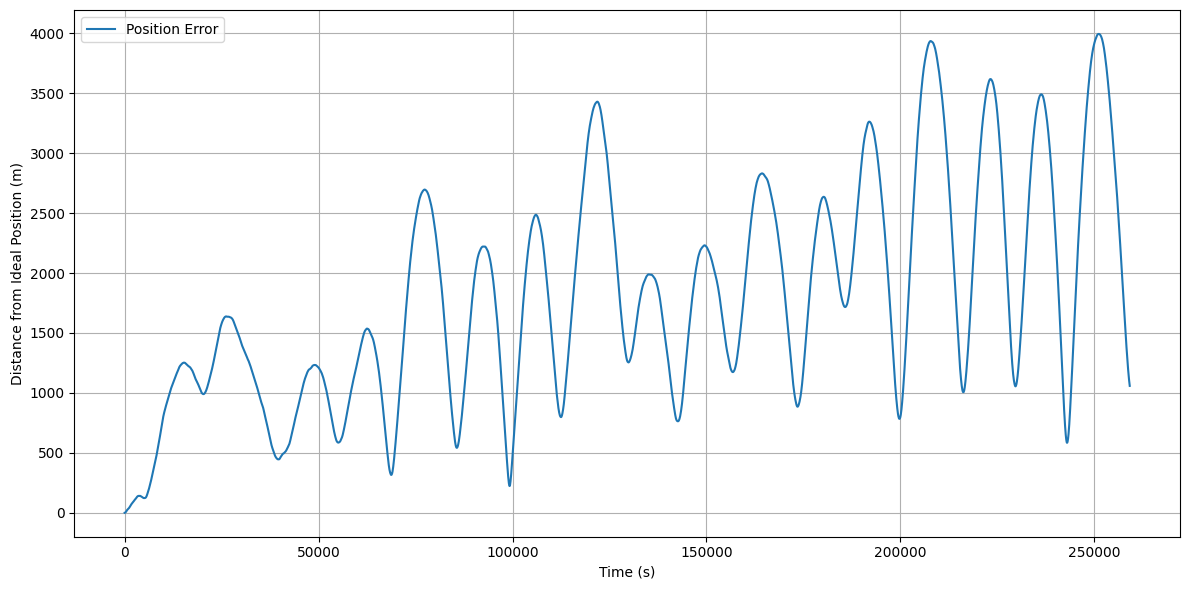

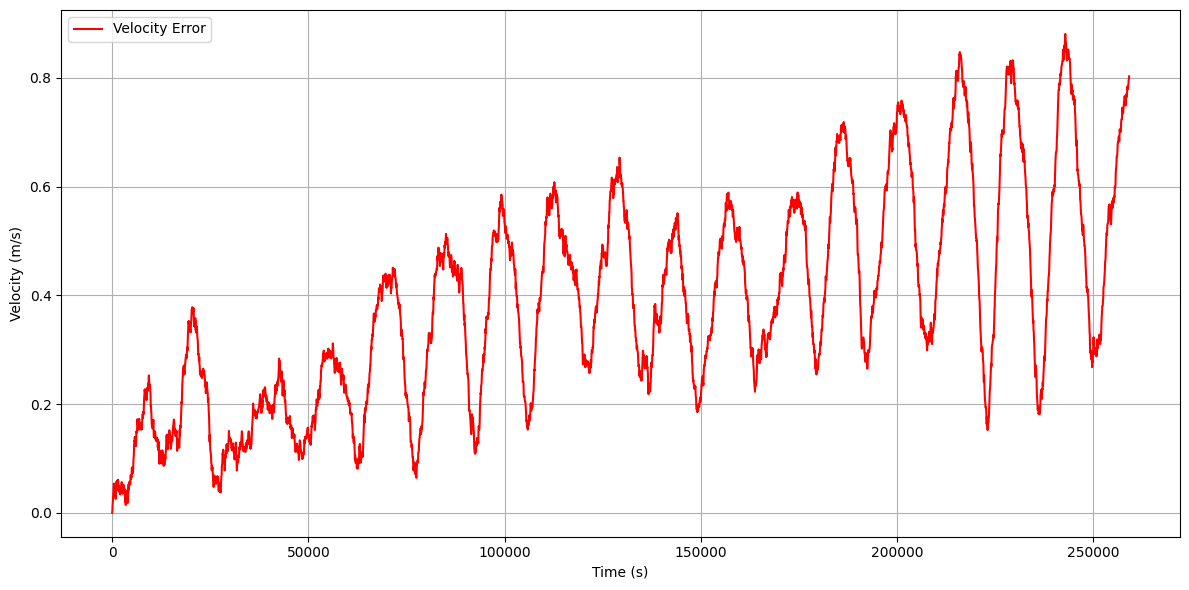

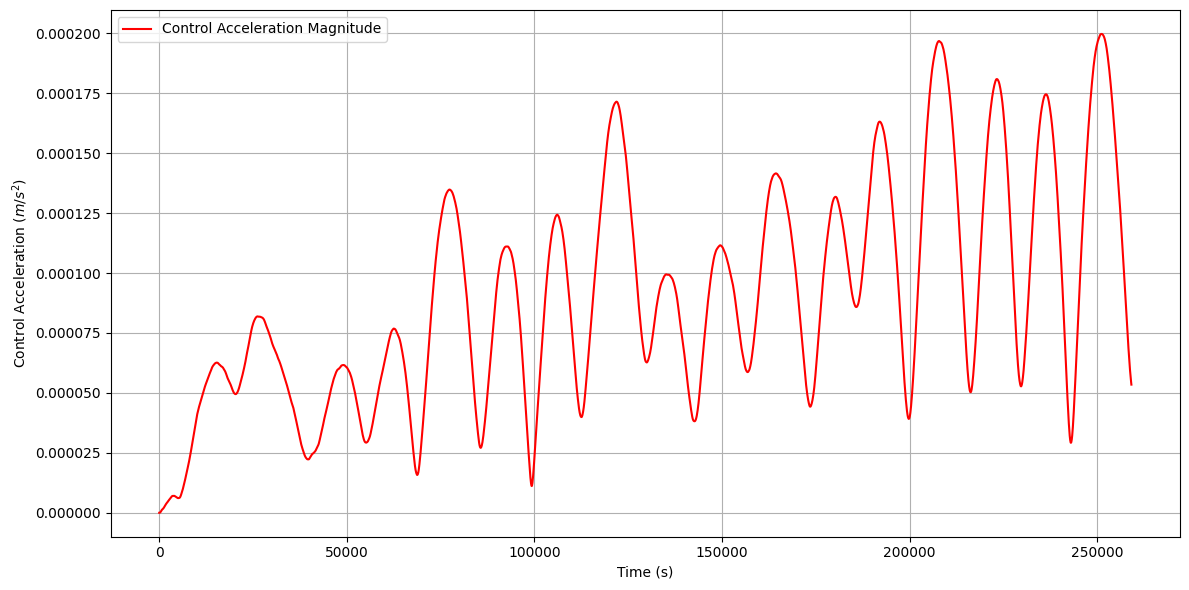

In [ ]:
plot_position_error(log_df=pddf_new, policy_params=trueSatParams, title = False, deadband = False)
plot_velocity_error(log_df=pddf_new, policy_params=trueSatParams, title = False, deadband = False)
plot_control_acceleration(log_df=pddf_new, title = False)

## PD Inference plots


In [ ]:
pdmcmc_samples = pdmcmc.get_samples()
pdmcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     logKd    -13.59      0.22    -13.57    -13.92    -13.23   5678.76      1.00
     logKp    -16.81      0.02    -16.81    -16.84    -16.77   7205.82      1.00
  logSigma     -6.91      0.01     -6.91     -6.92     -6.90   7930.92      1.00

Number of divergences: 0


In [ ]:
print(np.exp(-13.79))

1.0258387369820063e-06


Displaying Trace Plots...


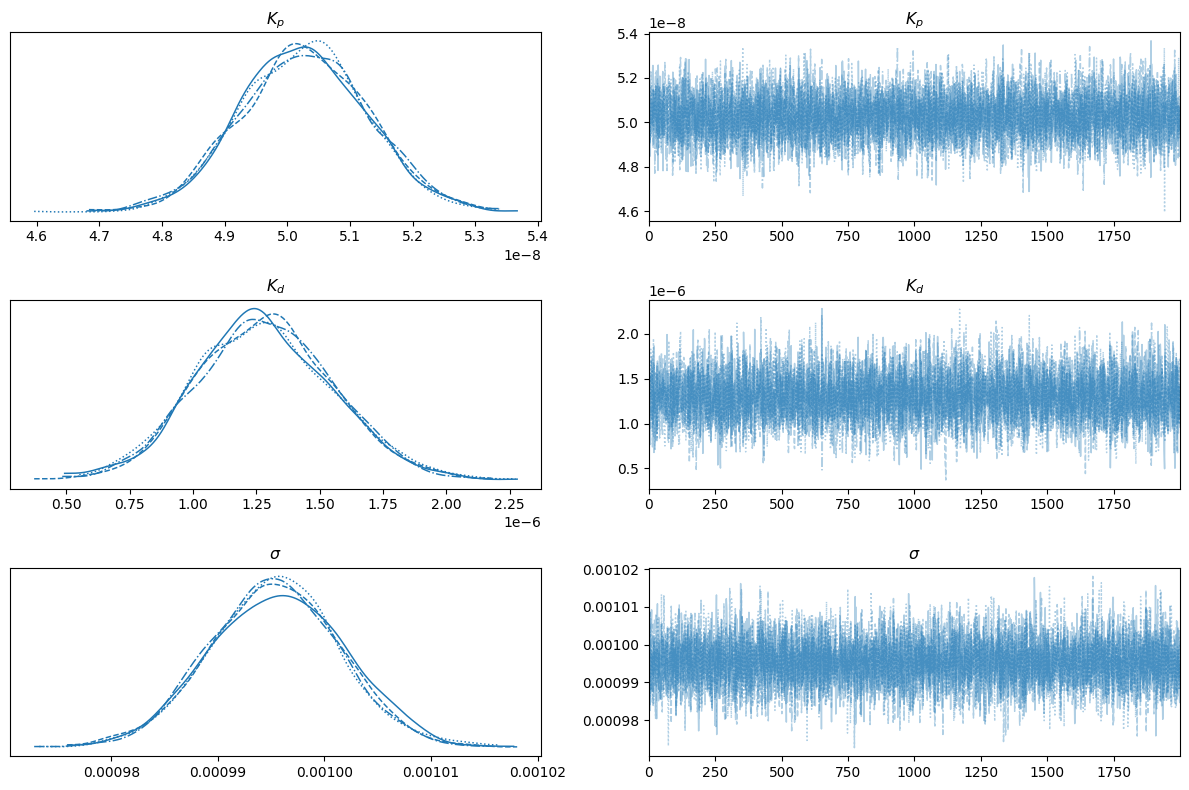

Displaying Posterior Plots...


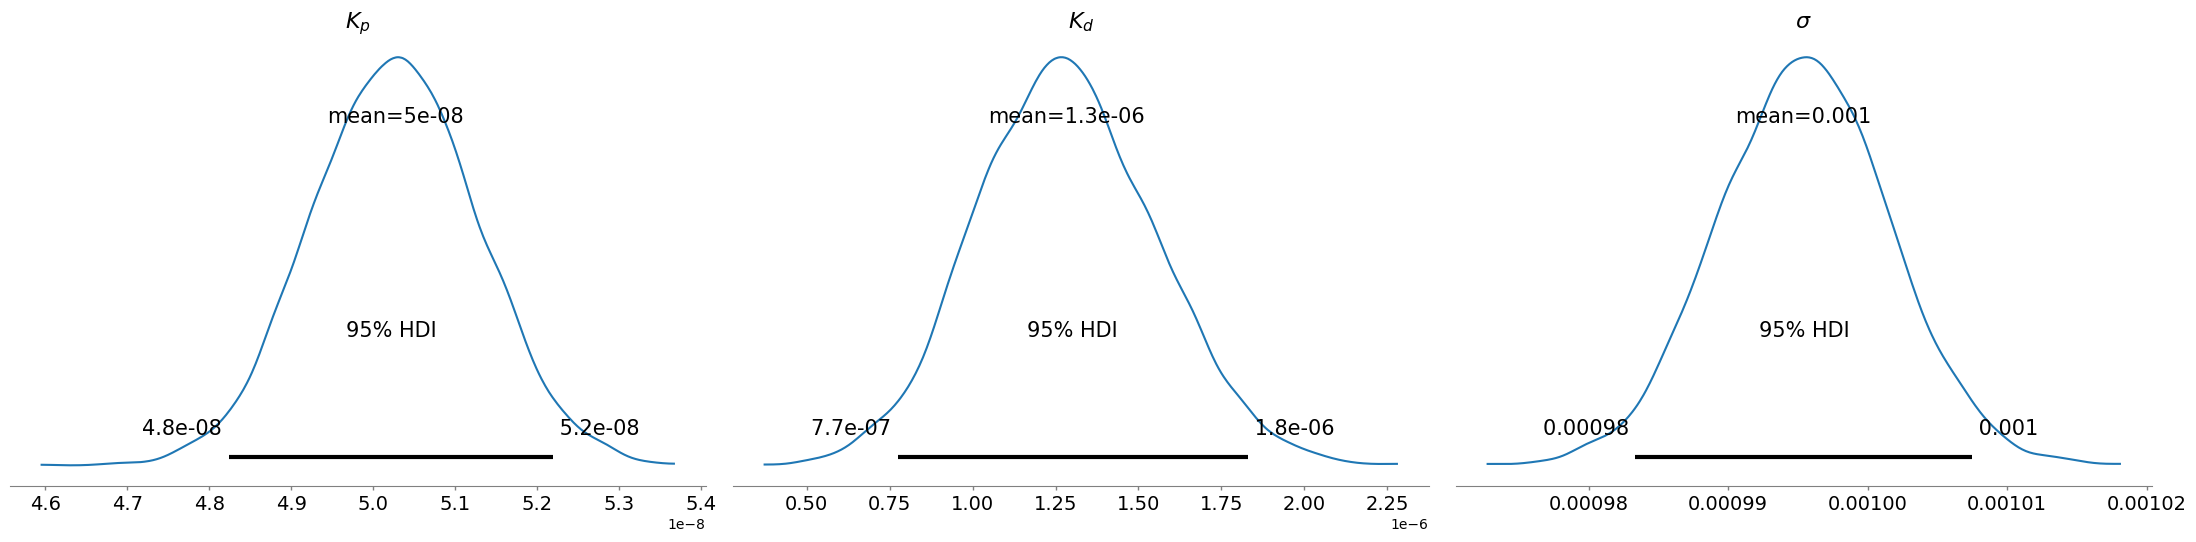

In [ ]:
trace_posterior_plotsif(pdmcmc)

Generating Prior vs. Posterior vs. Truth plot (in Log-Space)...


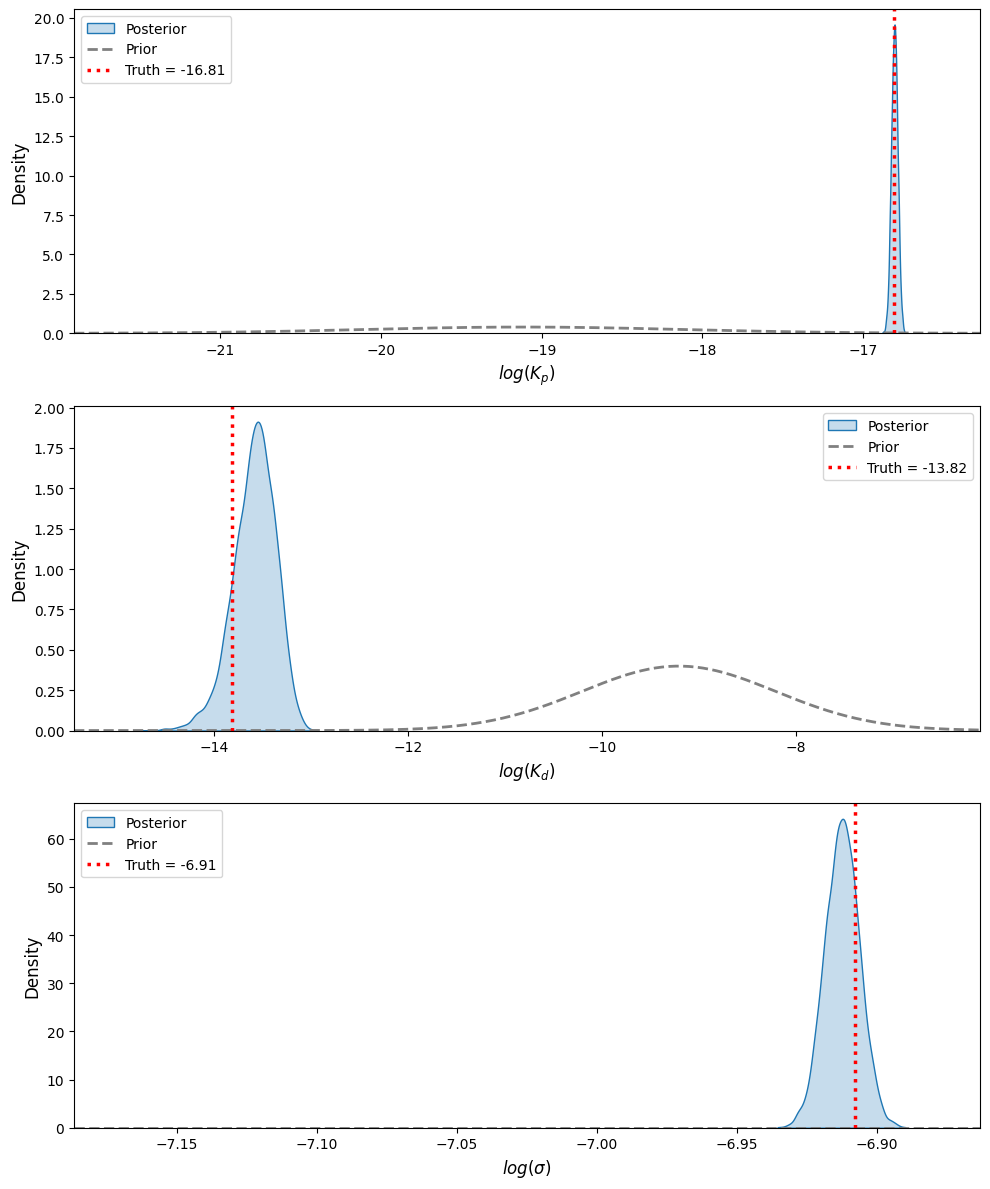

In [ ]:
plot_prior_posterior_truthif(pdmcmc, trueSatParams, priorNums, 1e-3)

## Posterior Simulations

In [ ]:
posterior_sims_pd = simulate_from_posterior(
    pdmcmc,
    trueSatParams,
    daysToProp,
    dt,
    longitudeDeg=0.0,
    num_sims=100
)


--- Running 100 Posterior Predictive Simulations ---
Running simulation 10 of 100...
Running simulation 20 of 100...


KeyboardInterrupt: 

In [ ]:
saveData(posterior_sims_pd, "pd100PosteriorSims")

### Posterior Simulations Histogram plots

In [ ]:
controlAccelMaxHistogramPlot(pddf_new, posterior_sims_pd)

In [ ]:
controlAccelHistogramPlot(pddf_new, posterior_sims_pd)

In [ ]:
positionErrorHistogramPlot(pddf_new, posterior_sims_pd)

In [ ]:
maxErrorHistogramPlot(pddf_new, posterior_sims_pd)

In [ ]:
plot_individual_thrust_histogramsif(
    pddf_new,
    posterior_sims_pd,
    num_sim_plots=8,     # Adjust how many simulation plots you want
    base_title=""
)

In [ ]:
plot_individual_deadband_histogramsif(
    pddf_new,                  # original
    posterior_sims_pd,         # list of sim DataFrames
    deadband_radius= 0.0,     # your deadband value
    num_sim_plots=8,           # makes a 3x3
    base_title="",
    bins=25,
    random_select=False        # take first 8 deterministically
)


In [ ]:
plot_posterior_deadband_distance_histogramsif(
    pddf_new,
    posterior_sims_pd,
    deadband_radius=0.0, # Using 0 since inference model assumes gamma=0
    title="Posterior Predictive Check (PD Data - Distance from Deadband Histograms)"
)

### Plot time series posterior simulations

In [ ]:
plot_posterior_simulationsif(
    pddf_new,
    posterior_sims_pd,
    title=""
)

In [ ]:
plot_posterior_mean_timeseriesif(
    pddf_new,
    posterior_sims_pd,
    title=""
)

In [ ]:
plot_posterior_max_timeseriesif(
    pddf_new,
    posterior_sims_pd,
    title=""
)

In [ ]:
plot_posterior_mean_thrust_componentsif( pddf_new,
    posterior_sims_pd, title="")

In [ ]:
plot_posterior_mean_accel_magnitudeif(pddf_new,
    posterior_sims_pd, title = "")


In [ ]:
plot_posterior_variance_accel_magnitudeif(
    posterior_sims_pd,
    title = "",
    length_strategy="max-pad",   # pads shorter sims with zeros
    use_time_from_first_kept=True,
    verbose=True
)


In [ ]:
plot_posterior_mean_accel_magnitudeif(pddf_new, posterior_sims_pd)

In [ ]:
fourPosteriorCheckif(pddf_new, posterior_sims_pd)

In [ ]:
del pdmcmc

## PD Inference Sensitivity Analysis

In [ ]:
#these are the actual parameters for the satellite
dt = 60
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
trueSatParams = {
    'gamma': 000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNums = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

import matplotlib.pyplot as plt
#how many days of data you want to generate and train on
daysToProp = 3
#how much time inbetween samples, can use the graphs in the test simulations to see if the drift distance is resonable
dt = 60
#specify the policy you want to use
policy = 'pd' # can do pd, bb, or lqr
#how much noise you want applied to the velocity
noise = 1e-3
#what you want the acceptance ratio to be
adapt_delta = .95
#how many warm up iterations you want
warmupNum = 1000
#how many iterations you want
sampleNum = 5000
#this determines if inside the nut sampler the sampler can tune the step size _> this should really always be true
adapt_step_size = True
pdmcmc, pddf_new = run_bayesian_inference(daysToProp, policy, dt, noise, trueSatParams, priorNums, adapt_delta, warmupNum, sampleNum, adapt_step_size, num_chains=4, verbose = True)


--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


sample: 100%|██████████| 2000/2000 [00:48<00:00, 41.02it/s]



--- 3. Inference Results ---


In [ ]:
def differentPriors():
    priorNums1 = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-2,          # pd constant
    'KdMean': 1e-2,            # pd constant
    'gammaSTD': 1.5,        # 5 km deadband radius
    'KpSTD':  1.5,          # pd constant
    'KdSTD': 1.5,          # pd constant
    }
    priorNums2 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-10 ,          # pd constant
        'KdMean': 1e-8,         # pd constant
        'gammaSTD': 1.5,        # 5 km deadband radius
        'KpSTD':  1.5,          # pd constant
        'KdSTD': 1.5,           # pd constant
    }
    priorNums3 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-8  ,          # pd constant
        'KdMean': 1e-6 ,         # pd constant
        'gammaSTD': 5,        # 5 km deadband radius
        'KpSTD':  5,          # pd constant
        'KdSTD': 5,           # pd constant
    }
    priorNums4 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-2  ,          # pd constant
        'KdMean': 1e-2,             # pd constant
        'gammaSTD': 5,        # 5 km deadband radius
        'KpSTD':  5,          # pd constant
        'KdSTD': 5,           # pd constant
    }
    priorNums5 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-10  ,          # pd constant
        'KdMean': 1e-8,            # pd constant
        'gammaSTD': 5,        # 5 km deadband radius
        'KpSTD':  5,          # pd constant
        'KdSTD': 5,           # pd constant
    }

    priorNums6 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-8  ,          # pd constant
        'KdMean': 1e-6 ,          # pd constant
        'gammaSTD': 10,        # 5 km deadband radius
        'KpSTD':  10,          # pd constant
        'KdSTD': 10,            # pd constant
    }

    priorNums7 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-2,          # pd constant
        'KdMean': 1e-2,            # pd constant
        'gammaSTD': 10,        # 5 km deadband radius
        'KpSTD':  10,          # pd constant
        'KdSTD': 10,           # pd constant
    }
    priorNums8 = {
        'gammaMean': 0,        # 5 km deadband radius
        'KpMean':  5e-10  ,          # pd constant
        'KdMean': 1e-8,          # pd constant
        'gammaSTD': 10,        # 5 km deadband radius
        'KpSTD':  10,          # pd constant
        'KdSTD': 10,           # pd constant
    }

    return [priorNums1, priorNums2, priorNums3, priorNums4, priorNums5, priorNums6, priorNums7, priorNums8]
    #return [priorNums1, priorNums3, priorNums4, priorNums5, priorNums6, priorNums7, priorNums8]


In [ ]:
# 3. Run the sensitivity analysis
all_inf_data, all_logs = runDiffPriors(
    daysToProp, policy, dt, noise, trueSatParams,
    adapt_delta, warmupNum, sampleNum, adapt_step_size, num_chains =2
)


--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


sample: 100%|██████████| 2000/2000 [00:28<00:00, 70.48it/s] 



--- 3. Inference Results ---
--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


sample: 100%|██████████| 2000/2000 [00:51<00:00, 38.60it/s]



--- 3. Inference Results ---
--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


...


--- 3. Inference Results ---
--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


sample: 100%|██████████| 2000/2000 [01:41<00:00, 19.69it/s]



--- 3. Inference Results ---
--- 1. Generating Ground Truth Data ---
Data generation complete.

--- 2. Running Bayesian Inference with NumPyro ---


sample: 100%|██████████| 2000/2000 [00:34<00:00, 58.55it/s] 


--- 3. Inference Results ---


In [ ]:
saveData(all_inf_data, "pdSensitivityAnalysisAllInfData")
saveData( all_logs, "pdSensitivityAnalysisAllLogs")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import logging
import numpy as np # Needed for standard deviation and list concatenation

def plot_posterior_comparisonSA(all_inference_data, var_names, trueSatParams):
    """
    Plots overlaid KDEs for posteriors from different priors.

    Args:
        all_inference_data (dict): Dictionary where keys are prior names
                                   and values are arviz.InferenceData objects.
        var_names (list): List of parameter names (strings) to plot
                          (e.g., ['Kp', 'Kd', 'sigma']).
        trueSatParams (dict): Dictionary of true parameter values to plot as vertical lines.
    """
    if not all_inference_data:
        logging.warning("No inference data to plot.")
        return

    num_vars = len(var_names)
    if num_vars == 0:
        logging.warning("No variable names provided to plot.")
        return

    fig, axes = plt.subplots(num_vars, 1, figsize=(12, 6 * num_vars), squeeze=False)
    axes = axes.flatten()

    prior_names = list(all_inference_data.keys())
    priorLegendNames = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8']

    # --- Dictionary for "snazzy" LaTeX labels ---
    latex_labels = {
        'logKp': r'$log(K_p)$',
        'logKd': r'$log(K_d)$',
        'logSigma': r'$log(\sigma)$'
    }
    # ----------------------------------------------------

    for i, var_name in enumerate(var_names):
        ax = axes[i]
        all_samples_for_var = []
        has_data = False

        latex_name = latex_labels.get(var_name, var_name)
        k = 0
        for prior_name in prior_names:
            inf_data = all_inference_data.get(prior_name)
            if inf_data is None:
                continue

            # Check if var_name is in the posterior
            if var_name in inf_data.posterior:
                # Extract samples, flatten across chains and draws
                samples = inf_data.posterior[var_name].values.flatten()

                # Store samples for dynamic limit calculation later
                all_samples_for_var.append(samples)

                # Plot KDE
                sns.kdeplot(samples, ax=ax, label=priorLegendNames[k], fill=True, alpha=0.3)
                has_data = True
            else:
                logging.warning(f"Variable '{var_name}' not found in posterior for '{prior_name}'.")
            k +=1

        # Plot true value
        trueValues = {'logKp':math.log(trueSatParams.get('Kp')),
                       'logKd': math.log(trueSatParams.get('Kd')),
                       'logSigma': math.log(1e-3)}

        ax.axvline(
            trueValues[var_name],
            color='r',
            linestyle='--',
            label=f"True {latex_name} "
        )

        if has_data:
            # --- START: Dynamic X-axis Limiting Block ---
            if var_name == 'logKd': # Apply this logic specifically to the middle plot
                combined_samples = np.concatenate(all_samples_for_var)

                # Calculate mean and standard deviation of all samples for this variable
                mean = np.mean(combined_samples)
                std = np.std(combined_samples)

                # Define buffer (e.g., 3 standard deviations)
                # You can adjust the factor '3.0' if you want a wider or narrower view
                buffer_factor = 3.0
                x_min = mean - buffer_factor * std
                x_max = mean + buffer_factor * std

                # Apply the calculated limits
                ax.set_xlim(x_min, x_max)

                # Optional: Add a small, fixed padding if the calculated range is too tight
                # padding = 0.005
                # ax.set_xlim(x_min - padding, x_max + padding)

            # --- END: Dynamic X-axis Limiting Block ---

            ax.set_xlabel(latex_name, fontsize=12)
            ax.set_ylabel("Density", fontsize=12)
            ax.legend(fontsize=10)
            ax.grid(True, linestyle='--', alpha=0.6)
        else:
            ax.set_title(f"No data to plot for {latex_name}", fontsize=16)

    plt.tight_layout()
    plt.show()

In [ ]:
import arviz as az

# 1. Create a new dictionary to hold the converted objects
all_inf_data_converted = {}

# 2. Loop through your dictionary of MCMC objects and convert each one
#    (This assumes 'all_inf_data' is like {'model_name_1': mcmc_obj_1, ...})
for model_name, mcmc_obj in all_inf_data.items():
    all_inf_data_converted[model_name] = az.from_numpyro(mcmc_obj)

# 3. Now, call your function using the NEW dictionary of InferenceData objects
param_vars_to_plot = ['logKp', 'logKd', 'logSigma']
plot_posterior_comparisonSA(all_inf_data_converted, param_vars_to_plot, trueSatParams)

NameError: name 'all_inf_data' is not defined

The BB policy remains as before (i.e., it still has a deadband).

In [ ]:
#these are the actual parameters for the satellite
dt = 60
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
trueSatParamsBB = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNums = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

import matplotlib.pyplot as plt
#how many days of data you want to generate and train on
daysToProp = 3
#how much time inbetween samples, can use the graphs in the test simulations to see if the drift distance is resonable
dt = 60
#specify the policy you want to use
policy = 'bb' # can do pd, bb, or lqr
#how much noise you want applied to the velocity
noise = 1e-3
#what you want the acceptance ratio to be
adapt_delta = .95
#how many warm up iterations you want
warmupNum = 1000
#how many iterations you want
sampleNum = 5000
#this determines if inside the nut sampler the sampler can tune the step size _> this should really always be true
adapt_step_size = True
bbmcmc,bbdf_new = run_bayesian_inference(daysToProp, policy, dt, noise, trueSatParamsBB, priorNums, adapt_delta, warmupNum, sampleNum, adapt_step_size, num_chains=4)


## BB Satellite plots of performance

In [ ]:
plot_position_error(log_df=bbdf_new, policy_params=trueSatParamsBB, title = False, deadband = trueSatParamsBB.get('gamma'))
plot_velocity_error(log_df=bbdf_new, policy_params=trueSatParamsBB, title = False, deadband = False)

## BB Inference plots

In [ ]:
trace_posterior_plotsif(bbmcmc)

In [ ]:
bbmcmc_samples = bbmcmc.get_samples()
bbmcmc.print_summary()

In [ ]:
print(np.exp(-14.12 ))

## BB Posterior Simulations

In [ ]:
posterior_sims_bb = simulate_from_posterior(
    bbmcmc,
    trueSatParamsBB,
    daysToProp,
    dt,
    longitudeDeg=0.0,
    num_sims=100
)

In [ ]:
saveData( posterior_sims_bb, "bb100PosteriorSims")

### BB Posterior Simulation histogram plots

In [ ]:
controlAccelMaxHistogramPlot(bbdf_new, posterior_sims_bb)

In [ ]:
controlAccelHistogramPlot(bbdf_new, posterior_sims_bb)

In [ ]:
positionErrorHistogramPlot(bbdf_new, posterior_sims_bb)

In [ ]:
controlAccelHistogramPlot(bbdf_new, posterior_sims_bb)

In [ ]:
maxErrorHistogramPlot(bbdf_new, posterior_sims_bb)

In [ ]:
plot_individual_thrust_histogramsif(
    bbdf_new,
    posterior_sims_bb,
    num_sim_plots=8,     # Adjust how many simulation plots you want
    base_title=""
)

In [ ]:
plot_individual_deadband_histogramsif(
    bbdf_new,                  # original
    posterior_sims_bb,         # list of sim DataFrames
    deadband_radius= 0.0,     # your deadband value
    num_sim_plots=8,           # makes a 3x3
    base_title="",
    bins=25,
    random_select=False        # take first 8 deterministically
)


### BB Plot posterior time series

In [ ]:
plot_posterior_simulationsif(
    bbdf_new,
    posterior_sims_bb,
    title=""
)

In [ ]:
plot_posterior_mean_timeseriesif(
    bbdf_new,
    posterior_sims_bb,
    title=""
)

In [ ]:
plot_posterior_max_timeseriesif(
    bbdf_new,
    posterior_sims_bb,
    title=""
)

In [ ]:
plot_posterior_mean_thrust_componentsif( bbdf_new,
    posterior_sims_bb, title="")

In [ ]:
plot_posterior_mean_accel_magnitudeif(bbdf_new,
    posterior_sims_bb, title = "")


In [ ]:
plot_posterior_variance_accel_magnitudeif(
    posterior_sims_bb,
    title = "",
    length_strategy="max-pad",   # pads shorter sims with zeros
    use_time_from_first_kept=True,
    verbose=True
)


In [ ]:
plot_posterior_mean_accel_magnitudeif(bbdf_new, posterior_sims_bb)

## MMD Shizzle BB

In [ ]:
sim_key = jax.random.PRNGKey(42)
mmd_key = jax.random.PRNGKey(314159)

trueSatParamsBB = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }

true_simsBBMMD, mcmc_simsBBMMD = getMMDData(
    mcmc_obj = bbmcmc,
    realPolicy = 'bb',                      # e.g., 'pd' or 'bb' (whatever your run_full_simulation expects)
    base_params_template = trueSatParamsBB,            # dict of baseline "true" params
    simulation_key=sim_key,             # kept for API compatibility; not used here
    mmd_key= mmd_key,                    # kept for API compatibility; not used here
    num_sims_per_sample=10,
    daysToProp=1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)"),
    mmd_kernel="rbf",                # kept for API compatibility; not used here
    mmd_sigma=1.0)                   # kept for API compatibility; not used here

                # first 5 rows of [X,Y,Z]


In [ ]:

saveData( true_simsBBMMD, "true_simsBBMMD")
saveData( mcmc_simsBBMMD , "mcmc_simsBBMMD")

In [ ]:
rbfSigma = np.std(mcmc_simsBBMMD[0])
mmdDistListRBFBB = runMMDOnAllSims(mcmc_simsBBMMD, true_simsBBMMD, kernel = "rbf", sigma = rbfSigma)

In [ ]:
mmdDistListDotBB = runMMDOnAllSims(mcmc_simsBBMMD, true_simsBBMMD, kernel = "dot", sigma = rbfSigma)

In [ ]:
bbMmdDistListCosine = runMMDOnAllSims(mcmc_simsBBMMD, true_simsBBMMD, kernel = "cosine", sigma = rbfSigma)

### Now Sim the False BB and LQR Policies

In [ ]:
sim_key = jax.random.PRNGKey(42)
mmd_key = jax.random.PRNGKey(314159)

falseSatParamsBB = {
    'gamma': 1000,        # 5 km deadband radius
    'Kp':  5e-9  ,          # pd constant
    'Kd': 1e-7 ,           # pd constant
    'maxA': .07/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }

bbFalseSims = simFalsePolicy(
    realPolicy = 'bb',                      # e.g., 'pd' or 'bb' (whatever your run_full_simulation expects)
    base_params_template = falseSatParamsBB,            # dict of baseline "true" params
    num_sims_per_sample=10,
    daysToProp=1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)"))                   # kept for API compatibility; not used here


In [ ]:
sim_key = jax.random.PRNGKey(42)
mmd_key = jax.random.PRNGKey(314159)


dt = 60
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
falseSatParamsLQR= {
    'gamma': 1500,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': 1.5 * np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': 1.5 * np.eye(3) * 1000000  # Penalize large acceleration
    }

lqrFalseSims = simFalsePolicy(
    realPolicy = 'lqr',                      # e.g., 'pd' or 'bb' (whatever your run_full_simulation expects)
    base_params_template = falseSatParamsLQR,            # dict of baseline "true" params
    num_sims_per_sample=10,
    daysToProp=1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)"))

### Calculate the MMD scores for the false

#### bb false calcs

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
bbFalseMmdScoreDotBB = mmd2_unbiased_jax(mmd_key, bbFalseSims, true_simsBBMMD, kernel= "dot", sigma=rbfSigma)
print(bbFalseMmdScoreDotBB)

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
bbFalseMmdScoreRbfBB = mmd2_unbiased_jax(mmd_key, bbFalseSims, true_simsBBMMD, kernel= "rbf", sigma=rbfSigma)
print(bbFalseMmdScoreRbfBB)

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
bbFalseMmdScoreCosineBB = mmd2_unbiased_jax(mmd_key, bbFalseSims, true_simsBBMMD, kernel= "cosine", sigma=rbfSigma)
print(bbFalseMmdScoreCosineBB)

#### Lqr false calcs

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
lqrFalseMmdScoreDotBB = mmd2_unbiased_jax(mmd_key, lqrFalseSims, true_simsBBMMD, kernel= "dot", sigma=rbfSigma)
print(lqrFalseMmdScoreDotBB)

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
lqrFalseMmdScoreRbfBB = mmd2_unbiased_jax(mmd_key, lqrFalseSims, true_simsBBMMD, kernel= "rbf", sigma= rbfSigma)
print(lqrFalseMmdScoreRbfBB)

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
lqrFalseMmdScoreCosineBB = mmd2_unbiased_jax(mmd_key, lqrFalseSims, true_simsBBMMD, kernel= "cosine", sigma= rbfSigma)
print(lqrFalseMmdScoreCosineBB)

#### Get the global assignment kernel

In [ ]:
!pip install tslearn

In [ ]:
import tslearn
from tslearn.metrics import gak, sigma_gak

def getTheGAK(comparisonSimm, trueSim):
    X = []
    X.append(jnp.asarray(comparisonSimm, dtype=float))
    X.append(jnp.asarray(trueSim, dtype=float))

    sigma = sigma_gak(X)
    score = gak(X[0], X[1], sigma=sigma)

    return score


In [ ]:
def getGakForMultiSims(comparisonSims, trueSim):
    allScores = []
    for i in range(0,len(comparisonSims)):
        score = getTheGAK(comparisonSims[i], trueSim)
        allScores.append(score)
    return allScores

In [ ]:
import tslearn
from tslearn.metrics import gak, sigma_gak

X = []
X.append(jnp.asarray(lqrFalseSims, dtype=float))
X.append(jnp.asarray(true_simsBBMMD, dtype=float))

sigma = sigma_gak(X)
k_01 = gak(X[0], X[1], sigma=sigma)
print("The score is: ", k_01)

In [ ]:
mmdScore = getTheGAK( true_simsBBMMD, lqrFalseSims)
print(mmdScore)

In [ ]:
print("The score is: ", k_01)

In [ ]:
print("Length of true sims")
print(len(true_simsBBMMD))
print(len(true_simsBBMMD[0]))
print(true_simsBBMMD[0][0])
print("print length of comparison sims")
print(len(mcmc_simsBBMMD))
print(len(mcmc_simsBBMMD[0]))
print(len(mcmc_simsBBMMD[0][0]))
print(mcmc_simsBBMMD[0][0][0])

In [ ]:
lqrFalseMmdScoreGAKBB = getTheGAK(lqrFalseSims, true_simsBBMMD)
bbFalseMmdScoreGAKBB = getTheGAK( bbFalseSims, true_simsBBMMD)
mmdDistListGAKBB = getGakForMultiSims( mcmc_simsBBMMD, true_simsBBMMD)


### MMD Conclusion stats

In [ ]:
print("\nSummary stats for the Global Alignment kernel BB:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreGAKBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreGAKBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListGAKBB))

In [ ]:
print("\nSummary stats for the dot kernel:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreDotBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreDotBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListDotBB))
print()

In [ ]:
print("\nSummary stats for the rbf kernel:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreRbfBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreRbfBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListRBFBB))
print()

In [ ]:
print("\nSummary stats for the Cosine kernel:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreCosineBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreCosineBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(bbMmdDistListCosine ))
print()

In [ ]:
print("\nSummary stats for the Global Alignment kernel BB:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreGAKBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreGAKBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListGAKBB))
print()
print("\nSummary stats for the dot kernel:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreDotBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreDotBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListDotBB))
print()
print("\nSummary stats for the rbf kernel:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreRbfBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreRbfBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListRBFBB))
print()
print("\nSummary stats for the Cosine kernel:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreCosineBB)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreCosineBB)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(bbMmdDistListCosine ))
print()

In [ ]:
#these are the actual parameters for the satellite
dt = 60
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
trueSatParamsLQR = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNums = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

import matplotlib.pyplot as plt
#how many days of data you want to generate and train on
daysToProp = 3
#how much time inbetween samples, can use the graphs in the test simulations to see if the drift distance is resonable
dt = 60
#specify the policy you want to use
policy = 'lqr' # can do pd, bb, or lqr
#how much noise you want applied to the velocity
noise = 1e-3
#what you want the acceptance ratio to be
adapt_delta = .95
#how many warm up iterations you want
warmupNum = 1000
#how many iterations you want
sampleNum = 5000
#this determines if inside the nut sampler the sampler can tune the step size _> this should really always be true
adapt_step_size = True
lqrmcmc,lqrdf_new = run_bayesian_inference(daysToProp, policy, dt, noise, trueSatParamsLQR, priorNums, adapt_delta, warmupNum, sampleNum, adapt_step_size, num_chains=4)


## LQR Inference plots

In [ ]:
lqrmcmc_samples = lqrmcmc.get_samples()
lqrmcmc.print_summary()

In [ ]:
trace_posterior_plotsif(lqrmcmc)

## LQR Satellite plots of performance

In [ ]:
plot_position_error(log_df=lqrdf_new, policy_params=trueSatParamsLQR, title = False, deadband = trueSatParamsLQR.get('gamma'))
plot_velocity_error(log_df=lqrdf_new, policy_params=trueSatParamsLQR, title = False, deadband = False)

## LQR Inference plots

In [ ]:
trace_posterior_plotsif(lqrmcmc)

In [ ]:
lqrmcmc_samples = lqrmcmc.get_samples()
lqrmcmc.print_summary()

## LQR Posterior Simulations

In [ ]:
posterior_sims_lqr = simulate_from_posterior(
    lqrmcmc,
    trueSatParamsLQR,
    daysToProp,
    dt,
    longitudeDeg=0.0,
    num_sims=100
)

In [ ]:
saveData(posterior_sims_lqr, "lqr100PosteriorSims")

### LQR posterior simulation graphs

In [ ]:
controlAccelMaxHistogramPlot(lqrdf_new, posterior_sims_lqr)

In [ ]:
controlAccelHistogramPlot(lqrdf_new, posterior_sims_lqr)

In [ ]:
positionErrorHistogramPlot(lqrdf_new, posterior_sims_lqr)

In [ ]:
controlAccelHistogramPlot(lqrdf_new, posterior_sims_lqr)

In [ ]:
maxErrorHistogramPlot(lqrdf_new, posterior_sims_lqr)

In [ ]:
plot_individual_thrust_histogramsif(
    lqrdf_new,
    posterior_sims_lqr,
    num_sim_plots=8,     # Adjust how many simulation plots you want
    base_title=""
)

In [ ]:
plot_individual_deadband_histogramsif(
    lqrdf_new,                  # original
    posterior_sims_lqr,         # list of sim DataFrames
    deadband_radius= 0.0,     # your deadband value
    num_sim_plots=8,           # makes a 3x3
    base_title="",
    bins=25,
    random_select=False        # take first 8 deterministically
)

### LQR plot posterior time series

In [ ]:
plot_posterior_simulationsif(
    lqrdf_new,
    posterior_sims_lqr,
    title=""
)

In [ ]:
plot_posterior_mean_timeseriesif(
    lqrdf_new,
    posterior_sims_lqr,
    title=""
)

In [ ]:
plot_posterior_max_timeseriesif(
    lqrdf_new,
    posterior_sims_lqr,
    title=""
)

In [ ]:
plot_posterior_mean_thrust_componentsif( lqrdf_new,
    posterior_sims_lqr, title="")

In [ ]:
plot_posterior_mean_accel_magnitudeif(lqrdf_new,
    posterior_sims_lqr, title = "")


In [ ]:
plot_posterior_variance_accel_magnitudeif(
    posterior_sims_lqr,
    title = "",
    length_strategy="max-pad",   # pads shorter sims with zeros
    use_time_from_first_kept=True,
    verbose=True
)

In [ ]:
plot_posterior_mean_accel_magnitudeif(lqrdf_new, posterior_sims_lqr)

## LQR MMD Shizzle

### Simulate the infered policy and true lqr data

In [ ]:
sim_key = jax.random.PRNGKey(42)
mmd_key = jax.random.PRNGKey(314159)

dt = 60
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
trueSatParamsLQR = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }

true_simsLqr, mcmc_simsLqr = getMMDData(
    mcmc_obj = lqrmcmc,
    realPolicy = 'lqr',                      # e.g., 'pd' or 'bb' (whatever your run_full_simulation expects)
    base_params_template = trueSatParamsLQR,            # dict of baseline "true" params
    simulation_key=sim_key,             # kept for API compatibility; not used here
    mmd_key= mmd_key,                    # kept for API compatibility; not used here
    num_sims_per_sample=10,
    daysToProp=1,
    dt=60,
    longitudeDeg=0.0,
    sigma_v=1e-3,
    cols_to_compare=("X (m)", "Y (m)", "Z (m)"),
    mmd_kernel="rbf",                # kept for API compatibility; not used here
    mmd_sigma=1.0)                   # kept for API compatibility; not used here

                # first 5 rows of [X,Y,Z]


In [ ]:

saveData( true_simsLqr, "true_simsLqrMMD")
saveData( mcmc_simsLqr, "mcmc_simsLqrMMD")

In [ ]:
mmdDistListLqrDot = runMMDOnAllSims(mcmc_simsLqr, true_simsLqr, kernel = "dot", sigma = rbfSigma)
print(len(mmdDistListLqrDot))

In [ ]:
mmdDistListLqrRbf  = runMMDOnAllSims(mcmc_simsLqr, true_simsLqr, kernel = "rbf", sigma = rbfSigma)

In [ ]:
mmdDistListLqrCosine= runMMDOnAllSims(mcmc_simsLqr, true_simsLqr, kernel = "cosine", sigma = rbfSigma)

### False lqr and false bb vs true sims

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
lqrvbbFalseMmdScoreDot = mmd2_unbiased_jax(mmd_key, bbFalseSims, true_simsLqr, kernel= "dot", sigma=rbfSigma)
print(lqrvbbFalseMmdScoreDot)

In [ ]:
mmd_key = jax.random.PRNGKey(314159)
lqrvlqrFalseMmdScoreDot = mmd2_unbiased_jax(mmd_key, lqrFalseSims, true_simsLqr, kernel= "dot", sigma=rbfSigma)
print(lqrvlqrFalseMmdScoreDot)

In [ ]:
lqrvbbFalseMmdScoreRbf = mmd2_unbiased_jax(mmd_key, bbFalseSims, true_simsLqr, kernel= "rbf", sigma= rbfSigma)

In [ ]:
lqrvlqrFalseMmdScoreRbf = mmd2_unbiased_jax(mmd_key, lqrFalseSims, true_simsLqr, kernel= "rbf", sigma= rbfSigma)

In [ ]:
lqrvbbFalseMmdScoreCosine = mmd2_unbiased_jax(mmd_key, bbFalseSims, true_simsLqr, kernel= "cosine", sigma= rbfSigma)

In [ ]:
lqrvlqrFalseMmdScoreCosine = mmd2_unbiased_jax(mmd_key, lqrFalseSims, true_simsLqr, kernel= "cosine", sigma= rbfSigma)

#### Get the GAK

In [ ]:
print(len(mcmc_simsLqr))

In [ ]:
lqrFalseMmdScoreGAKLQR = getTheGAK(lqrFalseSims, true_simsLqr)
bbFalseMmdScoreGAKLQR = getTheGAK( bbFalseSims, true_simsLqr)
mmdDistListGAKLQR = getGakForMultiSims( mcmc_simsLqr, true_simsLqr)


### summary stats

In [ ]:
print("\nSummary stats for the Global Alignment kernel lqr:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreGAKLQR)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreGAKLQR)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListGAKLQR))


In [ ]:
print("\nSummary stats for the dot kernel:")
print("The false lqr sims vs the true lqr sims mmd score:",lqrvlqrFalseMmdScoreDot)
print("The false bb sims vs the true lqr sims mmd score:",lqrvbbFalseMmdScoreDot)
print("Finally the summary stats for the lqr true sim vs our pd policy infered sims:")
print(summarize(mmdDistListLqrDot))

In [ ]:
3069952.0

In [ ]:
print("\nSummary stats for the RBF kernel:")
print("The false lqr sims vs the true lqr sims mmd score:",lqrvlqrFalseMmdScoreRbf)
print("The false bb sims vs the true lqr sims mmd score:",lqrvbbFalseMmdScoreRbf)
print("Finally the summary stats for the lqr true sim vs our pd policy infered sims:")
print(summarize(mmdDistListLqrRbf))

In [ ]:
print("\nSummary stats for the cosine kernel:")
print("The false lqr sims vs the true lqr sims mmd score:",lqrvlqrFalseMmdScoreCosine)
print("The false bb sims vs the true lqr sims mmd score:",lqrvbbFalseMmdScoreCosine)
print("Finally the summary stats for the lqr true sim vs our pd policy infered sims:")
print(summarize(mmdDistListLqrCosine))

In [ ]:
print("\nSummary stats for the cosine kernel:")
print("The false lqr sims vs the true lqr sims mmd score:",lqrvlqrFalseMmdScoreCosine)
print("The false bb sims vs the true lqr sims mmd score:",lqrvbbFalseMmdScoreCosine)
print("Finally the summary stats for the lqr true sim vs our pd policy infered sims:")
print(summarize(mmdDistListLqrCosine))
print()
print("\nSummary stats for the RBF kernel:")
print("The false lqr sims vs the true lqr sims mmd score:",lqrvlqrFalseMmdScoreRbf)
print("The false bb sims vs the true lqr sims mmd score:",lqrvbbFalseMmdScoreRbf)
print("Finally the summary stats for the lqr true sim vs our pd policy infered sims:")
print(summarize(mmdDistListLqrRbf))
print()
print("\nSummary stats for the dot kernel:")
print("The false lqr sims vs the true lqr sims mmd score:",lqrvlqrFalseMmdScoreDot)
print("The false bb sims vs the true lqr sims mmd score:",lqrvbbFalseMmdScoreDot)
print("Finally the summary stats for the lqr true sim vs our pd policy infered sims:")
print(summarize(mmdDistListLqrDot))
print()
print("\nSummary stats for the Global Alignment kernel lqr:")
print("The false lqr sims vs the true bb sims mmd score:",lqrFalseMmdScoreGAKLQR)
print("The false bb sims vs the true bb sims mmd score:",bbFalseMmdScoreGAKLQR)
print("Finally the summary stats for the bb true sim vs our pd policy infered sims:")
print(summarize(mmdDistListGAKLQR))

### BDA For 3 days

#### True PD with inferred pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
perDt =1
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
#dtTrims = [300, 60*30]
trueSatParamsPerfPdSat = {
    'gamma': 0,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfPdSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListPDPD = getAllPositionErrorsList(3, 2, 'pd', dtTrims, trueSatParamsPerfPdSat, priorNumsPerfPdSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListPDPD , "allPositionErrorsListPDPD")


#### True bang bang with inferred pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
perDt = 1
#dtTrims = [300, 60*30]
trueSatParamsPerfBBSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfBBSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListBBPD = getAllPositionErrorsList(3, 2, 'bb', dtTrims, trueSatParamsPerfBBSat, priorNumsPerfBBSat, num_sims_per_samp = 4)

#### True LQR with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
trueSatParamsPerfLQRSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfLQRSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListLQRPD = getAllPositionErrorsList(3, 2, 'lqr', dtTrims, trueSatParamsPerfLQRSat, priorNumsPerfLQRSat, num_sims_per_samp = 4)

### Expected Error Calculations for 3 days

#### Pd inferring pd

In [ ]:
pdExpectedErrorList = getExpectedError(allPositionErrorsListPDPD)

In [ ]:
saveData(pdExpectedErrorList, '/3Days/EE/pdExpectedErrorList3Day')

In [ ]:
print(len(pdExpectedErrorList))
print(len(pdExpectedErrorList[0]))
print(pdExpectedErrorList[0][0])

In [ ]:

print(len(allPositionErrorsListPDPD))
print(len(allPositionErrorsListPDPD[0]))
print(len(allPositionErrorsListPDPD[0][0]))

#### pd inferring bb

In [ ]:
bbExpectedErrorList = getExpectedError(allPositionErrorsListBBPD)

In [ ]:
saveData(bbExpectedErrorList, '/3Days/EE/bbExpectedErrorList3Day')

In [ ]:
print(len(allPositionErrorsListBBPD))
print(len(allPositionErrorsListBBPD[0]))
print(len(allPositionErrorsListBBPD[0][0]))

In [ ]:
print(len(bbExpectedErrorList))
print(len(bbExpectedErrorList[0]))
print(bbExpectedErrorList[0][0])

#### pd inferring lqr

In [ ]:
lqrExpectedErrorList = getExpectedError(allPositionErrorsListLQRPD)


In [ ]:
saveData(lqrExpectedErrorList, '/3Days/EE/lqrExpectedErrorList3Day')

In [ ]:
print(len(lqrExpectedErrorList))

Need to change this code so you get the position error for each sim of each sample of each dt. All you want is the position error for each dts sim. So the dt will be the row, and the sim number will be the position error for that sim.

In [ ]:
import jax
print(jax.devices())
print(jax.local_device_count())


### Run utility code on the error lists for 3 days

#### Load the data

In [ ]:
lqrErrorListBDA = load_double_array_from_txt("ranDataSaved/3Days/EE/lqrExpectedErrorList3Day")
bbErrorListBDA = load_double_array_from_txt("ranDataSaved/3Days/EE/bbExpectedErrorList3Day")
pdErrorListBDA = load_double_array_from_txt("ranDataSaved/3Days/EE/pdExpectedErrorList3Day")


#### Set hyperparamets for the BDA section

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
BDAutility_params = {
    "linear": {"m": 2.0, "b": 1.0},
    "log": {"alpha": 5.0},
    "cara": {"alpha": 0.01},
    "crra": {"eta": 2.0},
    "hara": {"gamma": 0.5, "a": 1.0, "b": 1.0}
}

#### LQR Utility

In [ ]:
lqrBDAMeans, lqrBDAValues = meansForBDA(lqrErrorListBDA, dtTrims, BDAutility_params)


#### BB Utility

In [ ]:
bbBDAMeans, bbBDAValues = meansForBDA(bbErrorListBDA, dtTrims, BDAutility_params)


#### PD utility

In [ ]:
pdBDAMeans, pdBDAValues = meansForBDA(pdErrorListBDA, dtTrims, BDAutility_params)


In [ ]:
def newUtilityFunc(x, params):
    eta = params.get("eta", 1.0)
    x = np.asarray(x)
    if eta == 1:
        return np.log(x)
    return (np.power(x, 1.0 - eta) - 1.0) / (1.0 - eta)

In [ ]:
def meansForBDA(lqrErrorListBDA, timeTested, utility_params):
    """
    lqrErrorListBDA : list of arrays
    timeTested      : list of times
    utility_params  : dict of dicts, e.g.
        {
            "linear": {"m": 2.0, "b": 1.0},
            "log": {"alpha": 5.0},
            "cara": {"alpha": 0.01},
            "crra": {"eta": 2.0},
            "hara": {"gamma": 0.5, "a": 1.0, "b": 1.0}
        }
    """
    utility_functions = {
        "linear": u_linear,
        "log": u_log,
        "cara": u_exponential_cara,
        "crra": u_isoelastic_crra,
        "hara": u_hara
    }



    means = {name: [] for name in utility_functions.keys()}
    all_values = {name: [] for name in utility_functions.keys()}

    for i in range(len(timeTested) - 1):

        print("\n\nFor time set:", timeTested[i])
        data = lqrErrorListBDA[i]

        for name, func in utility_functions.items():

            params = utility_params.get(name, {})
            transformed = func(data, params, timeTested[i])

            mean_val = np.mean(transformed)
            means[name].append(mean_val)
            all_values[name].append(transformed)

            print(f"{name.upper()} mean:", mean_val)

    return means, all_values


In [ ]:
def u_isoelastic_crra(x, params):
    eta = params.get("eta", 1.0)
    x = np.asarray(x)
    if eta == 1:
        return np.log(x)
    return (np.power(x, 1.0 - eta) - 1.0) / (1.0 - eta)

need to normalize the weights and the dts. Want large dts, and smaller position error.

In [ ]:
## find the max error
print(max(pdErrorListBDA[5]))
print(max(bbErrorListBDA[5]))
print(max(lqrErrorListBDA[5]))
maxError = max([max(pdErrorListBDA[5]), max(bbErrorListBDA[5]), max(lqrErrorListBDA[5])])

In [ ]:
# need to normalize the data according to maxError

## BDA For 12 Hours

### True PD with inferred pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
perDt =1
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
#dtTrims = [300, 60*30]
trueSatParamsPerfPdSat = {
    'gamma': 0,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfPdSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListPDPD12 = getAllPositionErrorsList(.5, 2, 'pd', dtTrims, trueSatParamsPerfPdSat, priorNumsPerfPdSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListPDPD12 , "allPositionErrorsListPDPD12")


### Infer the bb policy for 12 hours

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
perDt = 1
#dtTrims = [300, 60*30]
trueSatParamsPerfBBSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfBBSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListBBPD12 = getAllPositionErrorsList(.5, 2, 'bb', dtTrims, trueSatParamsPerfBBSat, priorNumsPerfBBSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListBBPD12 , "12hours/allPositionErrorsListBBPD12")

### Infer the lqr policy with pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
trueSatParamsPerfLQRSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfLQRSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListLQRPD12 = getAllPositionErrorsList((1/2), 2, 'lqr', dtTrims, trueSatParamsPerfLQRSat, priorNumsPerfLQRSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListLQRPD12, "12hours/allPositionErrorsListLQRPD12")

## BDA for 8 hours

### True pd with inferred pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
perDt =1
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
#dtTrims = [300, 60*30]
trueSatParamsPerfPdSat = {
    'gamma': 0,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfPdSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListPDPD8 = getAllPositionErrorsList((1/3), 2, 'pd', dtTrims, trueSatParamsPerfPdSat, priorNumsPerfPdSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListPDPD8 , "8hours/allPositionErrorsListPDPD8")

### True bang bang with inferred pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
perDt = 1
#dtTrims = [300, 60*30]
trueSatParamsPerfBBSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfBBSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListBBPD8 = getAllPositionErrorsList((1/3), 2, 'bb', dtTrims, trueSatParamsPerfBBSat, priorNumsPerfBBSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListBBPD8 , "8hours/allPositionErrorsListBBPD8")

### True LQR with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
trueSatParamsPerfLQRSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfLQRSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListLQRPD8 = getAllPositionErrorsList((1/3), 2, 'lqr', dtTrims, trueSatParamsPerfLQRSat, priorNumsPerfLQRSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListLQRPD8, "8hours/allPositionErrorsListLQRPD8")

## BDA for 4 hours

### True pd for infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
perDt =1
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
#dtTrims = [300, 60*30]
trueSatParamsPerfPdSat = {
    'gamma': 0,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfPdSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListPDPD4 = getAllPositionErrorsList((1/6), 2, 'pd', dtTrims, trueSatParamsPerfPdSat, priorNumsPerfPdSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListPDPD4 , "4hours/allPositionErrorsListPDPD4")

### True bang bang with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
perDt = 1
#dtTrims = [300, 60*30]
trueSatParamsPerfBBSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfBBSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListBBPD4 = getAllPositionErrorsList((1/6), 2, 'bb', dtTrims, trueSatParamsPerfBBSat, priorNumsPerfBBSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListBBPD4 , "4hours/allPositionErrorsListBBPD4")

### True lqr with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
trueSatParamsPerfLQRSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfLQRSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListLQRPD4 = getAllPositionErrorsList((1/6), 2, 'lqr', dtTrims, trueSatParamsPerfLQRSat, priorNumsPerfLQRSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListLQRPD4, "4hours/allPositionErrorsListLQRPD4")

## BDA for 2 hours

### True pd for infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
perDt =1
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
#dtTrims = [300, 60*30]
trueSatParamsPerfPdSat = {
    'gamma': 0,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfPdSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListPDPD2 = getAllPositionErrorsList((1/12), 2, 'pd', dtTrims, trueSatParamsPerfPdSat, priorNumsPerfPdSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListPDPD2 , "2hours/allPositionErrorsListPDPD2")

### True bang bang with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
perDt = 1
#dtTrims = [300, 60*30]
trueSatParamsPerfBBSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfBBSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListBBPD2 = getAllPositionErrorsList((1/12), 2, 'bb', dtTrims, trueSatParamsPerfBBSat, priorNumsPerfBBSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListBBPD2 , "2hours/allPositionErrorsListBBPD2")

### True lqr with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
trueSatParamsPerfLQRSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfLQRSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListLQRPD2 = getAllPositionErrorsList((1/12), 2, 'lqr', dtTrims, trueSatParamsPerfLQRSat, priorNumsPerfLQRSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListLQRPD2, "2hours/allPositionErrorsListLQRPD2")

## BDA for 1 hour

### true pd for infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
perDt =1
A_gravity = -MU_EARTH / GEO_ALTITUDE**3 * np.array([
    [-2, 0, 0],
    [ 0, 1, 0],
    [ 0, 0, 1]
])
#dtTrims = [300, 60*30]
trueSatParamsPerfPdSat = {
    'gamma': 0,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfPdSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListPDPD1 = getAllPositionErrorsList((1/24), 2, 'pd', dtTrims, trueSatParamsPerfPdSat, priorNumsPerfPdSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListPDPD1 , "1hours/allPositionErrorsListPDPD1")

### Bang bang with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
perDt = 1
#dtTrims = [300, 60*30]
trueSatParamsPerfBBSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/perDt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfBBSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListBBPD1 = getAllPositionErrorsList((1/24), 2, 'bb', dtTrims, trueSatParamsPerfBBSat, priorNumsPerfBBSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListBBPD1 , "1hours/allPositionErrorsListBBPD1")

### LQR with infered pd

In [ ]:
dtTrims = [10, 30, 60, 120, 300, 60*30]
#dtTrims = [300, 60*30]
trueSatParamsPerfLQRSat = {
    'gamma': 2000,        # 5 km deadband radius
    'Kp':  5e-8  ,          # pd constant
    'Kd': 1e-6 ,           # pd constant
    'maxA': .1/dt,              #this is the bang bang constant
    'A': np.block([[np.zeros((3, 3)), np.eye(3)],[A_gravity, np.zeros((3, 3))]]), # the remaineder are lqr constants
    'B': np.block([ [np.zeros((3, 3))], [np.eye(3)]]),
    'Q': np.diag([1e-3, 1e-3, 1e-3, 1.0, 1.0, 1.0]) , # Penalize velocity more than position
    'R': np.eye(3) * 1000000  # Penalize large acceleration
    }
#these are your prior beliefs for the model
priorNumsPerfLQRSat = {
    'gammaMean': 0,        # 5 km deadband radius
    'KpMean':  5e-9  ,          # pd constant
    'KdMean': 1e-4,           # pd constant
    'gammaSTD': 1,        # 5 km deadband radius
    'KpSTD':  1,          # pd constant
    'KdSTD': 1,           # pd constant
}

allPositionErrorsListLQRPD1 = getAllPositionErrorsList((1/12), 2, 'lqr', dtTrims, trueSatParamsPerfLQRSat, priorNumsPerfLQRSat, num_sims_per_samp = 4)

In [ ]:
saveData( allPositionErrorsListLQRPD1, "1hours/allPositionErrorsListLQRPD1")

## Position Errors

### 12 hours Position Errors

In [ ]:
pdExpectedErrorList12EE = getExpectedError(allPositionErrorsListPDPD12)
saveData( pdExpectedErrorList12EE, "12hours/EE/pdExpectedErrorList12")

In [ ]:
bbExpectedErrorList12EE = getExpectedError(allPositionErrorsListBBPD12)
saveData( bbExpectedErrorList12EE, "12hours/EE/bbExpectedErrorList12")

In [ ]:
lqrExpectedErrorList12EE = getExpectedError(allPositionErrorsListLQRPD12)
saveData( lqrExpectedErrorList12EE, "12hours/EE/lqrExpectedErrorList12")

### 8 hours position errors

In [ ]:
pdExpectedErrorList8EE = getExpectedError(allPositionErrorsListPDPD8)
saveData( pdExpectedErrorList8EE, "8hours/EE/pdExpectedErrorList8")

In [ ]:
bbExpectedErrorList8EE = getExpectedError(allPositionErrorsListBBPD8)
saveData( bbExpectedErrorList8EE, "8hours/EE/bbExpectedErrorList8")

In [ ]:
lqrExpectedErrorList8EE = getExpectedError(allPositionErrorsListLQRPD8)
saveData( lqrExpectedErrorList8EE, "8hours/EE/lqrExpectedErrorList8")

### 4 hours positon errors

In [ ]:
pdExpectedErrorList4EE = getExpectedError(allPositionErrorsListPDPD4)
saveData( pdExpectedErrorList4EE, "4hours/EE/pdExpectedErrorList4")

In [ ]:
bbExpectedErrorList4EE = getExpectedError(allPositionErrorsListBBPD4)
saveData( bbExpectedErrorList4EE, "4hours/EE/bbExpectedErrorList4")

In [ ]:
lqrExpectedErrorList4EE = getExpectedError(allPositionErrorsListLQRPD4)
saveData( lqrExpectedErrorList4EE, "4hours/EE/lqrExpectedErrorList4")

### 2 hours position errors

In [ ]:
pdExpectedErrorList2EE = getExpectedError(allPositionErrorsListPDPD2)
saveData( pdExpectedErrorList4EE, "2hours/EE/pdExpectedErrorList2")

In [ ]:
bbExpectedErrorList2EE = getExpectedError(allPositionErrorsListBBPD2)
saveData( bbExpectedErrorList2EE, "2hours/EE/bbExpectedErrorList2")

In [ ]:
lqrExpectedErrorList2EE = getExpectedError(allPositionErrorsListLQRPD2)
saveData( lqrExpectedErrorList2EE, "2hours/EE/lqrExpectedErrorList2")

### 1 hours position errors

In [ ]:
pdExpectedErrorList1EE = getExpectedError(allPositionErrorsListPDPD1)
saveData( pdExpectedErrorList1EE, "1hours/EE/pdExpectedErrorList1")

In [ ]:
bbExpectedErrorList1EE = getExpectedError(allPositionErrorsListBBPD1)
saveData( bbExpectedErrorList1EE, "1hours/EE/bbExpectedErrorList1")

In [ ]:
lqrExpectedErrorList1EE = getExpectedError(allPositionErrorsListLQRPD1)
saveData( lqrExpectedErrorList1EE, "1hours/EE/lqrExpectedErrorList1")

## Load the position error lists call dictionary: allPositionErrorsDict

### load each of the individual data

In [ ]:
# load 3 position error
lqrErrorListBDA3Day = load_double_array_from_txt("ranDataSaved/3Days/EE/lqrExpectedErrorList3Day")
bbErrorListBDA3Day = load_double_array_from_txt("ranDataSaved/3Days/EE/bbExpectedErrorList3Day")
pdErrorListBDA3Day  = load_double_array_from_txt("ranDataSaved/3Days/EE/pdExpectedErrorList3Day")


In [ ]:
# load 12 hour
lqrErrorListBDA12 = load_double_array_from_txt("ranDataSaved/12hours/EE/lqrExpectedErrorList12.txt")
bbErrorListBDA12 = load_double_array_from_txt("ranDataSaved/12hours/EE/bbExpectedErrorList12.txt")
pdErrorListBDA12 = load_double_array_from_txt("ranDataSaved/12hours/EE/pdExpectedErrorList12.txt")

In [ ]:
# load 8 hour
lqrErrorListBDA8 = load_double_array_from_txt("ranDataSaved/8hours/EE/lqrExpectedErrorList8.txt")
bbErrorListBDA8 = load_double_array_from_txt("ranDataSaved/8hours/EE/bbExpectedErrorList8.txt")
pdErrorListBDA8 = load_double_array_from_txt("ranDataSaved/8hours/EE/pdExpectedErrorList8.txt")

In [ ]:
# load 4 hour
lqrErrorListBDA4 = load_double_array_from_txt("ranDataSaved/4hours/EE/lqrExpectedErrorList4.txt")
bbErrorListBDA4 = load_double_array_from_txt("ranDataSaved/4hours/EE/bbExpectedErrorList4.txt")
pdErrorListBDA4 = load_double_array_from_txt("ranDataSaved/4hours/EE/pdExpectedErrorList4.txt")

In [ ]:
# load 2 hour
lqrErrorListBDA2 = load_double_array_from_txt("ranDataSaved/2hours/EE/lqrExpectedErrorList2.txt")
bbErrorListBDA2 = load_double_array_from_txt("ranDataSaved/2hours/EE/bbExpectedErrorList2.txt")
pdErrorListBDA2 = load_double_array_from_txt("ranDataSaved/2hours/EE/pdExpectedErrorList2.txt")

In [ ]:
# load 1 hour
lqrErrorListBDA1 = load_double_array_from_txt("ranDataSaved/1hours/EE/lqrExpectedErrorList1.txt")
bbErrorListBDA1 = load_double_array_from_txt("ranDataSaved/1hours/EE/bbExpectedErrorList1.txt")
pdErrorListBDA1 = load_double_array_from_txt("ranDataSaved/1hours/EE/pdExpectedErrorList1.txt")

### Make an easy to access dictionary of all of the data

In [ ]:
# List of all data inclusive
allPositionErrorsDict = {'3 day': [pdErrorListBDA3Day, bbErrorListBDA3Day, lqrErrorListBDA3Day ],
                         '12 hours': [pdErrorListBDA12, bbErrorListBDA12, lqrErrorListBDA12 ],
                         '8 hours': [pdErrorListBDA8, bbErrorListBDA8, lqrErrorListBDA8 ],
                         '4 hours': [pdErrorListBDA4, bbErrorListBDA4, lqrErrorListBDA4],
                         '2 hours': [pdErrorListBDA2, bbErrorListBDA2, lqrErrorListBDA2 ],
                         '1 hours': [pdErrorListBDA1, bbErrorListBDA1, lqrErrorListBDA1]

                         }
